# setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

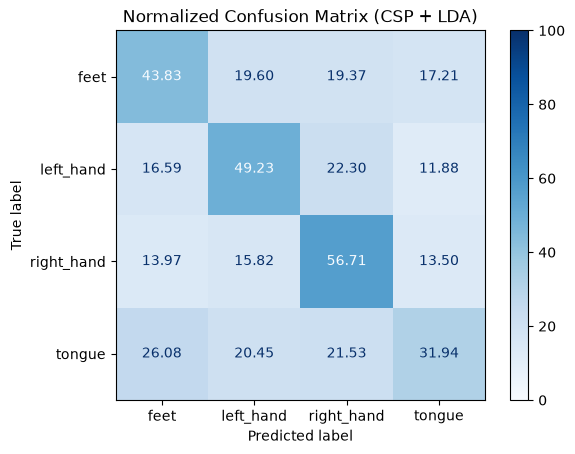

In [2]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = np.array([
    [0.4383, 0.1960, 0.1937, 0.1721],
    [0.1659, 0.4923, 0.2230, 0.1188],
    [0.1397, 0.1582, 0.5671, 0.1350],
    [0.2608, 0.2045, 0.2153, 0.3194]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm*100,
    display_labels=["feet", "left_hand", "right_hand", "tongue"]
)

disp.plot(
    cmap="Blues",
    im_kw={"vmin": 0, "vmax": 100},
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix (CSP + LDA)")
plt.show()

# eegnet

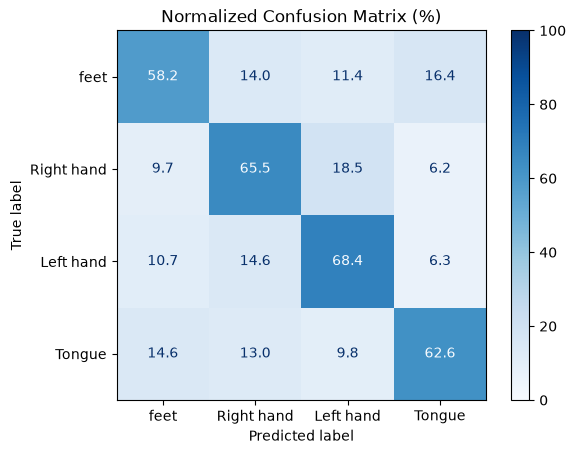

In [12]:
cm = np.array([
    [58.18, 14.04, 11.42, 16.36],
    [ 9.72, 65.51, 18.52,  6.25],
    [10.73, 14.58, 68.36,  6.33],
    [14.58, 12.96,  9.80, 62.65]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["feet", "Right hand", "Left hand", "Tongue"]
)

disp.plot(
    cmap="Blues",
    im_kw={"vmin": 0, "vmax": 100},
    values_format=".1f"
)

plt.title("Normalized Confusion Matrix (%)")
plt.show()

## scaling

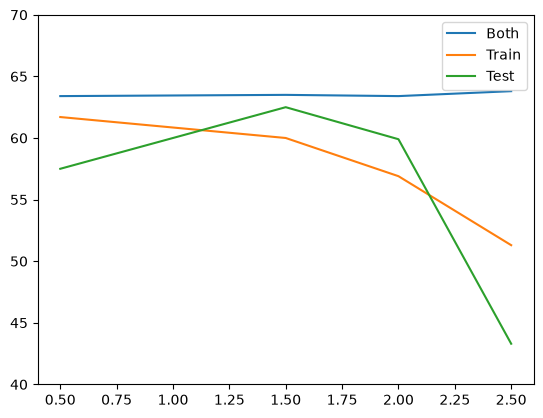

In [12]:
plt.plot([0.5, 1.5, 2, 2.5],[63.4, 63.5, 63.4, 63.8])
plt.plot([0.5, 1.5, 2, 2.5], [61.7, 60, 56.9, 51.3])
plt.plot([0.5, 1.5, 2, 2.5], [57.5, 62.5, 59.9, 43.3])
plt.ylim(40,70)
plt.legend(['Both', 'Train', 'Test'])

## noise

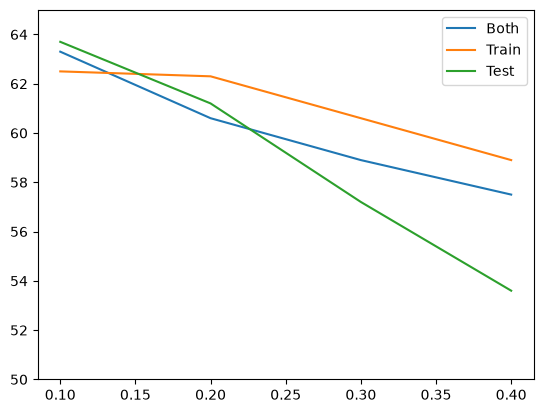

In [13]:
plt.plot([0.1, 0.2, 0.3, 0.4],[63.3, 60.6, 58.9, 57.5])
plt.plot([0.1, 0.2, 0.3, 0.4], [62.5, 62.3, 60.6, 58.9])
plt.plot([0.1, 0.2, 0.3, 0.4], [63.7, 61.2, 57.2, 53.6])
plt.ylim(50,65)
plt.legend(['Both', 'Train', 'Test'])

## durations

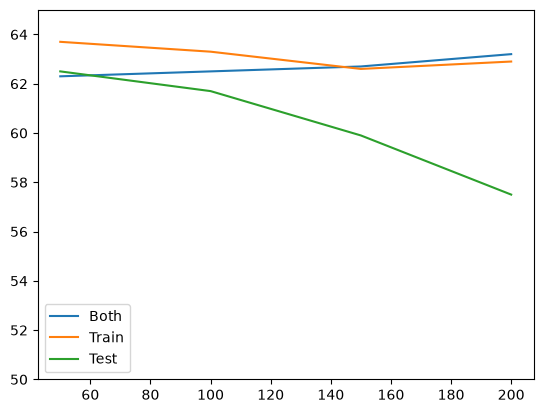

In [19]:
plt.plot([50, 100, 150, 200], [62.3, 62.5, 62.7, 63.2])
plt.plot([50, 100, 150, 200], [63.7, 63.3, 62.6, 62.9 ])
plt.plot([50, 100, 150, 200], [62.5, 61.7, 59.9, 57.5])
plt.ylim(50,65)
plt.legend(['Both', 'Train', 'Test'])

## frequencies

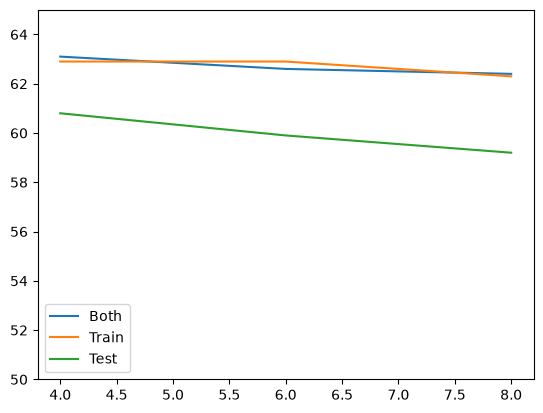

In [17]:
plt.plot([4,6,8],[63.1, 62.6, 62.4])
plt.plot([4,6,8], [62.9, 62.9, 62.3])
plt.plot([4,6,8], [60.8, 59.9, 59.2])
plt.ylim(50,65)
plt.legend(['Both', 'Train', 'Test'])

# EEGNet fixed

## scaling

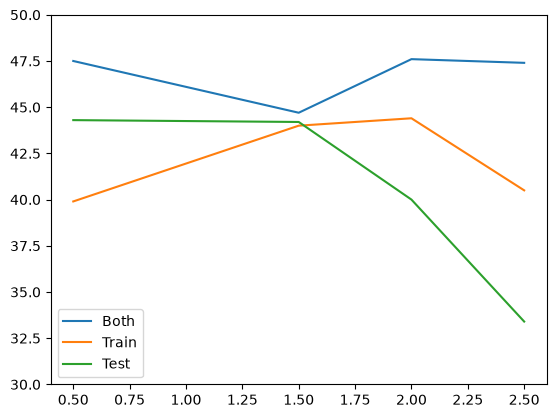

In [6]:
plt.plot([0.5, 1.5, 2, 2.5],[47.5, 44.7, 47.6, 47.4])
plt.plot([0.5, 1.5, 2, 2.5], [39.9, 44, 44.4, 40.5])
plt.plot([0.5, 1.5, 2, 2.5], [44.3, 44.2, 40, 33.4])
plt.ylim(30,50)
plt.legend(['Both', 'Train', 'Test'])

## noise

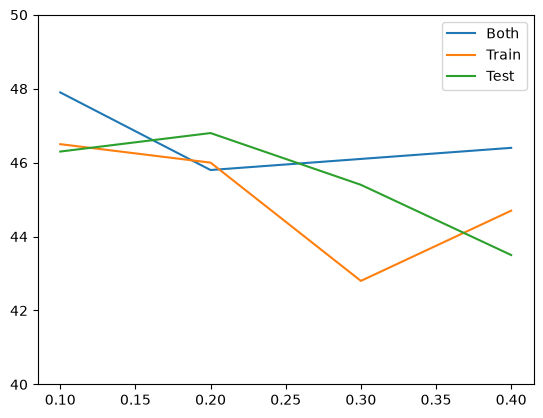

In [9]:
plt.plot([0.1, 0.2, 0.3, 0.4],[47.9, 45.8, 46.1, 46.4])
plt.plot([0.1, 0.2, 0.3, 0.4], [46.5, 46, 42.8, 44.7])
plt.plot([0.1, 0.2, 0.3, 0.4], [46.3, 46.8, 45.4, 43.5])
plt.ylim(40,50)
plt.legend(['Both', 'Train', 'Test'])


## durations

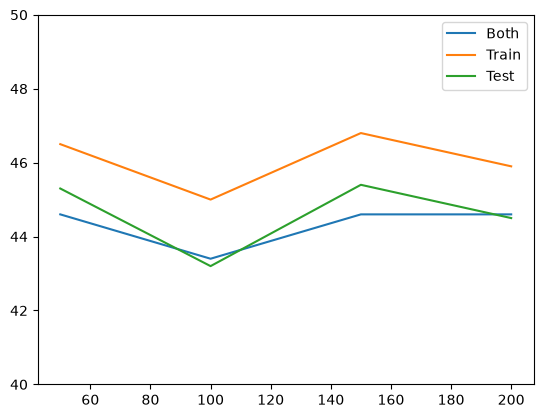

In [11]:
plt.plot([50, 100, 150, 200], [44.6, 43.4, 44.6, 44.6])
plt.plot([50, 100, 150, 200], [46.5, 45, 46.8, 45.9])
plt.plot([50, 100, 150, 200], [45.3, 43.2, 45.4, 44.5])
plt.ylim(40,50)
plt.legend(['Both', 'Train', 'Test'])

## freq

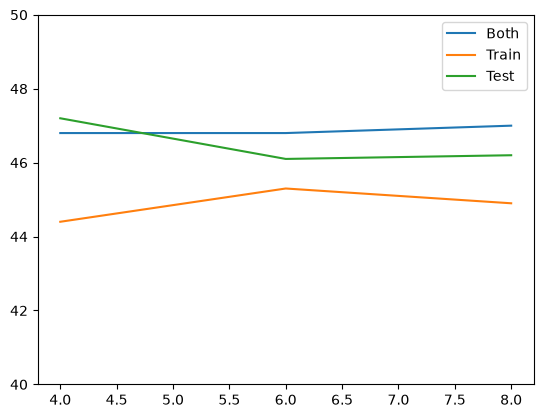

In [13]:
plt.plot([4,6,8],[46.8, 46.8, 47])
plt.plot([4,6,8], [44.4, 45.3, 44.9])
plt.plot([4,6,8], [47.2, 46.1, 46.2])
plt.ylim(40,50)
plt.legend(['Both', 'Train', 'Test'])

# per suject

## scaling

In [78]:
"""Standalone plotting script for three EEG preprocessing conditions.

All values are embedded directly in RESULTS. No result text files, parsers,
previous scripts, or __file__ are required.

Outputs:
- One 3x4 confusion-matrix figure per subject.
- Per-subject accuracy comparison figures.
- Reported average confusion matrices for all conditions and scales.
- Overall average confusion matrices across the four scales.
- Mean accuracy, AUC, and F1 comparison figures.
- CSV files containing summary and subject-level metrics.

Four early-stopping epochs were not present in the supplied log and therefore
remain None: train-only scale 2.5 subjects 4 and 9, and test-only scale 0.5
subjects 1 and 8.
"""

from __future__ import annotations

import csv
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np


OUTPUT_DIR = Path.cwd() / "three_preprocessing_condition_plots"
CLASS_NAMES = ["feet", "Right hand", "Left hand", "Tongue"]
SCALES = [0.5, 1.5, 2.0, 2.5]
SUBJECTS = list(range(1, 10))
DPI = 160
CONDITION_LABELS = {
    "both_train_test": "Both train and test preprocessed",
    "train_only": "Train only preprocessed",
    "test_only": "Test only preprocessed",
}
CONDITION_ORDER = ["both_train_test", "train_only", "test_only"]


RESULTS = {'both_train_test': {0.5: {'average_matrix': [[0.30401235, 0.36805556, 0.13734568, 0.19058642],
                                              [0.06944444, 0.70138889, 0.13117284, 0.09799383],
                                              [0.08256173, 0.3433642, 0.47685185, 0.09722222],
                                              [0.14969136, 0.34182099, 0.08950617, 0.41898148]],
                           'folds': {1: {'acc': 0.625,
                                         'auc': 0.8672638567386831,
                                         'epoch': 41,
                                         'fmeasure': 0.5987615053918127,
                                         'matrix': [[0.60416667, 0.20833333, 0.0625, 0.125],
                                                    [0.04166667, 0.79861111, 0.15972222, 0.0],
                                                    [0.03472222, 0.09027778, 0.875, 0.0],
                                                    [0.58333333, 0.19444444, 0.0, 0.22222222]]},
                                     2: {'acc': 0.23958333333333334,
                                         'auc': 0.4935096772119341,
                                         'epoch': 15,
                                         'fmeasure': 0.12933622601991926,
                                         'matrix': [[0.01388889, 0.88194444, 0.01388889, 0.09027778],
                                                    [0.00694444, 0.875, 0.01388889, 0.10416667],
                                                    [0.00694444, 0.9375, 0.01388889, 0.04166667],
                                                    [0.00694444, 0.9375, 0.0, 0.05555556]]},
                                     3: {'acc': 0.7447916666666666,
                                         'auc': 0.9357799639917695,
                                         'epoch': 39,
                                         'fmeasure': 0.7464706347968799,
                                         'matrix': [[0.61111111, 0.06944444, 0.06944444, 0.25],
                                                    [0.04861111, 0.78472222, 0.0, 0.16666667],
                                                    [0.05555556, 0.06944444, 0.68055556, 0.19444444],
                                                    [0.09027778, 0.00694444, 0.0, 0.90277778]]},
                                     4: {'acc': 0.4600694444444444,
                                         'auc': 0.7112027391975309,
                                         'epoch': 19,
                                         'fmeasure': 0.4219583799830279,
                                         'matrix': [[0.11805556, 0.47222222, 0.14583333, 0.26388889],
                                                    [0.02083333, 0.72916667, 0.1875, 0.0625],
                                                    [0.05555556, 0.23611111, 0.67361111, 0.03472222],
                                                    [0.09722222, 0.35416667, 0.22916667, 0.31944444]]},
                                     5: {'acc': 0.2465277777777778,
                                         'auc': 0.513573414994856,
                                         'epoch': 15,
                                         'fmeasure': 0.10518221939123709,
                                         'matrix': [[0.0, 0.97916667, 0.02083333, 0.0],
                                                    [0.0, 0.97222222, 0.02777778, 0.0],
                                                    [0.0, 0.98611111, 0.01388889, 0.0],
                                                    [0.0, 0.98611111, 0.01388889, 0.0]]},
                                     6: {'acc': 0.3090277777777778,
                                         'auc': 0.6030012217078189,
                                         'epoch': 16,
                                         'fmeasure': 0.26338687911774067,
                                         'matrix': [[0.13194444, 0.125, 0.01388889, 0.72916667],
                                                    [0.23611111, 0.38888889, 0.04861111, 0.32638889],
                                                    [0.22916667, 0.33333333, 0.04861111, 0.38888889],
                                                    [0.15972222, 0.15277778, 0.02083333, 0.66666667]]},
                                     7: {'acc': 0.3524305555555556,
                                         'auc': 0.6499927662037037,
                                         'epoch': 40,
                                         'fmeasure': 0.34826622629326387,
                                         'matrix': [[0.15277778, 0.43055556, 0.36111111, 0.05555556],
                                                    [0.0625, 0.40277778, 0.39583333, 0.13888889],
                                                    [0.0625, 0.38888889, 0.45833333, 0.09027778],
                                                    [0.05555556, 0.34722222, 0.20138889, 0.39583333]]},
                                     8: {'acc': 0.6666666666666666,
                                         'auc': 0.9077490033436213,
                                         'epoch': 51,
                                         'fmeasure': 0.6654648129136144,
                                         'matrix': [[0.47222222, 0.0625, 0.41666667, 0.04861111],
                                                    [0.1875, 0.66666667, 0.06944444, 0.07638889],
                                                    [0.03472222, 0.0, 0.91666667, 0.04861111],
                                                    [0.10416667, 0.00694444, 0.27777778, 0.61111111]]},
                                     9: {'acc': 0.6336805555555556,
                                         'auc': 0.8685378086419754,
                                         'epoch': 36,
                                         'fmeasure': 0.6365382081686429,
                                         'matrix': [[0.63194444, 0.08333333, 0.13194444, 0.15277778],
                                                    [0.02083333, 0.69444444, 0.27777778, 0.00694444],
                                                    [0.26388889, 0.04861111, 0.61111111, 0.07638889],
                                                    [0.25, 0.09027778, 0.0625, 0.59722222]]}},
                           'summary': {'acc_mean': 0.4753,
                                       'acc_std': 0.1849,
                                       'auc_mean': 0.7278,
                                       'auc_std': 0.1625,
                                       'fmeasure_mean': 0.435,
                                       'fmeasure_std': 0.2253}},
                     1.5: {'average_matrix': [[0.30092593, 0.32098765, 0.17515432, 0.2029321],
                                              [0.13348765, 0.61651235, 0.15046296, 0.09953704],
                                              [0.11882716, 0.31018519, 0.46450617, 0.10648148],
                                              [0.19984568, 0.28780864, 0.10648148, 0.4058642]],
                           'folds': {1: {'acc': 0.625,
                                         'auc': 0.8678948045267489,
                                         'epoch': 32,
                                         'fmeasure': 0.5843965757849108,
                                         'matrix': [[0.70138889, 0.13194444, 0.07638889, 0.09027778],
                                                    [0.02083333, 0.86111111, 0.11111111, 0.00694444],
                                                    [0.03472222, 0.15972222, 0.80555556, 0.0],
                                                    [0.72222222, 0.13888889, 0.00694444, 0.13194444]]},
                                     2: {'acc': 0.24131944444444445,
                                         'auc': 0.5180965470679012,
                                         'epoch': 15,
                                         'fmeasure': 0.15017645464053972,
                                         'matrix': [[0.02777778, 0.83333333, 0.125, 0.01388889],
                                                    [0.02083333, 0.81944444, 0.09027778, 0.06944444],
                                                    [0.02777778, 0.86111111, 0.09722222, 0.01388889],
                                                    [0.01388889, 0.90277778, 0.0625, 0.02083333]]},
                                     3: {'acc': 0.6631944444444444,
                                         'auc': 0.9322916666666666,
                                         'epoch': 58,
                                         'fmeasure': 0.655736197242665,
                                         'matrix': [[0.375, 0.07638889, 0.14583333, 0.40277778],
                                                    [0.02777778, 0.59027778, 0.02777778, 0.35416667],
                                                    [0.01388889, 0.04861111, 0.70833333, 0.22916667],
                                                    [0.01388889, 0.00694444, 0.0, 0.97916667]]},
                                     4: {'acc': 0.3836805555555556,
                                         'auc': 0.7060988940329218,
                                         'epoch': 25,
                                         'fmeasure': 0.37036950113342193,
                                         'matrix': [[0.60416667, 0.13194444, 0.09027778, 0.17361111],
                                                    [0.53472222, 0.23611111, 0.22222222, 0.00694444],
                                                    [0.42361111, 0.04861111, 0.51388889, 0.01388889],
                                                    [0.59722222, 0.05555556, 0.16666667, 0.18055556]]},
                                     5: {'acc': 0.25,
                                         'auc': 0.5224810313786008,
                                         'epoch': 15,
                                         'fmeasure': 0.1,
                                         'matrix': [[0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0]]},
                                     6: {'acc': 0.2795138888888889,
                                         'auc': 0.598118409207819,
                                         'epoch': 16,
                                         'fmeasure': 0.23185731046653207,
                                         'matrix': [[0.20138889, 0.08333333, 0.00694444, 0.70833333],
                                                    [0.36805556, 0.25, 0.04166667, 0.34027778],
                                                    [0.32638889, 0.25, 0.01388889, 0.40972222],
                                                    [0.18055556, 0.15277778, 0.01388889, 0.65277778]]},
                                     7: {'acc': 0.3611111111111111,
                                         'auc': 0.6882273984053499,
                                         'epoch': 27,
                                         'fmeasure': 0.32543109911530965,
                                         'matrix': [[0.02083333, 0.39583333, 0.54861111, 0.03472222],
                                                    [0.0, 0.47916667, 0.48611111, 0.03472222],
                                                    [0.00694444, 0.36805556, 0.59722222, 0.02777778],
                                                    [0.02777778, 0.25694444, 0.36805556, 0.34722222]]},
                                     8: {'acc': 0.65625,
                                         'auc': 0.8928031764403292,
                                         'epoch': 31,
                                         'fmeasure': 0.6502816404536582,
                                         'matrix': [[0.45138889, 0.09722222, 0.40277778, 0.04861111],
                                                    [0.15277778, 0.72222222, 0.05555556, 0.06944444],
                                                    [0.02777778, 0.0, 0.92361111, 0.04861111],
                                                    [0.13194444, 0.03472222, 0.30555556, 0.52777778]]},
                                     9: {'acc': 0.5625,
                                         'auc': 0.8065481931584362,
                                         'epoch': 23,
                                         'fmeasure': 0.5526094292715275,
                                         'matrix': [[0.32638889, 0.13888889, 0.18055556, 0.35416667],
                                                    [0.07638889, 0.59027778, 0.31944444, 0.01388889],
                                                    [0.20833333, 0.05555556, 0.52083333, 0.21527778],
                                                    [0.11111111, 0.04166667, 0.03472222, 0.8125]]}},
                           'summary': {'acc_mean': 0.447,
                                       'acc_std': 0.1687,
                                       'auc_mean': 0.7258,
                                       'auc_std': 0.149,
                                       'fmeasure_mean': 0.4023,
                                       'fmeasure_std': 0.2034}},
                     2.0: {'average_matrix': [[0.30787037, 0.18441358, 0.29938272, 0.20833333],
                                              [0.1087963, 0.53549383, 0.27160494, 0.08410494],
                                              [0.11574074, 0.15200617, 0.63271605, 0.09953704],
                                              [0.17283951, 0.15972222, 0.23919753, 0.42824074]],
                           'folds': {1: {'acc': 0.640625,
                                         'auc': 0.8755505722736624,
                                         'epoch': 56,
                                         'fmeasure': 0.6051544456310707,
                                         'matrix': [[0.66666667, 0.15972222, 0.08333333, 0.09027778],
                                                    [0.02083333, 0.83333333, 0.14583333, 0.0],
                                                    [0.03472222, 0.08333333, 0.88194444, 0.0],
                                                    [0.61805556, 0.19444444, 0.00694444, 0.18055556]]},
                                     2: {'acc': 0.3142361111111111,
                                         'auc': 0.5997661072530865,
                                         'epoch': 26,
                                         'fmeasure': 0.2771904893894912,
                                         'matrix': [[0.28472222, 0.39583333, 0.25694444, 0.0625],
                                                    [0.20833333, 0.51388889, 0.27083333, 0.00694444],
                                                    [0.22916667, 0.32638889, 0.43055556, 0.01388889],
                                                    [0.20138889, 0.52083333, 0.25, 0.02777778]]},
                                     3: {'acc': 0.7170138888888888,
                                         'auc': 0.9276901684670782,
                                         'epoch': 38,
                                         'fmeasure': 0.7050723445671321,
                                         'matrix': [[0.40277778, 0.11805556, 0.15277778, 0.32638889],
                                                    [0.02777778, 0.79861111, 0.01388889, 0.15972222],
                                                    [0.04166667, 0.07638889, 0.70833333, 0.17361111],
                                                    [0.02083333, 0.02083333, 0.0, 0.95833333]]},
                                     4: {'acc': 0.4236111111111111,
                                         'auc': 0.6942435056584362,
                                         'epoch': 22,
                                         'fmeasure': 0.3837291153023895,
                                         'matrix': [[0.10416667, 0.26388889, 0.29166667, 0.34027778],
                                                    [0.11111111, 0.43055556, 0.41666667, 0.04166667],
                                                    [0.03472222, 0.09722222, 0.82638889, 0.04166667],
                                                    [0.07638889, 0.16666667, 0.42361111, 0.33333333]]},
                                     5: {'acc': 0.25,
                                         'auc': 0.528686021090535,
                                         'epoch': 15,
                                         'fmeasure': 0.12234963047819651,
                                         'matrix': [[0.00694444, 0.04861111, 0.94444444, 0.0],
                                                    [0.00694444, 0.04861111, 0.94444444, 0.0],
                                                    [0.0, 0.05555556, 0.94444444, 0.0],
                                                    [0.0, 0.04861111, 0.95138889, 0.0]]},
                                     6: {'acc': 0.2934027777777778,
                                         'auc': 0.624658404063786,
                                         'epoch': 17,
                                         'fmeasure': 0.2744252873563218,
                                         'matrix': [[0.31944444, 0.09027778, 0.04166667, 0.54861111],
                                                    [0.41666667, 0.22916667, 0.0625, 0.29166667],
                                                    [0.36111111, 0.1875, 0.10416667, 0.34722222],
                                                    [0.31944444, 0.11805556, 0.04166667, 0.52083333]]},
                                     7: {'acc': 0.4010416666666667,
                                         'auc': 0.6722326710390947,
                                         'epoch': 31,
                                         'fmeasure': 0.4025970360929215,
                                         'matrix': [[0.28472222, 0.36805556, 0.31944444, 0.02777778],
                                                    [0.06944444, 0.55555556, 0.27083333, 0.10416667],
                                                    [0.07638889, 0.47222222, 0.34722222, 0.10416667],
                                                    [0.17361111, 0.28472222, 0.125, 0.41666667]]},
                                     8: {'acc': 0.6545138888888888,
                                         'auc': 0.9043692129629628,
                                         'epoch': 40,
                                         'fmeasure': 0.6392458568186251,
                                         'matrix': [[0.30555556, 0.11805556, 0.47222222, 0.10416667],
                                                    [0.08333333, 0.74305556, 0.04861111, 0.125],
                                                    [0.01388889, 0.0, 0.93055556, 0.05555556],
                                                    [0.02777778, 0.00694444, 0.32638889, 0.63888889]]},
                                     9: {'acc': 0.5902777777777778,
                                         'auc': 0.8484358924897121,
                                         'epoch': 28,
                                         'fmeasure': 0.584208128704364,
                                         'matrix': [[0.39583333, 0.09722222, 0.13194444, 0.375],
                                                    [0.03472222, 0.66666667, 0.27083333, 0.02777778],
                                                    [0.25, 0.06944444, 0.52083333, 0.15972222],
                                                    [0.11805556, 0.07638889, 0.02777778, 0.77777778]]}},
                           'summary': {'acc_mean': 0.4761,
                                       'acc_std': 0.1664,
                                       'auc_mean': 0.7417,
                                       'auc_std': 0.1401,
                                       'fmeasure_mean': 0.4438,
                                       'fmeasure_std': 0.1878}},
                     2.5: {'average_matrix': [[0.31790123, 0.31404321, 0.17824074, 0.18981481],
                                              [0.10493827, 0.63348765, 0.18441358, 0.07716049],
                                              [0.11728395, 0.26697531, 0.53240741, 0.08333333],
                                              [0.16743827, 0.2808642, 0.13966049, 0.41203704]],
                           'folds': {1: {'acc': 0.6388888888888888,
                                         'auc': 0.8725726594650206,
                                         'epoch': 43,
                                         'fmeasure': 0.6260413828431713,
                                         'matrix': [[0.61805556, 0.14583333, 0.05555556, 0.18055556],
                                                    [0.04166667, 0.75, 0.1875, 0.02083333],
                                                    [0.04861111, 0.10416667, 0.84722222, 0.0],
                                                    [0.47222222, 0.18055556, 0.00694444, 0.34027778]]},
                                     2: {'acc': 0.3211805555555556,
                                         'auc': 0.6106449331275721,
                                         'epoch': 27,
                                         'fmeasure': 0.2736452359149937,
                                         'matrix': [[0.22222222, 0.4375, 0.27777778, 0.0625],
                                                    [0.13888889, 0.55555556, 0.30555556, 0.0],
                                                    [0.11111111, 0.38888889, 0.49305556, 0.00694444],
                                                    [0.17361111, 0.51388889, 0.29861111, 0.01388889]]},
                                     3: {'acc': 0.6944444444444444,
                                         'auc': 0.9289158950617283,
                                         'epoch': 46,
                                         'fmeasure': 0.6973281528418955,
                                         'matrix': [[0.49305556, 0.04166667, 0.13194444, 0.33333333],
                                                    [0.03472222, 0.68055556, 0.00694444, 0.27777778],
                                                    [0.02777778, 0.03472222, 0.70138889, 0.23611111],
                                                    [0.08333333, 0.00694444, 0.00694444, 0.90277778]]},
                                     4: {'acc': 0.4010416666666667,
                                         'auc': 0.7246334876543211,
                                         'epoch': 20,
                                         'fmeasure': 0.34156974405286844,
                                         'matrix': [[0.04861111, 0.29166667, 0.36805556, 0.29166667],
                                                    [0.02777778, 0.38194444, 0.54166667, 0.04861111],
                                                    [0.00694444, 0.07638889, 0.88888889, 0.02777778],
                                                    [0.0, 0.125, 0.59027778, 0.28472222]]},
                                     5: {'acc': 0.2465277777777778,
                                         'auc': 0.5241066261574074,
                                         'epoch': 15,
                                         'fmeasure': 0.10568181818181818,
                                         'matrix': [[0.0, 0.95833333, 0.04166667, 0.0],
                                                    [0.0, 0.97222222, 0.02777778, 0.0],
                                                    [0.0, 0.98611111, 0.01388889, 0.0],
                                                    [0.0, 0.97222222, 0.02777778, 0.0]]},
                                     6: {'acc': 0.3229166666666667,
                                         'auc': 0.633178208590535,
                                         'epoch': 17,
                                         'fmeasure': 0.3064798360907847,
                                         'matrix': [[0.49305556, 0.10416667, 0.02777778, 0.375],
                                                    [0.53472222, 0.25, 0.05555556, 0.15972222],
                                                    [0.54166667, 0.20138889, 0.11111111, 0.14583333],
                                                    [0.44444444, 0.09027778, 0.02777778, 0.4375]]},
                                     7: {'acc': 0.3628472222222222,
                                         'auc': 0.6612373006687243,
                                         'epoch': 37,
                                         'fmeasure': 0.3448878963343668,
                                         'matrix': [[0.19444444, 0.52083333, 0.28472222, 0.0],
                                                    [0.03472222, 0.66666667, 0.27777778, 0.02083333],
                                                    [0.0625, 0.54166667, 0.39583333, 0.0],
                                                    [0.13194444, 0.54166667, 0.13194444, 0.19444444]]},
                                     8: {'acc': 0.6961805555555556,
                                         'auc': 0.9081669560185185,
                                         'epoch': 39,
                                         'fmeasure': 0.6913271928542819,
                                         'matrix': [[0.47222222, 0.11805556, 0.25694444, 0.15277778],
                                                    [0.09027778, 0.72916667, 0.03472222, 0.14583333],
                                                    [0.07638889, 0.00694444, 0.79166667, 0.125],
                                                    [0.08333333, 0.01388889, 0.11111111, 0.79166667]]},
                                     9: {'acc': 0.5815972222222222,
                                         'auc': 0.7986191486625515,
                                         'epoch': 22,
                                         'fmeasure': 0.5697789714445458,
                                         'matrix': [[0.31944444, 0.20833333, 0.15972222, 0.3125],
                                                    [0.04166667, 0.71527778, 0.22222222, 0.02083333],
                                                    [0.18055556, 0.0625, 0.54861111, 0.20833333],
                                                    [0.11805556, 0.08333333, 0.05555556, 0.74305556]]}},
                           'summary': {'acc_mean': 0.474,
                                       'acc_std': 0.1674,
                                       'auc_mean': 0.7402,
                                       'auc_std': 0.1359,
                                       'fmeasure_mean': 0.4396,
                                       'fmeasure_std': 0.1991}}},
 'test_only': {0.5: {'average_matrix': [[0.14891975, 0.35802469, 0.3125, 0.18055556],
                                        [0.04243827, 0.62885802, 0.27932099, 0.04938272],
                                        [0.05632716, 0.2662037, 0.64737654, 0.03009259],
                                        [0.08024691, 0.33873457, 0.2337963, 0.34722222]],
                     'folds': {1: {'acc': 0.53125,
                                   'auc': 0.8443086098251028,
                                   'epoch': None,
                                   'fmeasure': 0.47209513006289006,
                                   'matrix': [[0.08333333, 0.39583333, 0.23611111, 0.28472222],
                                              [0.0, 0.63194444, 0.35416667, 0.01388889],
                                              [0.0, 0.00694444, 0.99305556, 0.0],
                                              [0.06944444, 0.4375, 0.07638889, 0.41666667]]},
                               2: {'acc': 0.2482638888888889,
                                   'auc': 0.5047140239197531,
                                   'epoch': 15,
                                   'fmeasure': 0.1058874380090086,
                                   'matrix': [[0.0, 0.98611111, 0.01388889, 0.0],
                                              [0.0, 0.97916667, 0.02083333, 0.0],
                                              [0.0, 0.98611111, 0.01388889, 0.0],
                                              [0.0, 0.97222222, 0.02777778, 0.0]]},
                               3: {'acc': 0.6892361111111112,
                                   'auc': 0.9195240162037036,
                                   'epoch': 39,
                                   'fmeasure': 0.5967553964627018,
                                   'matrix': [[0.01388889, 0.21527778, 0.36111111, 0.40972222],
                                              [0.0, 0.90277778, 0.01388889, 0.08333333],
                                              [0.0, 0.04861111, 0.90277778, 0.04861111],
                                              [0.0, 0.03472222, 0.02777778, 0.9375]]},
                               4: {'acc': 0.3576388888888889,
                                   'auc': 0.698881172839506,
                                   'epoch': 42,
                                   'fmeasure': 0.291335422484656,
                                   'matrix': [[0.15277778, 0.11805556, 0.52777778, 0.20138889],
                                              [0.06944444, 0.11805556, 0.76388889, 0.04861111],
                                              [0.00694444, 0.01388889, 0.97222222, 0.00694444],
                                              [0.13194444, 0.02777778, 0.65277778, 0.1875]]},
                               5: {'acc': 0.25,
                                   'auc': 0.520529915766461,
                                   'epoch': 15,
                                   'fmeasure': 0.1,
                                   'matrix': [[0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0]]},
                               6: {'acc': 0.4079861111111111,
                                   'auc': 0.6924270190329218,
                                   'epoch': 41,
                                   'fmeasure': 0.4092454219940599,
                                   'matrix': [[0.32638889, 0.09027778, 0.15972222, 0.42361111],
                                              [0.22222222, 0.36805556, 0.24305556, 0.16666667],
                                              [0.26388889, 0.09027778, 0.54166667, 0.10416667],
                                              [0.28472222, 0.10416667, 0.21527778, 0.39583333]]},
                               7: {'acc': 0.2690972222222222,
                                   'auc': 0.6031901041666666,
                                   'epoch': 30,
                                   'fmeasure': 0.17066712874718418,
                                   'matrix': [[0.0, 0.18055556, 0.81944444, 0.0],
                                              [0.0, 0.16666667, 0.83333333, 0.0],
                                              [0.0, 0.13194444, 0.86805556, 0.0],
                                              [0.0, 0.33333333, 0.625, 0.04166667]]},
                               8: {'acc': 0.609375,
                                   'auc': 0.8812532150205761,
                                   'epoch': None,
                                   'fmeasure': 0.5890355338170234,
                                   'matrix': [[0.22916667, 0.11805556, 0.5625, 0.09027778],
                                              [0.07638889, 0.70138889, 0.10416667, 0.11805556],
                                              [0.01388889, 0.01388889, 0.9375, 0.03472222],
                                              [0.02083333, 0.00694444, 0.40277778, 0.56944444]]},
                               9: {'acc': 0.625,
                                   'auc': 0.8630682548868313,
                                   'epoch': 56,
                                   'fmeasure': 0.6225675857478243,
                                   'matrix': [[0.53472222, 0.11805556, 0.13194444, 0.21527778],
                                              [0.01388889, 0.79166667, 0.18055556, 0.01388889],
                                              [0.22222222, 0.10416667, 0.59722222, 0.07638889],
                                              [0.21527778, 0.13194444, 0.07638889, 0.57638889]]}},
                     'summary': {'acc_mean': 0.4431,
                                 'acc_std': 0.1644,
                                 'auc_mean': 0.7253,
                                 'auc_std': 0.15,
                                 'fmeasure_mean': 0.3731,
                                 'fmeasure_std': 0.201}},
               1.5: {'average_matrix': [[0.2662037, 0.25154321, 0.12037037, 0.36188272],
                                        [0.08641975, 0.53549383, 0.12654321, 0.25154321],
                                        [0.06712963, 0.26697531, 0.40509259, 0.26080247],
                                        [0.10648148, 0.2191358, 0.11419753, 0.56018519]],
                     'folds': {1: {'acc': 0.640625,
                                   'auc': 0.8781587577160493,
                                   'epoch': None,
                                   'fmeasure': 0.6308127946340043,
                                   'matrix': [[0.57638889, 0.15277778, 0.04166667, 0.22916667],
                                              [0.01388889, 0.86111111, 0.10416667, 0.02083333],
                                              [0.03472222, 0.20833333, 0.75, 0.00694444],
                                              [0.42361111, 0.19444444, 0.00694444, 0.375]]},
                               2: {'acc': 0.3003472222222222,
                                   'auc': 0.5525012860082305,
                                   'epoch': 16,
                                   'fmeasure': 0.29153184570887675,
                                   'matrix': [[0.25, 0.22222222, 0.34722222, 0.18055556],
                                              [0.13888889, 0.34027778, 0.45138889, 0.06944444],
                                              [0.15972222, 0.28472222, 0.45138889, 0.10416667],
                                              [0.125, 0.27083333, 0.44444444, 0.15972222]]},
                               3: {'acc': 0.7100694444444444,
                                   'auc': 0.9298080632716049,
                                   'epoch': 42,
                                   'fmeasure': 0.7127523005873887,
                                   'matrix': [[0.63194444, 0.06944444, 0.05555556, 0.24305556],
                                              [0.07638889, 0.65972222, 0.01388889, 0.25],
                                              [0.07638889, 0.05555556, 0.63194444, 0.23611111],
                                              [0.06944444, 0.01388889, 0.0, 0.91666667]]},
                               4: {'acc': 0.46875,
                                   'auc': 0.6984029385288065,
                                   'epoch': 20,
                                   'fmeasure': 0.4442577241899639,
                                   'matrix': [[0.15277778, 0.23611111, 0.13888889, 0.47222222],
                                              [0.125, 0.45138889, 0.22222222, 0.20138889],
                                              [0.04861111, 0.125, 0.69444444, 0.13194444],
                                              [0.07638889, 0.10416667, 0.24305556, 0.57638889]]},
                               5: {'acc': 0.234375,
                                   'auc': 0.5181809413580247,
                                   'epoch': 15,
                                   'fmeasure': 0.12442694421417826,
                                   'matrix': [[0.02083333, 0.88888889, 0.07638889, 0.01388889],
                                              [0.00694444, 0.86111111, 0.13194444, 0.0],
                                              [0.00694444, 0.9375, 0.05555556, 0.0],
                                              [0.00694444, 0.88194444, 0.11111111, 0.0]]},
                               6: {'acc': 0.2760416666666667,
                                   'auc': 0.5561222029320988,
                                   'epoch': 15,
                                   'fmeasure': 0.21649531842116448,
                                   'matrix': [[0.06944444, 0.15277778, 0.02777778, 0.75],
                                              [0.06944444, 0.30555556, 0.02777778, 0.59722222],
                                              [0.07638889, 0.25694444, 0.03472222, 0.63194444],
                                              [0.06944444, 0.20833333, 0.02777778, 0.69444444]]},
                               7: {'acc': 0.390625,
                                   'auc': 0.6590591242283951,
                                   'epoch': 22,
                                   'fmeasure': 0.35723910480932064,
                                   'matrix': [[0.09722222, 0.45138889, 0.28472222, 0.16666667],
                                              [0.02777778, 0.61805556, 0.13888889, 0.21527778],
                                              [0.03472222, 0.51388889, 0.25694444, 0.19444444],
                                              [0.04166667, 0.27777778, 0.09027778, 0.59027778]]},
                               8: {'acc': 0.6805555555555556,
                                   'auc': 0.895925765174897,
                                   'epoch': 26,
                                   'fmeasure': 0.6812780651497234,
                                   'matrix': [[0.51388889, 0.09027778, 0.11111111, 0.28472222],
                                              [0.14583333, 0.70138889, 0.02777778, 0.125],
                                              [0.08333333, 0.02083333, 0.77083333, 0.125],
                                              [0.13888889, 0.02083333, 0.10416667, 0.73611111]]},
                               9: {'acc': 0.2743055555555556,
                                   'auc': 0.6739004629629629,
                                   'epoch': 15,
                                   'fmeasure': 0.14881263957576574,
                                   'matrix': [[0.08333333, 0.0, 0.0, 0.91666667],
                                              [0.17361111, 0.02083333, 0.02083333, 0.78472222],
                                              [0.08333333, 0.0, 0.0, 0.91666667],
                                              [0.00694444, 0.0, 0.0, 0.99305556]]}},
                     'summary': {'acc_mean': 0.4417,
                                 'acc_std': 0.1796,
                                 'auc_mean': 0.7069,
                                 'auc_std': 0.1492,
                                 'fmeasure_mean': 0.4008,
                                 'fmeasure_std': 0.2156}},
               2.0: {'average_matrix': [[0.34953704, 0.07253086, 0.05632716, 0.52160494],
                                        [0.20138889, 0.30864198, 0.07484568, 0.41512346],
                                        [0.22993827, 0.11651235, 0.23842593, 0.41512346],
                                        [0.22299383, 0.0779321, 0.03626543, 0.66280864]],
                     'folds': {1: {'acc': 0.4895833333333333,
                                   'auc': 0.8376334233539096,
                                   'epoch': 23,
                                   'fmeasure': 0.46041884156859847,
                                   'matrix': [[0.56944444, 0.10416667, 0.00694444, 0.31944444],
                                              [0.18055556, 0.77777778, 0.0, 0.04166667],
                                              [0.49305556, 0.31944444, 0.13888889, 0.04861111],
                                              [0.38888889, 0.13888889, 0.0, 0.47222222]]},
                               2: {'acc': 0.2795138888888889,
                                   'auc': 0.5723259066358025,
                                   'epoch': 17,
                                   'fmeasure': 0.24302465516958677,
                                   'matrix': [[0.08333333, 0.20833333, 0.04166667, 0.66666667],
                                              [0.0625, 0.48611111, 0.05555556, 0.39583333],
                                              [0.09027778, 0.30555556, 0.08333333, 0.52083333],
                                              [0.07638889, 0.39583333, 0.0625, 0.46527778]]},
                               3: {'acc': 0.6840277777777778,
                                   'auc': 0.9181335198045267,
                                   'epoch': 47,
                                   'fmeasure': 0.6853407121338366,
                                   'matrix': [[0.66666667, 0.05555556, 0.06944444, 0.20833333],
                                              [0.13888889, 0.625, 0.00694444, 0.22916667],
                                              [0.16666667, 0.06944444, 0.58333333, 0.18055556],
                                              [0.11805556, 0.02083333, 0.0, 0.86111111]]},
                               4: {'acc': 0.3315972222222222,
                                   'auc': 0.6548152970679011,
                                   'epoch': 16,
                                   'fmeasure': 0.2877181567837885,
                                   'matrix': [[0.16666667, 0.00694444, 0.13194444, 0.69444444],
                                              [0.1875, 0.0625, 0.43055556, 0.31944444],
                                              [0.21527778, 0.03472222, 0.44444444, 0.30555556],
                                              [0.15972222, 0.00694444, 0.18055556, 0.65277778]]},
                               5: {'acc': 0.2725694444444444,
                                   'auc': 0.5243095743312757,
                                   'epoch': 15,
                                   'fmeasure': 0.18289403096679963,
                                   'matrix': [[0.875, 0.03472222, 0.01388889, 0.07638889],
                                              [0.85416667, 0.09027778, 0.0, 0.05555556],
                                              [0.78472222, 0.05555556, 0.00694444, 0.15277778],
                                              [0.8125, 0.0625, 0.00694444, 0.11805556]]},
                               6: {'acc': 0.2552083333333333,
                                   'auc': 0.513697997042181,
                                   'epoch': 15,
                                   'fmeasure': 0.11435356743446716,
                                   'matrix': [[0.00694444, 0.0, 0.00694444, 0.98611111],
                                              [0.00694444, 0.0, 0.04166667, 0.95138889],
                                              [0.00694444, 0.0, 0.02083333, 0.97222222],
                                              [0.0, 0.0, 0.00694444, 0.99305556]]},
                               7: {'acc': 0.34375,
                                   'auc': 0.6321172518004116,
                                   'epoch': 16,
                                   'fmeasure': 0.30398502176238584,
                                   'matrix': [[0.22222222, 0.18055556, 0.05555556, 0.54166667],
                                              [0.10416667, 0.28472222, 0.11111111, 0.5],
                                              [0.1875, 0.26388889, 0.10416667, 0.44444444],
                                              [0.13194444, 0.07638889, 0.02777778, 0.76388889]]},
                               8: {'acc': 0.6024305555555556,
                                   'auc': 0.8553361304012346,
                                   'epoch': 25,
                                   'fmeasure': 0.6060152912573032,
                                   'matrix': [[0.55555556, 0.0625, 0.18055556, 0.20138889],
                                              [0.25694444, 0.45138889, 0.02777778, 0.26388889],
                                              [0.125, 0.0, 0.76388889, 0.11111111],
                                              [0.31944444, 0.0, 0.04166667, 0.63888889]]},
                               9: {'acc': 0.25,
                                   'auc': 0.6958108281893005,
                                   'epoch': 15,
                                   'fmeasure': 0.100418410041841,
                                   'matrix': [[0.0, 0.0, 0.0, 1.0],
                                              [0.02083333, 0.0, 0.0, 0.97916667],
                                              [0.0, 0.0, 0.0, 1.0],
                                              [0.0, 0.0, 0.0, 1.0]]}},
                     'summary': {'acc_mean': 0.3899,
                                 'acc_std': 0.153,
                                 'auc_mean': 0.6894,
                                 'auc_std': 0.1407,
                                 'fmeasure_mean': 0.3316,
                                 'fmeasure_std': 0.1973}},
               2.5: {'average_matrix': [[0.14891975, 0.04089506, 0.01929012, 0.79089506],
                                        [0.08024691, 0.19290123, 0.00925926, 0.71759259],
                                        [0.08256173, 0.03935185, 0.1404321, 0.73765432],
                                        [0.09799383, 0.02854938, 0.01929012, 0.85416667]],
                     'folds': {1: {'acc': 0.5555555555555556,
                                   'auc': 0.8605886702674898,
                                   'epoch': 36,
                                   'fmeasure': 0.5562095016702743,
                                   'matrix': [[0.79166667, 0.04166667, 0.02083333, 0.14583333],
                                              [0.30555556, 0.64583333, 0.03472222, 0.01388889],
                                              [0.375, 0.13194444, 0.49305556, 0.0],
                                              [0.60416667, 0.10416667, 0.0, 0.29166667]]},
                               2: {'acc': 0.2586805555555556,
                                   'auc': 0.5185868377057613,
                                   'epoch': 15,
                                   'fmeasure': 0.15355076975007204,
                                   'matrix': [[0.02777778, 0.05555556, 0.0, 0.91666667],
                                              [0.02777778, 0.11111111, 0.0, 0.86111111],
                                              [0.04861111, 0.05555556, 0.0, 0.89583333],
                                              [0.04861111, 0.05555556, 0.0, 0.89583333]]},
                               3: {'acc': 0.2604166666666667,
                                   'auc': 0.6829366801697531,
                                   'epoch': 15,
                                   'fmeasure': 0.12155700296352598,
                                   'matrix': [[0.00694444, 0.01388889, 0.0, 0.97916667],
                                              [0.01388889, 0.03472222, 0.0, 0.95138889],
                                              [0.00694444, 0.01388889, 0.0, 0.97916667],
                                              [0.0, 0.0, 0.0, 1.0]]},
                               4: {'acc': 0.2569444444444444,
                                   'auc': 0.6241540477109053,
                                   'epoch': 15,
                                   'fmeasure': 0.13818184268494826,
                                   'matrix': [[0.06944444, 0.0, 0.0, 0.93055556],
                                              [0.13194444, 0.01388889, 0.02083333, 0.83333333],
                                              [0.17361111, 0.00694444, 0.00694444, 0.8125],
                                              [0.0625, 0.0, 0.0, 0.9375]]},
                               5: {'acc': 0.2760416666666667,
                                   'auc': 0.5164649241255145,
                                   'epoch': 15,
                                   'fmeasure': 0.16381706978037253,
                                   'matrix': [[0.0, 0.0625, 0.00694444, 0.93055556],
                                              [0.04166667, 0.16666667, 0.00694444, 0.78472222],
                                              [0.01388889, 0.09722222, 0.0, 0.88888889],
                                              [0.01388889, 0.04861111, 0.0, 0.9375]]},
                               6: {'acc': 0.25,
                                   'auc': 0.5663941936728396,
                                   'epoch': 15,
                                   'fmeasure': 0.100418410041841,
                                   'matrix': [[0.0, 0.0, 0.0, 1.0],
                                              [0.01388889, 0.0, 0.0, 0.98611111],
                                              [0.00694444, 0.0, 0.0, 0.99305556],
                                              [0.0, 0.0, 0.0, 1.0]]},
                               7: {'acc': 0.2534722222222222,
                                   'auc': 0.5999590084876543,
                                   'epoch': 15,
                                   'fmeasure': 0.11387797070089986,
                                   'matrix': [[0.02083333, 0.00694444, 0.0, 0.97222222],
                                              [0.04166667, 0.0, 0.0, 0.95833333],
                                              [0.02777778, 0.0, 0.00694444, 0.96527778],
                                              [0.01388889, 0.0, 0.0, 0.98611111]]},
                               8: {'acc': 0.6319444444444444,
                                   'auc': 0.8637393904320988,
                                   'epoch': 22,
                                   'fmeasure': 0.6228550519973826,
                                   'matrix': [[0.36111111, 0.1875, 0.14583333, 0.30555556],
                                              [0.08333333, 0.76388889, 0.02083333, 0.13194444],
                                              [0.05555556, 0.04861111, 0.75694444, 0.13888889],
                                              [0.13194444, 0.04861111, 0.17361111, 0.64583333]]},
                               9: {'acc': 0.2638888888888889,
                                   'auc': 0.6554824138374485,
                                   'epoch': 15,
                                   'fmeasure': 0.12951559934318554,
                                   'matrix': [[0.0625, 0.0, 0.0, 0.9375],
                                              [0.0625, 0.0, 0.0, 0.9375],
                                              [0.03472222, 0.0, 0.0, 0.96527778],
                                              [0.00694444, 0.0, 0.0, 0.99305556]]}},
                     'summary': {'acc_mean': 0.3341,
                                 'acc_std': 0.1401,
                                 'auc_mean': 0.6543,
                                 'auc_std': 0.123,
                                 'fmeasure_mean': 0.2333,
                                 'fmeasure_std': 0.1919}}},
 'train_only': {0.5: {'average_matrix': [[0.26774691, 0.29552469, 0.06018519, 0.37654321],
                                         [0.16126543, 0.56095679, 0.08333333, 0.19444444],
                                         [0.17438272, 0.35570988, 0.26003086, 0.20987654],
                                         [0.19753086, 0.25540123, 0.03858025, 0.50848765]],
                      'folds': {1: {'acc': 0.5625,
                                    'auc': 0.8533548739711935,
                                    'epoch': 24,
                                    'fmeasure': 0.5487457648305321,
                                    'matrix': [[0.32638889, 0.10416667, 0.02083333, 0.54861111],
                                               [0.01388889, 0.89583333, 0.04861111, 0.04166667],
                                               [0.02777778, 0.5, 0.45138889, 0.02083333],
                                               [0.30555556, 0.11805556, 0.0, 0.57638889]]},
                                2: {'acc': 0.28125,
                                    'auc': 0.5580954218106996,
                                    'epoch': 15,
                                    'fmeasure': 0.20237114573778142,
                                    'matrix': [[0.04861111, 0.54861111, 0.02083333, 0.38194444],
                                               [0.02083333, 0.77777778, 0.00694444, 0.19444444],
                                               [0.02777778, 0.72222222, 0.02083333, 0.22916667],
                                               [0.01388889, 0.6875, 0.02083333, 0.27777778]]},
                                3: {'acc': 0.5694444444444444,
                                    'auc': 0.8459321952160496,
                                    'epoch': 30,
                                    'fmeasure': 0.5822870012870013,
                                    'matrix': [[0.63888889, 0.08333333, 0.06944444, 0.20833333],
                                               [0.22222222, 0.60416667, 0.00694444, 0.16666667],
                                               [0.26388889, 0.09027778, 0.54166667, 0.10416667],
                                               [0.47916667, 0.02083333, 0.00694444, 0.49305556]]},
                                4: {'acc': 0.3611111111111111,
                                    'auc': 0.6488795653292182,
                                    'epoch': 17,
                                    'fmeasure': 0.36610097773033096,
                                    'matrix': [[0.28472222, 0.1875, 0.11805556, 0.40972222],
                                               [0.30555556, 0.38888889, 0.13888889, 0.16666667],
                                               [0.40972222, 0.14583333, 0.36805556, 0.07638889],
                                               [0.25, 0.13888889, 0.20833333, 0.40277778]]},
                                5: {'acc': 0.265625,
                                    'auc': 0.5405454282407407,
                                    'epoch': 15,
                                    'fmeasure': 0.17403999509262666,
                                    'matrix': [[0.09722222, 0.84722222, 0.00694444, 0.04861111],
                                               [0.06944444, 0.86805556, 0.00694444, 0.05555556],
                                               [0.11111111, 0.82638889, 0.0, 0.0625],
                                               [0.07638889, 0.8125, 0.01388889, 0.09722222]]},
                                6: {'acc': 0.2465277777777778,
                                    'auc': 0.5822884516460906,
                                    'epoch': 15,
                                    'fmeasure': 0.1918334758073697,
                                    'matrix': [[0.34722222, 0.03472222, 0.00694444, 0.61111111],
                                               [0.40972222, 0.04861111, 0.00694444, 0.53472222],
                                               [0.47222222, 0.05555556, 0.03472222, 0.4375],
                                               [0.375, 0.06944444, 0.0, 0.55555556]]},
                                7: {'acc': 0.3315972222222222,
                                    'auc': 0.6047735018004116,
                                    'epoch': 15,
                                    'fmeasure': 0.27160098910885677,
                                    'matrix': [[0.09027778, 0.67361111, 0.0625, 0.17361111],
                                               [0.06944444, 0.74305556, 0.01388889, 0.17361111],
                                               [0.02777778, 0.77083333, 0.04166667, 0.15972222],
                                               [0.15277778, 0.36805556, 0.02777778, 0.45138889]]},
                                8: {'acc': 0.6215277777777778,
                                    'auc': 0.8594151877572016,
                                    'epoch': 45,
                                    'fmeasure': 0.6147954029035354,
                                    'matrix': [[0.38888889, 0.13194444, 0.16666667, 0.3125],
                                               [0.11805556, 0.66666667, 0.03472222, 0.18055556],
                                               [0.11111111, 0.08333333, 0.63888889, 0.16666667],
                                               [0.06944444, 0.07638889, 0.0625, 0.79166667]]},
                                9: {'acc': 0.3541666666666667,
                                    'auc': 0.7364205568415638,
                                    'epoch': 15,
                                    'fmeasure': 0.2845637343490044,
                                    'matrix': [[0.1875, 0.04861111, 0.06944444, 0.69444444],
                                               [0.22222222, 0.05555556, 0.48611111, 0.23611111],
                                               [0.11805556, 0.00694444, 0.24305556, 0.63194444],
                                               [0.05555556, 0.00694444, 0.00694444, 0.93055556]]}},
                      'summary': {'acc_mean': 0.3993,
                                  'acc_std': 0.1367,
                                  'auc_mean': 0.6922,
                                  'auc_std': 0.1257,
                                  'fmeasure_mean': 0.3596,
                                  'fmeasure_std': 0.1671}},
                1.5: {'average_matrix': [[0.33024691, 0.31867284, 0.21064815, 0.1404321],
                                         [0.15972222, 0.62885802, 0.15277778, 0.05864198],
                                         [0.19367284, 0.25771605, 0.4992284, 0.04938272],
                                         [0.25385802, 0.29320988, 0.14737654, 0.30555556]],
                      'folds': {1: {'acc': 0.6041666666666666,
                                    'auc': 0.8647641782407408,
                                    'epoch': 28,
                                    'fmeasure': 0.583486518997001,
                                    'matrix': [[0.29861111, 0.28472222, 0.15972222, 0.25694444],
                                               [0.0, 0.73611111, 0.25694444, 0.00694444],
                                               [0.0, 0.11805556, 0.88194444, 0.0],
                                               [0.1875, 0.27777778, 0.03472222, 0.5]]},
                                2: {'acc': 0.3072916666666667,
                                    'auc': 0.5506446116255144,
                                    'epoch': 24,
                                    'fmeasure': 0.2633578527284561,
                                    'matrix': [[0.30555556, 0.48611111, 0.1875, 0.02083333],
                                               [0.21527778, 0.58333333, 0.20138889, 0.0],
                                               [0.30555556, 0.36805556, 0.32638889, 0.0],
                                               [0.24305556, 0.52083333, 0.22222222, 0.01388889]]},
                                3: {'acc': 0.6145833333333334,
                                    'auc': 0.8596281828703702,
                                    'epoch': 27,
                                    'fmeasure': 0.600142129315915,
                                    'matrix': [[0.27777778, 0.10416667, 0.5, 0.11805556],
                                               [0.08333333, 0.65972222, 0.18055556, 0.07638889],
                                               [0.02777778, 0.02777778, 0.94444444, 0.0],
                                               [0.28472222, 0.01388889, 0.125, 0.57638889]]},
                                4: {'acc': 0.3333333333333333,
                                    'auc': 0.6587376221707818,
                                    'epoch': 22,
                                    'fmeasure': 0.2819039539205936,
                                    'matrix': [[0.59027778, 0.32638889, 0.02777778, 0.05555556],
                                               [0.4375, 0.5625, 0.0, 0.0],
                                               [0.53472222, 0.32638889, 0.13194444, 0.00694444],
                                               [0.625, 0.25694444, 0.06944444, 0.04861111]]},
                                5: {'acc': 0.25,
                                    'auc': 0.5247958461934156,
                                    'epoch': 15,
                                    'fmeasure': 0.1,
                                    'matrix': [[0.0, 1.0, 0.0, 0.0],
                                               [0.0, 1.0, 0.0, 0.0],
                                               [0.0, 1.0, 0.0, 0.0],
                                               [0.0, 1.0, 0.0, 0.0]]},
                                6: {'acc': 0.3177083333333333,
                                    'auc': 0.5722575874485597,
                                    'epoch': 15,
                                    'fmeasure': 0.2938567810889255,
                                    'matrix': [[0.45833333, 0.27777778, 0.17361111, 0.09027778],
                                               [0.44444444, 0.36111111, 0.15972222, 0.03472222],
                                               [0.4375, 0.15277778, 0.39583333, 0.01388889],
                                               [0.43055556, 0.27083333, 0.24305556, 0.05555556]]},
                                7: {'acc': 0.3472222222222222,
                                    'auc': 0.646142779063786,
                                    'epoch': 58,
                                    'fmeasure': 0.326140463874272,
                                    'matrix': [[0.10416667, 0.21527778, 0.40972222, 0.27083333],
                                               [0.04166667, 0.34722222, 0.28472222, 0.32638889],
                                               [0.06944444, 0.23611111, 0.47916667, 0.21527778],
                                               [0.0625, 0.23611111, 0.24305556, 0.45833333]]},
                                8: {'acc': 0.6163194444444444,
                                    'auc': 0.8531418788580246,
                                    'epoch': 29,
                                    'fmeasure': 0.6092228886953445,
                                    'matrix': [[0.54166667, 0.13888889, 0.26388889, 0.05555556],
                                               [0.15972222, 0.70138889, 0.11805556, 0.02083333],
                                               [0.10416667, 0.02777778, 0.83333333, 0.03472222],
                                               [0.21527778, 0.04861111, 0.34722222, 0.38888889]]},
                                9: {'acc': 0.578125,
                                    'auc': 0.8286072530864198,
                                    'epoch': 25,
                                    'fmeasure': 0.5797682288432732,
                                    'matrix': [[0.39583333, 0.03472222, 0.17361111, 0.39583333],
                                               [0.05555556, 0.70833333, 0.17361111, 0.0625],
                                               [0.26388889, 0.0625, 0.5, 0.17361111],
                                               [0.23611111, 0.01388889, 0.04166667, 0.70833333]]}},
                      'summary': {'acc_mean': 0.441,
                                  'acc_std': 0.1477,
                                  'auc_mean': 0.7065,
                                  'auc_std': 0.1359,
                                  'fmeasure_mean': 0.4042,
                                  'fmeasure_std': 0.1792}},
                2.0: {'average_matrix': [[0.25694444, 0.30941358, 0.30941358, 0.1242284],
                                         [0.0787037, 0.59027778, 0.28240741, 0.04861111],
                                         [0.09645062, 0.22222222, 0.63811728, 0.04320988],
                                         [0.20524691, 0.24691358, 0.25925926, 0.28858025]],
                      'folds': {1: {'acc': 0.5885416666666666,
                                    'auc': 0.8678425604423868,
                                    'epoch': 24,
                                    'fmeasure': 0.5684589699046532,
                                    'matrix': [[0.25, 0.39583333, 0.09027778, 0.26388889],
                                               [0.0, 0.875, 0.125, 0.0],
                                               [0.0, 0.26388889, 0.73611111, 0.0],
                                               [0.21527778, 0.27777778, 0.01388889, 0.49305556]]},
                                2: {'acc': 0.24305555555555555,
                                    'auc': 0.5091186021090536,
                                    'epoch': 15,
                                    'fmeasure': 0.16272061988807576,
                                    'matrix': [[0.0, 0.53472222, 0.46527778, 0.0],
                                               [0.0, 0.48611111, 0.51388889, 0.0],
                                               [0.0, 0.51388889, 0.48611111, 0.0],
                                               [0.0, 0.65972222, 0.34027778, 0.0]]},
                                3: {'acc': 0.6267361111111112,
                                    'auc': 0.8445617926954734,
                                    'epoch': 21,
                                    'fmeasure': 0.6116157217805773,
                                    'matrix': [[0.36805556, 0.29166667, 0.31944444, 0.02083333],
                                               [0.05555556, 0.84722222, 0.06944444, 0.02777778],
                                               [0.04861111, 0.11111111, 0.84027778, 0.0],
                                               [0.31944444, 0.13194444, 0.09722222, 0.45138889]]},
                                4: {'acc': 0.359375,
                                    'auc': 0.6474930877057612,
                                    'epoch': 42,
                                    'fmeasure': 0.3522266357669055,
                                    'matrix': [[0.18055556, 0.22222222, 0.15972222, 0.4375],
                                               [0.125, 0.34027778, 0.27777778, 0.25694444],
                                               [0.11111111, 0.15972222, 0.52083333, 0.20833333],
                                               [0.29166667, 0.08333333, 0.22916667, 0.39583333]]},
                                5: {'acc': 0.24479166666666666,
                                    'auc': 0.5232044110082305,
                                    'epoch': 15,
                                    'fmeasure': 0.09901685393258428,
                                    'matrix': [[0.0, 0.01388889, 0.98611111, 0.0],
                                               [0.0, 0.0, 1.0, 0.0],
                                               [0.0, 0.02083333, 0.97916667, 0.0],
                                               [0.0, 0.02083333, 0.97916667, 0.0]]},
                                6: {'acc': 0.375,
                                    'auc': 0.6600356867283951,
                                    'epoch': 18,
                                    'fmeasure': 0.36303176525004077,
                                    'matrix': [[0.5625, 0.125, 0.14583333, 0.16666667],
                                               [0.39583333, 0.375, 0.15277778, 0.07638889],
                                               [0.42361111, 0.06944444, 0.4375, 0.06944444],
                                               [0.55555556, 0.16666667, 0.15277778, 0.125]]},
                                7: {'acc': 0.3576388888888889,
                                    'auc': 0.6558883101851852,
                                    'epoch': 41,
                                    'fmeasure': 0.323684393730673,
                                    'matrix': [[0.11805556, 0.68055556, 0.17361111, 0.02777778],
                                               [0.02777778, 0.79861111, 0.15972222, 0.01388889],
                                               [0.02083333, 0.66666667, 0.29861111, 0.01388889],
                                               [0.05555556, 0.5625, 0.16666667, 0.21527778]]},
                                8: {'acc': 0.6319444444444444,
                                    'auc': 0.854761445473251,
                                    'epoch': 32,
                                    'fmeasure': 0.6192012589757262,
                                    'matrix': [[0.49305556, 0.20833333, 0.22916667, 0.06944444],
                                               [0.09027778, 0.82638889, 0.02777778, 0.05555556],
                                               [0.0625, 0.11805556, 0.79166667, 0.02777778],
                                               [0.17361111, 0.13888889, 0.27083333, 0.41666667]]},
                                9: {'acc': 0.5642361111111112,
                                    'auc': 0.7988642939814815,
                                    'epoch': 18,
                                    'fmeasure': 0.5556342055562136,
                                    'matrix': [[0.34027778, 0.3125, 0.21527778, 0.13194444],
                                               [0.01388889, 0.76388889, 0.21527778, 0.00694444],
                                               [0.20138889, 0.07638889, 0.65277778, 0.06944444],
                                               [0.23611111, 0.18055556, 0.08333333, 0.5]]}},
                      'summary': {'acc_mean': 0.4435,
                                  'acc_std': 0.1504,
                                  'auc_mean': 0.7069,
                                  'auc_std': 0.1318,
                                  'fmeasure_mean': 0.4062,
                                  'fmeasure_std': 0.183}},
                2.5: {'average_matrix': [[0.2183642, 0.35030864, 0.34104938, 0.09027778],
                                         [0.05709877, 0.59567901, 0.32098765, 0.02623457],
                                         [0.08179012, 0.2962963, 0.60802469, 0.01388889],
                                         [0.1882716, 0.32716049, 0.28703704, 0.19753086]],
                      'folds': {1: {'acc': 0.4496527777777778,
                                    'auc': 0.8295114776234568,
                                    'epoch': 33,
                                    'fmeasure': 0.4082510658197488,
                                    'matrix': [[0.26388889, 0.05555556, 0.53472222, 0.14583333],
                                               [0.05555556, 0.1875, 0.75694444, 0.0],
                                               [0.0, 0.0, 1.0, 0.0],
                                               [0.34722222, 0.09722222, 0.20833333, 0.34722222]]},
                                2: {'acc': 0.2673611111111111,
                                    'auc': 0.5619554558899177,
                                    'epoch': 22,
                                    'fmeasure': 0.1419642846733673,
                                    'matrix': [[0.00694444, 0.88194444, 0.0, 0.11111111],
                                               [0.0, 0.97916667, 0.00694444, 0.01388889],
                                               [0.0, 0.92361111, 0.01388889, 0.0625],
                                               [0.01388889, 0.91666667, 0.0, 0.06944444]]},
                                3: {'acc': 0.5625,
                                    'auc': 0.8394057034465021,
                                    'epoch': 44,
                                    'fmeasure': 0.5436675099930856,
                                    'matrix': [[0.24305556, 0.11805556, 0.52083333, 0.11805556],
                                               [0.02777778, 0.58333333, 0.3125, 0.07638889],
                                               [0.03472222, 0.02083333, 0.93055556, 0.01388889],
                                               [0.11805556, 0.07638889, 0.3125, 0.49305556]]},
                                4: {'acc': 0.3940972222222222,
                                    'auc': 0.6821992348251028,
                                    'epoch': None,
                                    'fmeasure': 0.3341731972006517,
                                    'matrix': [[0.02083333, 0.3125, 0.38194444, 0.28472222],
                                               [0.0, 0.40972222, 0.47916667, 0.11111111],
                                               [0.00694444, 0.14583333, 0.81944444, 0.02777778],
                                               [0.04166667, 0.13888889, 0.49305556, 0.32638889]]},
                                5: {'acc': 0.2604166666666667,
                                    'auc': 0.5435816132973251,
                                    'epoch': 15,
                                    'fmeasure': 0.17311777200849657,
                                    'matrix': [[0.0, 0.48611111, 0.51388889, 0.0],
                                               [0.0, 0.45833333, 0.54166667, 0.0],
                                               [0.0, 0.41666667, 0.58333333, 0.0],
                                               [0.0, 0.54166667, 0.45833333, 0.0]]},
                                6: {'acc': 0.4045138888888889,
                                    'auc': 0.6847471386316872,
                                    'epoch': 30,
                                    'fmeasure': 0.36458489248579784,
                                    'matrix': [[0.61805556, 0.17361111, 0.13888889, 0.06944444],
                                               [0.27083333, 0.54861111, 0.15972222, 0.02083333],
                                               [0.375, 0.21527778, 0.40972222, 0.0],
                                               [0.59027778, 0.13194444, 0.23611111, 0.04166667]]},
                                7: {'acc': 0.2777777777777778,
                                    'auc': 0.6073816872427984,
                                    'epoch': 25,
                                    'fmeasure': 0.1637871588023011,
                                    'matrix': [[0.00694444, 0.88888889, 0.10416667, 0.0],
                                               [0.0, 0.94444444, 0.05555556, 0.0],
                                               [0.0, 0.84027778, 0.15972222, 0.0],
                                               [0.02777778, 0.88888889, 0.08333333, 0.0]]},
                                8: {'acc': 0.4357638888888889,
                                    'auc': 0.8280727559156379,
                                    'epoch': 24,
                                    'fmeasure': 0.39643188472363916,
                                    'matrix': [[0.20833333, 0.09027778, 0.69444444, 0.00694444],
                                               [0.15972222, 0.41666667, 0.40972222, 0.01388889],
                                               [0.01388889, 0.01388889, 0.96527778, 0.00694444],
                                               [0.13888889, 0.02777778, 0.68055556, 0.15277778]]},
                                9: {'acc': 0.5920138888888888,
                                    'auc': 0.8475196116255144,
                                    'epoch': None,
                                    'fmeasure': 0.5834566761616518,
                                    'matrix': [[0.59722222, 0.14583333, 0.18055556, 0.07638889],
                                               [0.0, 0.83333333, 0.16666667, 0.0],
                                               [0.30555556, 0.09027778, 0.59027778, 0.01388889],
                                               [0.41666667, 0.125, 0.11111111, 0.34722222]]}},
                      'summary': {'acc_mean': 0.4049,
                                  'acc_std': 0.1149,
                                  'auc_mean': 0.7138,
                                  'auc_std': 0.118,
                                  'fmeasure_mean': 0.3455,
                                  'fmeasure_std': 0.1517}}}}


def validate_results() -> None:
    """Fail early if any embedded value is missing or malformed."""
    expected_conditions = set(CONDITION_ORDER)
    if set(RESULTS) != expected_conditions:
        raise ValueError(f"Unexpected conditions: {set(RESULTS)}")

    subject_matrix_count = 0
    average_matrix_count = 0

    for condition in CONDITION_ORDER:
        condition_data = RESULTS[condition]
        if set(condition_data) != set(SCALES):
            raise ValueError(f"{condition} does not contain all scales")

        for scale in SCALES:
            scale_data = condition_data[scale]
            if set(scale_data["folds"]) != set(SUBJECTS):
                raise ValueError(f"{condition}, scale {scale} does not contain subjects 1-9")

            average = np.asarray(scale_data["average_matrix"], dtype=float)
            if average.shape != (4, 4):
                raise ValueError(f"Invalid average matrix: {condition}, scale {scale}")
            average_matrix_count += 1

            for subject in SUBJECTS:
                data = scale_data["folds"][subject]
                matrix = np.asarray(data["matrix"], dtype=float)
                if matrix.shape != (4, 4):
                    raise ValueError(
                        f"Invalid subject matrix: {condition}, scale {scale}, subject {subject}"
                    )
                for metric in ("acc", "auc", "fmeasure"):
                    if not np.isfinite(float(data[metric])):
                        raise ValueError(
                            f"Invalid {metric}: {condition}, scale {scale}, subject {subject}"
                        )
                subject_matrix_count += 1

    if subject_matrix_count != 108:
        raise ValueError(f"Expected 108 subject matrices, found {subject_matrix_count}")
    if average_matrix_count != 12:
        raise ValueError(f"Expected 12 average matrices, found {average_matrix_count}")

    print("Validated 108 subject matrices and 12 average matrices.")


def annotate_matrix(ax: plt.Axes, matrix: np.ndarray, digits: int = 2) -> None:
    threshold = (float(np.nanmin(matrix)) + float(np.nanmax(matrix))) / 2.0
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = float(matrix[row, column])
            ax.text(
                column,
                row,
                f"{value:.{digits}f}",
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=8,
            )


def draw_matrix(ax: plt.Axes, matrix_values, title: str):
    matrix = np.asarray(matrix_values, dtype=float)
    image = ax.imshow(matrix, vmin=0, vmax=1)
    ticks = np.arange(4)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    annotate_matrix(ax, matrix)
    return image


def subject_panel_title(scale: float, data: dict) -> str:
    epoch = "not reported" if data["epoch"] is None else str(data["epoch"])
    return (
        f"Scale {scale:g}\n"
        f"Acc={data['acc']:.3f}, AUC={data['auc']:.3f}\n"
        f"F1={data['fmeasure']:.3f}, Epoch={epoch}"
    )


def plot_subject_confusion_matrices() -> None:
    output = OUTPUT_DIR / "subjects_confusion_matrices"
    output.mkdir(parents=True, exist_ok=True)

    for subject in SUBJECTS:
        figure, axes = plt.subplots(
            len(CONDITION_ORDER),
            len(SCALES),
            figsize=(20, 15),
            constrained_layout=True,
        )
        image = None

        for row, condition in enumerate(CONDITION_ORDER):
            for column, scale in enumerate(SCALES):
                data = RESULTS[condition][scale]["folds"][subject]
                image = draw_matrix(
                    axes[row, column],
                    data["matrix"],
                    subject_panel_title(scale, data),
                )

            axes[row, 0].text(
                -0.62,
                0.5,
                CONDITION_LABELS[condition],
                transform=axes[row, 0].transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=12,
                fontweight="bold",
            )

        figure.suptitle(
            f"Subject {subject}: Confusion Matrices Across Preprocessing Conditions and Scales",
            fontsize=17,
        )
        if image is not None:
            figure.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="Proportion")
        figure.savefig(
            output / f"subject_{subject}_three_conditions_all_scales.png",
            dpi=DPI,
            bbox_inches="tight",
        )
        plt.close(figure)


def plot_reported_average_matrices() -> None:
    figure, axes = plt.subplots(
        len(CONDITION_ORDER),
        len(SCALES),
        figsize=(20, 15),
        constrained_layout=True,
    )
    image = None

    for row, condition in enumerate(CONDITION_ORDER):
        for column, scale in enumerate(SCALES):
            image = draw_matrix(
                axes[row, column],
                RESULTS[condition][scale]["average_matrix"],
                f"Scale {scale:g}",
            )
        axes[row, 0].text(
            -0.62,
            0.5,
            CONDITION_LABELS[condition],
            transform=axes[row, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
            fontweight="bold",
        )

    figure.suptitle("Reported Average Confusion Matrices", fontsize=17)
    if image is not None:
        figure.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="Proportion")
    figure.savefig(
        OUTPUT_DIR / "reported_average_matrices_three_conditions.png",
        dpi=DPI,
        bbox_inches="tight",
    )
    plt.close(figure)


def plot_overall_condition_average_matrices() -> None:
    """Average each condition's four reported scale-average matrices."""
    figure, axes = plt.subplots(1, len(CONDITION_ORDER), figsize=(15, 5), constrained_layout=True)
    image = None

    for index, condition in enumerate(CONDITION_ORDER):
        overall_matrix = np.mean(
            [
                np.asarray(RESULTS[condition][scale]["average_matrix"], dtype=float)
                for scale in SCALES
            ],
            axis=0,
        )
        image = draw_matrix(axes[index], overall_matrix, CONDITION_LABELS[condition])

    figure.suptitle("Overall Average Confusion Matrix Across All Four Scales", fontsize=16)
    if image is not None:
        figure.colorbar(image, ax=list(axes), shrink=0.8, label="Proportion")
    figure.savefig(
        OUTPUT_DIR / "overall_average_matrix_per_condition.png",
        dpi=DPI,
        bbox_inches="tight",
    )
    plt.close(figure)


def plot_mean_metric(metric: str, ylabel: str, filename: str) -> None:
    mean_key = f"{metric}_mean"
    std_key = f"{metric}_std"
    figure, ax = plt.subplots(figsize=(10, 6))

    for condition in CONDITION_ORDER:
        means = [RESULTS[condition][scale]["summary"][mean_key] for scale in SCALES]
        stds = [RESULTS[condition][scale]["summary"][std_key] for scale in SCALES]
        ax.errorbar(
            SCALES,
            means,
            yerr=stds,
            marker="o",
            capsize=5,
            linewidth=2,
            label=CONDITION_LABELS[condition],
        )

    ax.set_title(f"{ylabel} by Scale and Preprocessing Condition")
    ax.set_xlabel("Scale")
    ax.set_ylabel(ylabel)
    ax.set_xticks(SCALES)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / filename, dpi=DPI, bbox_inches="tight")
    plt.close(figure)


def plot_subject_accuracy_comparisons() -> None:
    output = OUTPUT_DIR / "subject_accuracy_comparisons"
    output.mkdir(parents=True, exist_ok=True)

    for subject in SUBJECTS:
        figure, ax = plt.subplots(figsize=(9, 6))
        for condition in CONDITION_ORDER:
            values = [
                RESULTS[condition][scale]["folds"][subject]["acc"]
                for scale in SCALES
            ]
            ax.plot(
                SCALES,
                values,
                marker="o",
                linewidth=2,
                label=CONDITION_LABELS[condition],
            )

        ax.set_title(f"Subject {subject}: Accuracy Across Conditions and Scales")
        ax.set_xlabel("Scale")
        ax.set_ylabel("Validation accuracy")
        ax.set_xticks(SCALES)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend()
        figure.tight_layout()
        figure.savefig(
            output / f"subject_{subject}_accuracy_comparison.png",
            dpi=DPI,
            bbox_inches="tight",
        )
        plt.close(figure)


def write_summary_metrics_csv() -> None:
    path = OUTPUT_DIR / "summary_metrics.csv"
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "condition", "scale", "acc_mean", "acc_std", "auc_mean", "auc_std",
            "fmeasure_mean", "fmeasure_std",
        ])
        for condition in CONDITION_ORDER:
            for scale in SCALES:
                summary = RESULTS[condition][scale]["summary"]
                writer.writerow([
                    condition,
                    scale,
                    summary["acc_mean"],
                    summary["acc_std"],
                    summary["auc_mean"],
                    summary["auc_std"],
                    summary["fmeasure_mean"],
                    summary["fmeasure_std"],
                ])


def write_subject_metrics_csv() -> None:
    path = OUTPUT_DIR / "subject_metrics.csv"
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "condition", "scale", "subject", "epoch", "accuracy", "auc", "fmeasure",
        ])
        for condition in CONDITION_ORDER:
            for scale in SCALES:
                for subject in SUBJECTS:
                    data = RESULTS[condition][scale]["folds"][subject]
                    writer.writerow([
                        condition,
                        scale,
                        subject,
                        data["epoch"],
                        data["acc"],
                        data["auc"],
                        data["fmeasure"],
                    ])


def write_overall_condition_averages_csv() -> None:
    path = OUTPUT_DIR / "overall_condition_averages.csv"
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(["condition", "mean_accuracy", "mean_auc", "mean_fmeasure"])
        for condition in CONDITION_ORDER:
            writer.writerow([
                condition,
                np.mean([RESULTS[condition][scale]["summary"]["acc_mean"] for scale in SCALES]),
                np.mean([RESULTS[condition][scale]["summary"]["auc_mean"] for scale in SCALES]),
                np.mean([RESULTS[condition][scale]["summary"]["fmeasure_mean"] for scale in SCALES]),
            ])


def main() -> None:
    validate_results()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    plot_subject_confusion_matrices()
    plot_reported_average_matrices()
    plot_overall_condition_average_matrices()
    plot_mean_metric("acc", "Mean validation accuracy", "mean_accuracy_three_conditions.png")
    plot_mean_metric("auc", "Mean AUC", "mean_auc_three_conditions.png")
    plot_mean_metric("fmeasure", "Mean F1 score", "mean_f1_three_conditions.png")
    plot_subject_accuracy_comparisons()
    write_summary_metrics_csv()
    write_subject_metrics_csv()
    write_overall_condition_averages_csv()

    print(f"Plots and CSV files saved in: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()


Validated 108 subject matrices and 12 average matrices.
Plots and CSV files saved in: /home/hia2037/EEGMotorImagery-Classification/Code/three_preprocessing_condition_plots


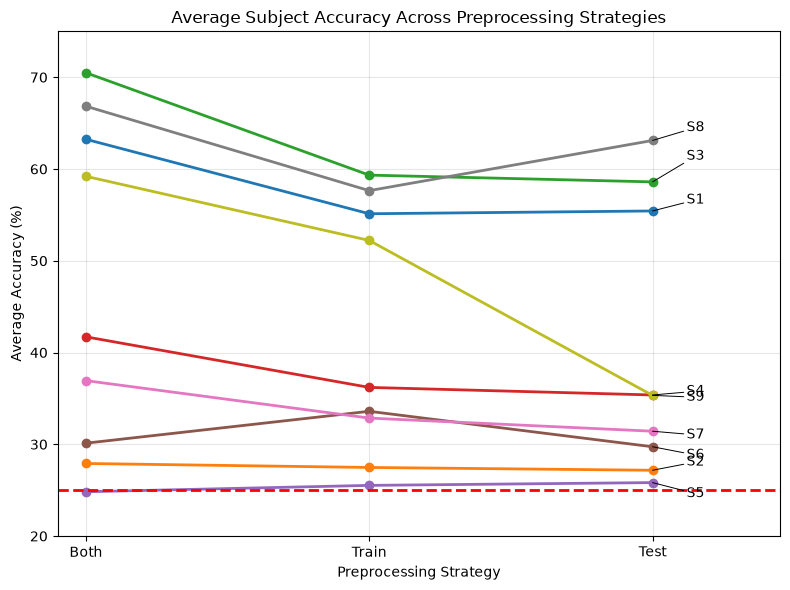

In [81]:
import matplotlib.pyplot as plt
import numpy as np

conditions = [
    "both_train_test",
    "train_only",
    "test_only"
]

offsets = {
    1: 1.2,
    2: 0.9,
    3: 2.8,
    4: 0.4,
    5: -1.2,
    6: -0.9,
    7: -0.4,
    8: 1.4,
    9: -0.2
}

labels = [
    "Both",
    "Train",
    "Test"
]
plt.figure(figsize=(8,6))

for subject in range(1,10):

    means = []

    for condition in conditions:

        accs = [
            RESULTS[condition][param]["folds"][subject]["acc"]
            for param in RESULTS[condition]
        ]

        means.append(np.mean(accs) * 100)

    plt.plot(
        labels,
        means,
        marker='o',
        linewidth=2,
        label=f"S{subject}"
    )
    
    # Label at final point
    plt.annotate(
        f"S{subject}",
        xy=(2, means[-1]),
        xytext=(2.12, means[-1] + offsets[subject]),
        fontsize=10,
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            lw=0.7,
            shrinkA=0,
            shrinkB=0
        )
    )


# Chance level
plt.axhline(
    25,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Chance (25%)'
)



plt.xticks(range(3), labels)
plt.xlim(-0.1, 2.45)
plt.ylim(20,75)

plt.ylabel("Average Accuracy (%)")
plt.xlabel("Preprocessing Strategy")
plt.title("Average Subject Accuracy Across Preprocessing Strategies")
plt.ylim(20, 75)   # optional, zooms into the useful range
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## noise

In [72]:
"""Standalone plotting script for the EEG adding-noise experiment.

All values are embedded directly in RESULTS. No result text files, parsers,
previous scripts, or __file__ are required at runtime.

The uploaded log contains three consecutive preprocessing-condition groups,
interpreted in the same order as the first experiment:
1. Both train and test preprocessed
2. Train only preprocessed
3. Test only preprocessed

Outputs:
- One 3x4 confusion-matrix figure per subject.
- Per-subject accuracy comparison figures.
- Reported average confusion matrices for all conditions and noise scales.
- Overall average confusion matrices across the four noise scales.
- Mean accuracy, AUC, and F1 comparison figures.
- CSV files containing summary and subject-level metrics.

Early-stopping epochs not present in the supplied log remain None:
both_train_test scale 0.3 subject 1, both_train_test scale 0.3 subject 8, both_train_test scale 0.4 subject 1, train_only scale 0.2 subject 1, test_only scale 0.2 subject 1, test_only scale 0.3 subject 1, test_only scale 0.4 subject 1
"""

from __future__ import annotations

import csv
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path.cwd() / "adding_noise_three_preprocessing_condition_plots"
CLASS_NAMES = ["feet", "Right hand", "Left hand", "Tongue"]
SCALES = [0.1, 0.2, 0.3, 0.4]
SUBJECTS = list(range(1, 10))
DPI = 160
CONDITION_LABELS = {
    "both_train_test": "Both train and test preprocessed",
    "train_only": "Train only preprocessed",
    "test_only": "Test only preprocessed",
}
CONDITION_ORDER = ["both_train_test", "train_only", "test_only"]

RESULTS = {'both_train_test': {0.1: {'folds': {1: {'epoch': 43,
                                         'matrix': [[0.63194444, 0.1875, 0.0625, 0.11805556],
                                                    [0.03472222, 0.77777778, 0.18055556, 0.00694444],
                                                    [0.02083333, 0.10416667, 0.86805556, 0.00694444],
                                                    [0.52083333, 0.21527778, 0.00694444, 0.25694444]],
                                         'acc': 0.6336805555555556,
                                         'auc': 0.8715117026748972,
                                         'fmeasure': 0.6107125597506213},
                                     2: {'epoch': 34,
                                         'matrix': [[0.18055556, 0.43055556, 0.23611111, 0.15277778],
                                                    [0.10416667, 0.61805556, 0.22916667, 0.04861111],
                                                    [0.16666667, 0.40277778, 0.375, 0.05555556],
                                                    [0.09722222, 0.52083333, 0.25, 0.13194444]],
                                         'acc': 0.3263888888888889,
                                         'auc': 0.603342817644033,
                                         'fmeasure': 0.2994689234201238},
                                     3: {'epoch': 51,
                                         'matrix': [[0.50694444, 0.11111111, 0.10416667, 0.27777778],
                                                    [0.01388889, 0.72222222, 0.00694444, 0.25694444],
                                                    [0.0625, 0.07638889, 0.64583333, 0.21527778],
                                                    [0.04861111, 0.01388889, 0.0, 0.9375]],
                                         'acc': 0.703125,
                                         'auc': 0.9217705118312757,
                                         'fmeasure': 0.7012578517594481},
                                     4: {'epoch': 24,
                                         'matrix': [[0.42361111, 0.14583333, 0.20138889, 0.22916667],
                                                    [0.31944444, 0.20138889, 0.46527778, 0.01388889],
                                                    [0.19444444, 0.02777778, 0.75694444, 0.02083333],
                                                    [0.33333333, 0.04166667, 0.40277778, 0.22222222]],
                                         'acc': 0.4010416666666667,
                                         'auc': 0.7054157021604938,
                                         'fmeasure': 0.37302359167319243},
                                     5: {'epoch': 15,
                                         'matrix': [[0.0, 0.99305556, 0.00694444, 0.0],
                                                    [0.0, 0.97916667, 0.02083333, 0.0],
                                                    [0.0, 0.99305556, 0.00694444, 0.0],
                                                    [0.0, 0.97222222, 0.02777778, 0.0]],
                                         'acc': 0.2465277777777778,
                                         'auc': 0.4876221707818929,
                                         'fmeasure': 0.10242409199966906},
                                     6: {'epoch': 17,
                                         'matrix': [[0.25694444, 0.09027778, 0.04166667, 0.61111111],
                                                    [0.35416667, 0.23611111, 0.10416667, 0.30555556],
                                                    [0.25694444, 0.09027778, 0.29166667, 0.36111111],
                                                    [0.1875, 0.09722222, 0.06944444, 0.64583333]],
                                         'acc': 0.3576388888888889,
                                         'auc': 0.655446244855967,
                                         'fmeasure': 0.34770715133783553},
                                     7: {'epoch': 31,
                                         'matrix': [[0.09027778, 0.38194444, 0.50694444, 0.02083333],
                                                    [0.02777778, 0.46527778, 0.45833333, 0.04861111],
                                                    [0.04861111, 0.41666667, 0.52083333, 0.01388889],
                                                    [0.09722222, 0.39583333, 0.18055556, 0.32638889]],
                                         'acc': 0.3506944444444444,
                                         'auc': 0.661450295781893,
                                         'fmeasure': 0.33660144543659726},
                                     8: {'epoch': 26,
                                         'matrix': [[0.4375, 0.15277778, 0.15277778, 0.25694444],
                                                    [0.06944444, 0.76388889, 0.01388889, 0.15277778],
                                                    [0.04166667, 0.05555556, 0.73611111, 0.16666667],
                                                    [0.13888889, 0.02083333, 0.04166667, 0.79861111]],
                                         'acc': 0.6840277777777778,
                                         'auc': 0.8990282600308642,
                                         'fmeasure': 0.678681629548125},
                                     9: {'epoch': 39,
                                         'matrix': [[0.45833333, 0.06944444, 0.10416667, 0.36805556],
                                                    [0.03472222, 0.65277778, 0.26388889, 0.04861111],
                                                    [0.23611111, 0.04166667, 0.52083333, 0.20138889],
                                                    [0.15277778, 0.02777778, 0.01388889, 0.80555556]],
                                         'acc': 0.609375,
                                         'auc': 0.8538612397119342,
                                         'fmeasure': 0.6069921859643002}},
                           'summary': {'acc_mean': 0.4792,
                                       'acc_std': 0.1659,
                                       'auc_mean': 0.7399,
                                       'auc_std': 0.1436,
                                       'fmeasure_mean': 0.4508,
                                       'fmeasure_std': 0.194},
                           'average_matrix': [[0.33179012, 0.28472222, 0.15740741, 0.22608025],
                                              [0.10648148, 0.60185185, 0.19367284, 0.09799383],
                                              [0.11419753, 0.24537037, 0.52469136, 0.11574074],
                                              [0.17515432, 0.25617284, 0.11033951, 0.45833333]]},
                     0.2: {'folds': {1: {'epoch': 47,
                                         'matrix': [[0.41666667, 0.30555556, 0.05555556, 0.22222222],
                                                    [0.00694444, 0.86111111, 0.11805556, 0.01388889],
                                                    [0.00694444, 0.1875, 0.79861111, 0.00694444],
                                                    [0.36111111, 0.26388889, 0.0, 0.375]],
                                         'acc': 0.6128472222222222,
                                         'auc': 0.8870482896090536,
                                         'fmeasure': 0.5990799202477671},
                                     2: {'epoch': 28,
                                         'matrix': [[0.39583333, 0.3125, 0.18055556, 0.11111111],
                                                    [0.28472222, 0.5, 0.20138889, 0.01388889],
                                                    [0.36111111, 0.24305556, 0.38888889, 0.00694444],
                                                    [0.26388889, 0.42361111, 0.20833333, 0.10416667]],
                                         'acc': 0.3472222222222222,
                                         'auc': 0.6277126736111112,
                                         'fmeasure': 0.32706415512419157},
                                     3: {'epoch': 27,
                                         'matrix': [[0.47222222, 0.15277778, 0.19444444, 0.18055556],
                                                    [0.08333333, 0.77777778, 0.00694444, 0.13194444],
                                                    [0.04861111, 0.06944444, 0.79166667, 0.09027778],
                                                    [0.20833333, 0.01388889, 0.0, 0.77777778]],
                                         'acc': 0.7048611111111112,
                                         'auc': 0.9094851144547326,
                                         'fmeasure': 0.7003218683311679},
                                     4: {'epoch': 25,
                                         'matrix': [[0.49305556, 0.14583333, 0.09027778, 0.27083333],
                                                    [0.4375, 0.27083333, 0.27083333, 0.02083333],
                                                    [0.34722222, 0.0625, 0.5625, 0.02777778],
                                                    [0.43055556, 0.07638889, 0.20833333, 0.28472222]],
                                         'acc': 0.4027777777777778,
                                         'auc': 0.6893888245884773,
                                         'fmeasure': 0.3987456253030357},
                                     5: {'epoch': 15,
                                         'matrix': [[0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0]],
                                         'acc': 0.25,
                                         'auc': 0.5321863747427983,
                                         'fmeasure': 0.1},
                                     6: {'epoch': 16,
                                         'matrix': [[0.43055556, 0.08333333, 0.02083333, 0.46527778],
                                                    [0.48611111, 0.24305556, 0.09722222, 0.17361111],
                                                    [0.47222222, 0.09027778, 0.15277778, 0.28472222],
                                                    [0.49305556, 0.07638889, 0.08333333, 0.34722222]],
                                         'acc': 0.2934027777777778,
                                         'auc': 0.6004734117798354,
                                         'fmeasure': 0.2889569998165678},
                                     7: {'epoch': 32,
                                         'matrix': [[0.04166667, 0.44444444, 0.49305556, 0.02083333],
                                                    [0.01388889, 0.55555556, 0.39583333, 0.03472222],
                                                    [0.03472222, 0.42361111, 0.51388889, 0.02777778],
                                                    [0.03472222, 0.42361111, 0.15972222, 0.38194444]],
                                         'acc': 0.3732638888888889,
                                         'auc': 0.6435908564814814,
                                         'fmeasure': 0.3466822503928041},
                                     8: {'epoch': 54,
                                         'matrix': [[0.40277778, 0.06944444, 0.29861111, 0.22916667],
                                                    [0.03472222, 0.71527778, 0.0625, 0.1875],
                                                    [0.02777778, 0.01388889, 0.85416667, 0.10416667],
                                                    [0.02083333, 0.01388889, 0.13888889, 0.82638889]],
                                         'acc': 0.6996527777777778,
                                         'auc': 0.9089144483024693,
                                         'fmeasure': 0.6902834585165436},
                                     9: {'epoch': 19,
                                         'matrix': [[0.25, 0.02083333, 0.16666667, 0.5625],
                                                    [0.13194444, 0.22222222, 0.59722222, 0.04861111],
                                                    [0.23611111, 0.00694444, 0.40972222, 0.34722222],
                                                    [0.06944444, 0.00694444, 0.05555556, 0.86805556]],
                                         'acc': 0.4375,
                                         'auc': 0.774707433127572,
                                         'fmeasure': 0.40793482921845603}},
                           'summary': {'acc_mean': 0.4579,
                                       'acc_std': 0.1621,
                                       'auc_mean': 0.7304,
                                       'auc_std': 0.136,
                                       'fmeasure_mean': 0.4288,
                                       'fmeasure_std': 0.1877},
                           'average_matrix': [[0.32253086, 0.2816358, 0.16666667, 0.22916667],
                                              [0.16435185, 0.57175926, 0.19444444, 0.06944444],
                                              [0.17052469, 0.23302469, 0.49691358, 0.09953704],
                                              [0.20910494, 0.25540123, 0.09490741, 0.44058642]]},
                     0.3: {'folds': {1: {'epoch': None,
                                         'matrix': [[0.58333333, 0.13888889, 0.0625, 0.21527778],
                                                    [0.04166667, 0.78472222, 0.15277778, 0.02083333],
                                                    [0.02777778, 0.13888889, 0.82638889, 0.00694444],
                                                    [0.50694444, 0.1875, 0.0, 0.30555556]],
                                         'acc': 0.625,
                                         'auc': 0.8669785236625515,
                                         'fmeasure': 0.6104666084617684},
                                     2: {'epoch': 24,
                                         'matrix': [[0.08333333, 0.63888889, 0.20833333, 0.06944444],
                                                    [0.04166667, 0.75694444, 0.19444444, 0.00694444],
                                                    [0.04166667, 0.625, 0.30555556, 0.02777778],
                                                    [0.06944444, 0.6875, 0.20138889, 0.04166667]],
                                         'acc': 0.296875,
                                         'auc': 0.6238948366769548,
                                         'fmeasure': 0.2339496084439905},
                                     3: {'epoch': 43,
                                         'matrix': [[0.59027778, 0.09027778, 0.125, 0.19444444],
                                                    [0.08333333, 0.72222222, 0.00694444, 0.1875],
                                                    [0.15277778, 0.03472222, 0.65972222, 0.15277778],
                                                    [0.16666667, 0.01388889, 0.0, 0.81944444]],
                                         'acc': 0.6979166666666666,
                                         'auc': 0.917088638117284,
                                         'fmeasure': 0.7002632995065347},
                                     4: {'epoch': 24,
                                         'matrix': [[0.11805556, 0.34027778, 0.25694444, 0.28472222],
                                                    [0.09027778, 0.46527778, 0.38194444, 0.0625],
                                                    [0.03472222, 0.13194444, 0.79861111, 0.03472222],
                                                    [0.13194444, 0.1875, 0.40972222, 0.27083333]],
                                         'acc': 0.4131944444444444,
                                         'auc': 0.6857799639917697,
                                         'fmeasure': 0.37458309266056755},
                                     5: {'epoch': 15,
                                         'matrix': [[0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0],
                                                    [0.0, 1.0, 0.0, 0.0]],
                                         'acc': 0.25,
                                         'auc': 0.49216338734567894,
                                         'fmeasure': 0.1},
                                     6: {'epoch': 16,
                                         'matrix': [[0.30555556, 0.04861111, 0.00694444, 0.63888889],
                                                    [0.45138889, 0.10416667, 0.05555556, 0.38888889],
                                                    [0.43055556, 0.07638889, 0.0625, 0.43055556],
                                                    [0.28472222, 0.04166667, 0.02777778, 0.64583333]],
                                         'acc': 0.2795138888888889,
                                         'auc': 0.613964441872428,
                                         'fmeasure': 0.23391663873888946},
                                     7: {'epoch': 18,
                                         'matrix': [[0.02083333, 0.79861111, 0.16666667, 0.01388889],
                                                    [0.01388889, 0.86805556, 0.09722222, 0.02083333],
                                                    [0.00694444, 0.86805556, 0.11111111, 0.01388889],
                                                    [0.06944444, 0.53472222, 0.22222222, 0.17361111]],
                                         'acc': 0.2934027777777778,
                                         'auc': 0.6214755336934156,
                                         'fmeasure': 0.2218356260707685},
                                     8: {'epoch': None,
                                         'matrix': [[0.38888889, 0.08333333, 0.4375, 0.09027778],
                                                    [0.0625, 0.75, 0.09722222, 0.09027778],
                                                    [0.01388889, 0.02777778, 0.90277778, 0.05555556],
                                                    [0.04166667, 0.02777778, 0.3125, 0.61805556]],
                                         'acc': 0.6649305555555556,
                                         'auc': 0.9024803883744855,
                                         'fmeasure': 0.6583697506373027},
                                     9: {'epoch': 40,
                                         'matrix': [[0.59027778, 0.13888889, 0.13888889, 0.13194444],
                                                    [0.00694444, 0.75694444, 0.22916667, 0.00694444],
                                                    [0.22222222, 0.07638889, 0.61805556, 0.08333333],
                                                    [0.25, 0.125, 0.07638889, 0.54861111]],
                                         'acc': 0.6284722222222222,
                                         'auc': 0.8552075295781894,
                                         'fmeasure': 0.6278146364393336}},
                           'summary': {'acc_mean': 0.461,
                                       'acc_std': 0.1787,
                                       'auc_mean': 0.731,
                                       'auc_std': 0.1469,
                                       'fmeasure_mean': 0.4179,
                                       'fmeasure_std': 0.218},
                           'average_matrix': [[0.29783951, 0.36419753, 0.1558642, 0.18209877],
                                              [0.08796296, 0.68981481, 0.13503086, 0.08719136],
                                              [0.10339506, 0.33101852, 0.47608025, 0.08950617],
                                              [0.16898148, 0.3117284, 0.13888889, 0.38040123]]},
                     0.4: {'folds': {1: {'epoch': None,
                                         'matrix': [[0.69444444, 0.1875, 0.0625, 0.05555556],
                                                    [0.02083333, 0.74305556, 0.22916667, 0.00694444],
                                                    [0.02083333, 0.05555556, 0.92361111, 0.0],
                                                    [0.59722222, 0.20833333, 0.0, 0.19444444]],
                                         'acc': 0.6388888888888888,
                                         'auc': 0.869530446244856,
                                         'fmeasure': 0.603925337419481},
                                     2: {'epoch': 33,
                                         'matrix': [[0.33333333, 0.25, 0.19444444, 0.22222222],
                                                    [0.33333333, 0.34027778, 0.27777778, 0.04861111],
                                                    [0.34027778, 0.1875, 0.41666667, 0.05555556],
                                                    [0.30555556, 0.25694444, 0.28472222, 0.15277778]],
                                         'acc': 0.3107638888888889,
                                         'auc': 0.5860178755144033,
                                         'fmeasure': 0.30317965736802016},
                                     3: {'epoch': 54,
                                         'matrix': [[0.47916667, 0.125, 0.19444444, 0.20138889],
                                                    [0.0625, 0.79861111, 0.00694444, 0.13194444],
                                                    [0.0625, 0.06944444, 0.6875, 0.18055556],
                                                    [0.1875, 0.03472222, 0.02083333, 0.75694444]],
                                         'acc': 0.6805555555555556,
                                         'auc': 0.914014274691358,
                                         'fmeasure': 0.6773054051184028},
                                     4: {'epoch': 25,
                                         'matrix': [[0.04166667, 0.23611111, 0.40972222, 0.3125],
                                                    [0.03472222, 0.35416667, 0.57638889, 0.03472222],
                                                    [0.0, 0.07638889, 0.89583333, 0.02777778],
                                                    [0.0, 0.09027778, 0.65972222, 0.25]],
                                         'acc': 0.3854166666666667,
                                         'auc': 0.6943560313786009,
                                         'fmeasure': 0.3235390177020405},
                                     5: {'epoch': 15,
                                         'matrix': [[0.0, 0.97916667, 0.02083333, 0.0],
                                                    [0.0, 0.98611111, 0.01388889, 0.0],
                                                    [0.0, 0.97222222, 0.02777778, 0.0],
                                                    [0.0, 0.99305556, 0.00694444, 0.0]],
                                         'acc': 0.2534722222222222,
                                         'auc': 0.5143188978909464,
                                         'fmeasure': 0.112987012987013},
                                     6: {'epoch': 17,
                                         'matrix': [[0.41666667, 0.125, 0.0, 0.45833333],
                                                    [0.45833333, 0.36111111, 0.0, 0.18055556],
                                                    [0.47222222, 0.29861111, 0.00694444, 0.22222222],
                                                    [0.47222222, 0.09722222, 0.0, 0.43055556]],
                                         'acc': 0.3038194444444444,
                                         'auc': 0.6319806134259259,
                                         'fmeasure': 0.26722025482682055},
                                     7: {'epoch': 42,
                                         'matrix': [[0.04166667, 0.54166667, 0.375, 0.04166667],
                                                    [0.02083333, 0.67361111, 0.27083333, 0.03472222],
                                                    [0.0625, 0.55555556, 0.35416667, 0.02777778],
                                                    [0.0625, 0.41666667, 0.1875, 0.33333333]],
                                         'acc': 0.3506944444444444,
                                         'auc': 0.6533524627057613,
                                         'fmeasure': 0.32010275760444024},
                                     8: {'epoch': 47,
                                         'matrix': [[0.34027778, 0.09027778, 0.34722222, 0.22222222],
                                                    [0.07638889, 0.6875, 0.09722222, 0.13888889],
                                                    [0.02083333, 0.00694444, 0.875, 0.09722222],
                                                    [0.04166667, 0.0, 0.22222222, 0.73611111]],
                                         'acc': 0.6597222222222222,
                                         'auc': 0.8912197788065842,
                                         'fmeasure': 0.6474831445977797},
                                     9: {'epoch': 31,
                                         'matrix': [[0.58333333, 0.13888889, 0.17361111, 0.10416667],
                                                    [0.04861111, 0.65972222, 0.27083333, 0.02083333],
                                                    [0.3125, 0.05555556, 0.57638889, 0.05555556],
                                                    [0.25, 0.09722222, 0.09027778, 0.5625]],
                                         'acc': 0.5954861111111112,
                                         'auc': 0.8408805941358025,
                                         'fmeasure': 0.5998182778805802}},
                           'summary': {'acc_mean': 0.4643,
                                       'acc_std': 0.1652,
                                       'auc_mean': 0.7329,
                                       'auc_std': 0.1397,
                                       'fmeasure_mean': 0.4284,
                                       'fmeasure_std': 0.1926},
                           'average_matrix': [[0.32561728, 0.2970679, 0.19753086, 0.17978395],
                                              [0.11728395, 0.62268519, 0.19367284, 0.06635802],
                                              [0.14351852, 0.25308642, 0.52932099, 0.07407407],
                                              [0.21296296, 0.24382716, 0.16358025, 0.37962963]]}},
 'train_only': {0.1: {'folds': {1: {'epoch': 25,
                                    'matrix': [[0.57638889, 0.13194444, 0.04861111, 0.24305556],
                                               [0.08333333, 0.63194444, 0.25694444, 0.02777778],
                                               [0.02083333, 0.09027778, 0.88194444, 0.00694444],
                                               [0.43055556, 0.1875, 0.00694444, 0.375]],
                                    'acc': 0.6163194444444444,
                                    'auc': 0.846535011574074,
                                    'fmeasure': 0.6056698078965097},
                                2: {'epoch': 21,
                                    'matrix': [[0.13194444, 0.49305556, 0.17361111, 0.20138889],
                                               [0.06944444, 0.71527778, 0.15277778, 0.0625],
                                               [0.08333333, 0.55555556, 0.29166667, 0.06944444],
                                               [0.09027778, 0.61111111, 0.16666667, 0.13194444]],
                                    'acc': 0.3177083333333333,
                                    'auc': 0.5907560120884773,
                                    'fmeasure': 0.2806826351083722},
                                3: {'epoch': 37,
                                    'matrix': [[0.56944444, 0.11111111, 0.21527778, 0.10416667],
                                               [0.13888889, 0.70833333, 0.0625, 0.09027778],
                                               [0.09722222, 0.03472222, 0.86111111, 0.00694444],
                                               [0.25, 0.09027778, 0.04166667, 0.61805556]],
                                    'acc': 0.6892361111111112,
                                    'auc': 0.8994341563786009,
                                    'fmeasure': 0.6879559282000086},
                                4: {'epoch': 17,
                                    'matrix': [[0.4375, 0.07638889, 0.31944444, 0.16666667],
                                               [0.36805556, 0.15277778, 0.46527778, 0.01388889],
                                               [0.19444444, 0.03472222, 0.76388889, 0.00694444],
                                               [0.42361111, 0.04166667, 0.39583333, 0.13888889]],
                                    'acc': 0.3732638888888889,
                                    'auc': 0.6964940200617283,
                                    'fmeasure': 0.33084152002851663},
                                5: {'epoch': 15,
                                    'matrix': [[0.00694444, 0.99305556, 0.0, 0.0],
                                               [0.0, 0.97916667, 0.02083333, 0.0],
                                               [0.0, 0.99305556, 0.0, 0.00694444],
                                               [0.0, 0.98611111, 0.01388889, 0.0]],
                                    'acc': 0.2465277777777778,
                                    'auc': 0.5328293788580246,
                                    'fmeasure': 0.10232625622672534},
                                6: {'epoch': 15,
                                    'matrix': [[0.11111111, 0.08333333, 0.09027778, 0.71527778],
                                               [0.13194444, 0.09027778, 0.11111111, 0.66666667],
                                               [0.15972222, 0.08333333, 0.1875, 0.56944444],
                                               [0.10416667, 0.11805556, 0.13888889, 0.63888889]],
                                    'acc': 0.2569444444444444,
                                    'auc': 0.5436639981995884,
                                    'fmeasure': 0.22003313357122556},
                                7: {'epoch': 20,
                                    'matrix': [[0.3125, 0.36805556, 0.27083333, 0.04861111],
                                               [0.13888889, 0.52083333, 0.25, 0.09027778],
                                               [0.14583333, 0.47222222, 0.33333333, 0.04861111],
                                               [0.14583333, 0.33333333, 0.09722222, 0.42361111]],
                                    'acc': 0.3975694444444444,
                                    'auc': 0.639134034207819,
                                    'fmeasure': 0.40316568870944913},
                                8: {'epoch': 34,
                                    'matrix': [[0.65972222, 0.08333333, 0.14583333, 0.11111111],
                                               [0.1875, 0.63888889, 0.06944444, 0.10416667],
                                               [0.11111111, 0.01388889, 0.77083333, 0.10416667],
                                               [0.18055556, 0.02777778, 0.125, 0.66666667]],
                                    'acc': 0.6840277777777778,
                                    'auc': 0.8752250514403292,
                                    'fmeasure': 0.6857210987313557},
                                9: {'epoch': 23,
                                    'matrix': [[0.63194444, 0.02777778, 0.1875, 0.15277778],
                                               [0.11111111, 0.50694444, 0.36111111, 0.02083333],
                                               [0.27777778, 0.01388889, 0.5625, 0.14583333],
                                               [0.20833333, 0.00694444, 0.08333333, 0.70138889]],
                                    'acc': 0.6006944444444444,
                                    'auc': 0.8473789544753085,
                                    'fmeasure': 0.6063950527204018}},
                      'summary': {'acc_mean': 0.4647,
                                  'acc_std': 0.1717,
                                  'auc_mean': 0.7191,
                                  'auc_std': 0.1408,
                                  'fmeasure_mean': 0.4359,
                                  'fmeasure_std': 0.2049},
                      'average_matrix': [[0.38194444, 0.26311728, 0.16126543, 0.19367284],
                                         [0.13657407, 0.54938272, 0.19444444, 0.11959877],
                                         [0.12114198, 0.25462963, 0.51697531, 0.10725309],
                                         [0.2037037, 0.26697531, 0.11882716, 0.41049383]]},
                0.2: {'folds': {1: {'epoch': None,
                                    'matrix': [[0.36805556, 0.22916667, 0.14583333, 0.25694444],
                                               [0.02083333, 0.74305556, 0.22222222, 0.01388889],
                                               [0.01388889, 0.11111111, 0.86805556, 0.00694444],
                                               [0.22222222, 0.16666667, 0.02083333, 0.59027778]],
                                    'acc': 0.6423611111111112,
                                    'auc': 0.8684614519032922,
                                    'fmeasure': 0.6286715774014411},
                                2: {'epoch': 16,
                                    'matrix': [[0.3125, 0.23611111, 0.39583333, 0.05555556],
                                               [0.24305556, 0.24305556, 0.5, 0.01388889],
                                               [0.26388889, 0.14583333, 0.5625, 0.02777778],
                                               [0.29166667, 0.24305556, 0.40972222, 0.05555556]],
                                    'acc': 0.2934027777777778,
                                    'auc': 0.5666433577674898,
                                    'fmeasure': 0.26122825951384726},
                                3: {'epoch': 30,
                                    'matrix': [[0.45833333, 0.07638889, 0.17361111, 0.29166667],
                                               [0.17361111, 0.5625, 0.04166667, 0.22222222],
                                               [0.09722222, 0.02777778, 0.75, 0.125],
                                               [0.18055556, 0.04166667, 0.01388889, 0.76388889]],
                                    'acc': 0.6336805555555556,
                                    'auc': 0.8729343492798355,
                                    'fmeasure': 0.6330673681242441},
                                4: {'epoch': 29,
                                    'matrix': [[0.38888889, 0.24305556, 0.09027778, 0.27777778],
                                               [0.26388889, 0.52083333, 0.11805556, 0.09722222],
                                               [0.3125, 0.18055556, 0.42361111, 0.08333333],
                                               [0.36111111, 0.10416667, 0.13194444, 0.40277778]],
                                    'acc': 0.4340277777777778,
                                    'auc': 0.6899554719650207,
                                    'fmeasure': 0.4389884290013963},
                                5: {'epoch': 15,
                                    'matrix': [[0.0, 1.0, 0.0, 0.0],
                                               [0.0, 1.0, 0.0, 0.0],
                                               [0.0, 1.0, 0.0, 0.0],
                                               [0.0, 1.0, 0.0, 0.0]],
                                    'acc': 0.25,
                                    'auc': 0.5258929719650206,
                                    'fmeasure': 0.1},
                                6: {'epoch': 15,
                                    'matrix': [[0.15277778, 0.1875, 0.00694444, 0.65277778],
                                               [0.17361111, 0.31944444, 0.01388889, 0.49305556],
                                               [0.18055556, 0.3125, 0.01388889, 0.49305556],
                                               [0.18055556, 0.20833333, 0.00694444, 0.60416667]],
                                    'acc': 0.2725694444444444,
                                    'auc': 0.5491657021604938,
                                    'fmeasure': 0.22384903127226774},
                                7: {'epoch': 39,
                                    'matrix': [[0.33333333, 0.27083333, 0.33333333, 0.0625],
                                               [0.125, 0.55555556, 0.27083333, 0.04861111],
                                               [0.13888889, 0.375, 0.46527778, 0.02083333],
                                               [0.15972222, 0.29861111, 0.25694444, 0.28472222]],
                                    'acc': 0.4097222222222222,
                                    'auc': 0.6789038387345679,
                                    'fmeasure': 0.4064629672685939},
                                8: {'epoch': 32,
                                    'matrix': [[0.5625, 0.13194444, 0.09027778, 0.21527778],
                                               [0.19444444, 0.56944444, 0.01388889, 0.22222222],
                                               [0.07638889, 0.0625, 0.69444444, 0.16666667],
                                               [0.11805556, 0.02777778, 0.05555556, 0.79861111]],
                                    'acc': 0.65625,
                                    'auc': 0.8746061599794239,
                                    'fmeasure': 0.6564937312624363},
                                9: {'epoch': 18,
                                    'matrix': [[0.21527778, 0.33333333, 0.29861111, 0.15277778],
                                               [0.03472222, 0.75694444, 0.20833333, 0.0],
                                               [0.11805556, 0.07638889, 0.72916667, 0.07638889],
                                               [0.21527778, 0.14583333, 0.15277778, 0.48611111]],
                                    'acc': 0.546875,
                                    'auc': 0.8029112011316872,
                                    'fmeasure': 0.5259628037320816}},
                      'summary': {'acc_mean': 0.4599,
                                  'acc_std': 0.1562,
                                  'auc_mean': 0.7144,
                                  'auc_std': 0.137,
                                  'fmeasure_mean': 0.4305,
                                  'fmeasure_std': 0.1891},
                      'average_matrix': [[0.31018519, 0.30092593, 0.17052469, 0.2183642],
                                         [0.13657407, 0.58564815, 0.15432099, 0.12345679],
                                         [0.13348765, 0.25462963, 0.5007716, 0.11111111],
                                         [0.19212963, 0.24845679, 0.11651235, 0.44290123]]},
                0.3: {'folds': {1: {'epoch': 33,
                                    'matrix': [[0.77777778, 0.07638889, 0.07638889, 0.06944444],
                                               [0.07638889, 0.61805556, 0.28472222, 0.02083333],
                                               [0.01388889, 0.08333333, 0.90277778, 0.0],
                                               [0.73611111, 0.10416667, 0.00694444, 0.15277778]],
                                    'acc': 0.6128472222222222,
                                    'auc': 0.8630561985596709,
                                    'fmeasure': 0.5737692477760203},
                                2: {'epoch': 15,
                                    'matrix': [[0.02083333, 0.1875, 0.64583333, 0.14583333],
                                               [0.03472222, 0.29861111, 0.64583333, 0.02083333],
                                               [0.01388889, 0.14583333, 0.81944444, 0.02083333],
                                               [0.04166667, 0.22222222, 0.66666667, 0.06944444]],
                                    'acc': 0.3020833333333333,
                                    'auc': 0.5678811406893004,
                                    'fmeasure': 0.22597953631449474},
                                3: {'epoch': 50,
                                    'matrix': [[0.52083333, 0.11111111, 0.22916667, 0.13888889],
                                               [0.13888889, 0.74305556, 0.02777778, 0.09027778],
                                               [0.08333333, 0.125, 0.76388889, 0.02777778],
                                               [0.34027778, 0.04166667, 0.04861111, 0.56944444]],
                                    'acc': 0.6493055555555556,
                                    'auc': 0.8780341756687241,
                                    'fmeasure': 0.6493060917617939},
                                4: {'epoch': 29,
                                    'matrix': [[0.28472222, 0.26388889, 0.23611111, 0.21527778],
                                               [0.19444444, 0.46527778, 0.31944444, 0.02083333],
                                               [0.125, 0.13888889, 0.72222222, 0.01388889],
                                               [0.21527778, 0.13194444, 0.42361111, 0.22916667]],
                                    'acc': 0.4253472222222222,
                                    'auc': 0.6951798804012346,
                                    'fmeasure': 0.4057046005309863},
                                5: {'epoch': 15,
                                    'matrix': [[0.03472222, 0.96527778, 0.0, 0.0],
                                               [0.01388889, 0.98611111, 0.0, 0.0],
                                               [0.01388889, 0.97222222, 0.0, 0.01388889],
                                               [0.0, 1.0, 0.0, 0.0]],
                                    'acc': 0.2552083333333333,
                                    'auc': 0.5570023148148148,
                                    'fmeasure': 0.11648091300460005},
                                6: {'epoch': 15,
                                    'matrix': [[0.27083333, 0.09027778, 0.01388889, 0.625],
                                               [0.33333333, 0.11805556, 0.00694444, 0.54166667],
                                               [0.25694444, 0.18055556, 0.02083333, 0.54166667],
                                               [0.28472222, 0.09722222, 0.0, 0.61805556]],
                                    'acc': 0.2569444444444444,
                                    'auc': 0.5245587384259259,
                                    'fmeasure': 0.20572830119913416},
                                7: {'epoch': 36,
                                    'matrix': [[0.28472222, 0.35416667, 0.25694444, 0.10416667],
                                               [0.20833333, 0.4375, 0.25694444, 0.09722222],
                                               [0.13888889, 0.36805556, 0.41666667, 0.07638889],
                                               [0.20138889, 0.17361111, 0.13888889, 0.48611111]],
                                    'acc': 0.40625,
                                    'auc': 0.6623746141975309,
                                    'fmeasure': 0.4098679316816636},
                                8: {'epoch': 24,
                                    'matrix': [[0.47222222, 0.14583333, 0.11111111, 0.27083333],
                                               [0.13194444, 0.70138889, 0.01388889, 0.15277778],
                                               [0.15972222, 0.04166667, 0.63888889, 0.15972222],
                                               [0.16666667, 0.04166667, 0.11111111, 0.68055556]],
                                    'acc': 0.6232638888888888,
                                    'auc': 0.852125128600823,
                                    'fmeasure': 0.6246339533690022},
                                9: {'epoch': 15,
                                    'matrix': [[0.01388889, 0.04166667, 0.11111111, 0.83333333],
                                               [0.02083333, 0.03472222, 0.61111111, 0.33333333],
                                               [0.02083333, 0.00694444, 0.23611111, 0.73611111],
                                               [0.0, 0.00694444, 0.0, 0.99305556]],
                                    'acc': 0.3194444444444444,
                                    'auc': 0.7301713605967078,
                                    'fmeasure': 0.2102371825828212}},
                      'summary': {'acc_mean': 0.4279,
                                  'acc_std': 0.1522,
                                  'auc_mean': 0.7034,
                                  'auc_std': 0.1301,
                                  'fmeasure_mean': 0.3802,
                                  'fmeasure_std': 0.1897},
                      'average_matrix': [[0.29783951, 0.24845679, 0.1867284, 0.26697531],
                                         [0.12808642, 0.48919753, 0.24074074, 0.14197531],
                                         [0.09182099, 0.22916667, 0.50231481, 0.17669753],
                                         [0.22067901, 0.20216049, 0.15509259, 0.4220679]]},
                0.4: {'folds': {1: {'epoch': 18,
                                    'matrix': [[0.55555556, 0.08333333, 0.03472222, 0.32638889],
                                               [0.08333333, 0.64583333, 0.19444444, 0.07638889],
                                               [0.07638889, 0.15972222, 0.76388889, 0.0],
                                               [0.34027778, 0.08333333, 0.0, 0.57638889]],
                                    'acc': 0.6354166666666666,
                                    'auc': 0.8730910815329218,
                                    'fmeasure': 0.6361191952510725},
                                2: {'epoch': 15,
                                    'matrix': [[0.29861111, 0.56944444, 0.0, 0.13194444],
                                               [0.1875, 0.72916667, 0.01388889, 0.06944444],
                                               [0.25, 0.68055556, 0.01388889, 0.05555556],
                                               [0.23611111, 0.71527778, 0.0, 0.04861111]],
                                    'acc': 0.2725694444444444,
                                    'auc': 0.5425226658950617,
                                    'fmeasure': 0.19976221391178095},
                                3: {'epoch': 37,
                                    'matrix': [[0.57638889, 0.11805556, 0.16666667, 0.13888889],
                                               [0.125, 0.74305556, 0.00694444, 0.125],
                                               [0.14583333, 0.15972222, 0.60416667, 0.09027778],
                                               [0.1875, 0.04861111, 0.02083333, 0.74305556]],
                                    'acc': 0.6666666666666666,
                                    'auc': 0.8810562950102881,
                                    'fmeasure': 0.6662744124327172},
                                4: {'epoch': 45,
                                    'matrix': [[0.1875, 0.25, 0.27083333, 0.29166667],
                                               [0.13194444, 0.46527778, 0.34722222, 0.05555556],
                                               [0.09722222, 0.15277778, 0.71527778, 0.03472222],
                                               [0.20138889, 0.09722222, 0.45833333, 0.24305556]],
                                    'acc': 0.4027777777777778,
                                    'auc': 0.6931745113168724,
                                    'fmeasure': 0.3792102499896202},
                                5: {'epoch': 15,
                                    'matrix': [[0.01388889, 0.75694444, 0.22916667, 0.0],
                                               [0.0, 0.875, 0.11805556, 0.00694444],
                                               [0.00694444, 0.83333333, 0.15277778, 0.00694444],
                                               [0.0, 0.77777778, 0.22222222, 0.0]],
                                    'acc': 0.2604166666666667,
                                    'auc': 0.5494510352366255,
                                    'fmeasure': 0.15426721609925845},
                                6: {'epoch': 15,
                                    'matrix': [[0.16666667, 0.14583333, 0.09027778, 0.59722222],
                                               [0.34722222, 0.20138889, 0.13888889, 0.3125],
                                               [0.30555556, 0.09027778, 0.28472222, 0.31944444],
                                               [0.27777778, 0.18055556, 0.11111111, 0.43055556]],
                                    'acc': 0.2708333333333333,
                                    'auc': 0.5628938400205761,
                                    'fmeasure': 0.27051364438191716},
                                7: {'epoch': 16,
                                    'matrix': [[0.08333333, 0.40972222, 0.49305556, 0.01388889],
                                               [0.04166667, 0.51388889, 0.42361111, 0.02083333],
                                               [0.04166667, 0.53472222, 0.41666667, 0.00694444],
                                               [0.15277778, 0.45138889, 0.20833333, 0.1875]],
                                    'acc': 0.3003472222222222,
                                    'auc': 0.6499445408950617,
                                    'fmeasure': 0.2781228361839963},
                                8: {'epoch': 31,
                                    'matrix': [[0.56944444, 0.13194444, 0.16666667, 0.13194444],
                                               [0.125, 0.63888889, 0.04861111, 0.1875],
                                               [0.13888889, 0.04861111, 0.72222222, 0.09027778],
                                               [0.15972222, 0.08333333, 0.125, 0.63194444]],
                                    'acc': 0.640625,
                                    'auc': 0.8608338155864197,
                                    'fmeasure': 0.6405864343820548},
                                9: {'epoch': 25,
                                    'matrix': [[0.5625, 0.09722222, 0.13888889, 0.20138889],
                                               [0.09027778, 0.63888889, 0.23611111, 0.03472222],
                                               [0.36111111, 0.03472222, 0.52083333, 0.08333333],
                                               [0.3125, 0.08333333, 0.02777778, 0.57638889]],
                                    'acc': 0.5746527777777778,
                                    'auc': 0.8243192193930042,
                                    'fmeasure': 0.5805738799693094}},
                      'summary': {'acc_mean': 0.4471,
                                  'acc_std': 0.1691,
                                  'auc_mean': 0.7153,
                                  'auc_std': 0.1378,
                                  'fmeasure_mean': 0.4228,
                                  'fmeasure_std': 0.1958},
                      'average_matrix': [[0.33487654, 0.28472222, 0.17669753, 0.2037037],
                                         [0.1257716, 0.60570988, 0.16975309, 0.09876543],
                                         [0.15817901, 0.29938272, 0.46604938, 0.07638889],
                                         [0.20756173, 0.28009259, 0.13040123, 0.38194444]]}},
 'test_only': {0.1: {'folds': {1: {'epoch': 38,
                                   'matrix': [[0.59027778, 0.1875, 0.04861111, 0.17361111],
                                              [0.02083333, 0.875, 0.09722222, 0.00694444],
                                              [0.04166667, 0.1875, 0.77083333, 0.0],
                                              [0.53472222, 0.21527778, 0.0, 0.25]],
                                   'acc': 0.6215277777777778,
                                   'auc': 0.877805105452675,
                                   'fmeasure': 0.6008510209514675},
                               2: {'epoch': 24,
                                   'matrix': [[0.04861111, 0.54861111, 0.35416667, 0.04861111],
                                              [0.02777778, 0.6875, 0.28472222, 0.0],
                                              [0.03472222, 0.50694444, 0.45138889, 0.00694444],
                                              [0.02083333, 0.63194444, 0.30555556, 0.04166667]],
                                   'acc': 0.3072916666666667,
                                   'auc': 0.6261775012860081,
                                   'fmeasure': 0.23651448481276519},
                               3: {'epoch': 33,
                                   'matrix': [[0.40972222, 0.10416667, 0.18055556, 0.30555556],
                                              [0.04861111, 0.75694444, 0.00694444, 0.1875],
                                              [0.03472222, 0.04861111, 0.79166667, 0.125],
                                              [0.05555556, 0.00694444, 0.00694444, 0.93055556]],
                                   'acc': 0.7222222222222222,
                                   'auc': 0.9330713091563786,
                                   'fmeasure': 0.7116127708342438},
                               4: {'epoch': 23,
                                   'matrix': [[0.18055556, 0.24305556, 0.29861111, 0.27777778],
                                              [0.23611111, 0.33333333, 0.41666667, 0.01388889],
                                              [0.15277778, 0.05555556, 0.77083333, 0.02083333],
                                              [0.25694444, 0.09722222, 0.40277778, 0.24305556]],
                                   'acc': 0.3819444444444444,
                                   'auc': 0.689967528292181,
                                   'fmeasure': 0.357353661501813},
                               5: {'epoch': 15,
                                   'matrix': [[0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0]],
                                   'acc': 0.25,
                                   'auc': 0.5013603555812757,
                                   'fmeasure': 0.1},
                               6: {'epoch': 16,
                                   'matrix': [[0.21527778, 0.05555556, 0.01388889, 0.71527778],
                                              [0.36111111, 0.24305556, 0.02083333, 0.375],
                                              [0.3125, 0.18055556, 0.01388889, 0.49305556],
                                              [0.32638889, 0.10416667, 0.00694444, 0.5625]],
                                   'acc': 0.2586805555555556,
                                   'auc': 0.5821076067386831,
                                   'fmeasure': 0.22132664853605705},
                               7: {'epoch': 37,
                                   'matrix': [[0.09027778, 0.5625, 0.32638889, 0.02083333],
                                              [0.00694444, 0.625, 0.34027778, 0.02777778],
                                              [0.01388889, 0.52777778, 0.41666667, 0.04166667],
                                              [0.05555556, 0.49305556, 0.20138889, 0.25]],
                                   'acc': 0.3454861111111111,
                                   'auc': 0.6615306712962963,
                                   'fmeasure': 0.3205427326320833},
                               8: {'epoch': 50,
                                   'matrix': [[0.36111111, 0.09027778, 0.47916667, 0.06944444],
                                              [0.11805556, 0.75, 0.09722222, 0.03472222],
                                              [0.02083333, 0.0, 0.94444444, 0.03472222],
                                              [0.05555556, 0.02777778, 0.30555556, 0.61111111]],
                                   'acc': 0.6666666666666666,
                                   'auc': 0.9011461548353911,
                                   'fmeasure': 0.6584942646745621},
                               9: {'epoch': 28,
                                   'matrix': [[0.45138889, 0.13888889, 0.13888889, 0.27083333],
                                              [0.01388889, 0.69444444, 0.27083333, 0.02083333],
                                              [0.20833333, 0.07638889, 0.59722222, 0.11805556],
                                              [0.14583333, 0.08333333, 0.05555556, 0.71527778]],
                                   'acc': 0.6145833333333334,
                                   'auc': 0.8443287037037037,
                                   'fmeasure': 0.6113436277771981}},
                     'summary': {'acc_mean': 0.4632,
                                 'acc_std': 0.179,
                                 'auc_mean': 0.7353,
                                 'auc_std': 0.1477,
                                 'fmeasure_mean': 0.4242,
                                 'fmeasure_std': 0.2109},
                     'average_matrix': [[0.26080247, 0.32561728, 0.20447531, 0.20910494],
                                        [0.09259259, 0.66280864, 0.17052469, 0.07407407],
                                        [0.09104938, 0.28703704, 0.52854938, 0.0933642],
                                        [0.16126543, 0.29552469, 0.14274691, 0.40046296]]},
               0.2: {'folds': {1: {'epoch': None,
                                   'matrix': [[0.65972222, 0.10416667, 0.0625, 0.17361111],
                                              [0.01388889, 0.78472222, 0.19444444, 0.00694444],
                                              [0.02083333, 0.09722222, 0.875, 0.00694444],
                                              [0.47916667, 0.16666667, 0.00694444, 0.34722222]],
                                   'acc': 0.6666666666666666,
                                   'auc': 0.8812090084876543,
                                   'fmeasure': 0.6516828795056876},
                               2: {'epoch': 23,
                                   'matrix': [[0.26388889, 0.35416667, 0.10416667, 0.27777778],
                                              [0.25694444, 0.57638889, 0.09722222, 0.06944444],
                                              [0.3125, 0.42361111, 0.16666667, 0.09722222],
                                              [0.19444444, 0.5625, 0.08333333, 0.15972222]],
                                   'acc': 0.2916666666666667,
                                   'auc': 0.5875188882458848,
                                   'fmeasure': 0.2710778346863422},
                               3: {'epoch': 27,
                                   'matrix': [[0.40972222, 0.11111111, 0.02083333, 0.45833333],
                                              [0.04861111, 0.60416667, 0.0, 0.34722222],
                                              [0.07638889, 0.09722222, 0.40277778, 0.42361111],
                                              [0.02777778, 0.00694444, 0.0, 0.96527778]],
                                   'acc': 0.5954861111111112,
                                   'auc': 0.9167550797325102,
                                   'fmeasure': 0.5896920166181416},
                               4: {'epoch': 21,
                                   'matrix': [[0.0625, 0.22222222, 0.3125, 0.40277778],
                                              [0.03472222, 0.44444444, 0.375, 0.14583333],
                                              [0.02083333, 0.11805556, 0.79861111, 0.0625],
                                              [0.04166667, 0.125, 0.42361111, 0.40972222]],
                                   'acc': 0.4288194444444444,
                                   'auc': 0.6931463798868313,
                                   'fmeasure': 0.3819158181747552},
                               5: {'epoch': 15,
                                   'matrix': [[0.0, 0.95833333, 0.04166667, 0.0],
                                              [0.0, 0.9375, 0.0625, 0.0],
                                              [0.0, 0.97222222, 0.02777778, 0.0],
                                              [0.0, 0.97222222, 0.02777778, 0.0]],
                                   'acc': 0.24131944444444445,
                                   'auc': 0.5237851240997943,
                                   'fmeasure': 0.1088196633991701},
                               6: {'epoch': 16,
                                   'matrix': [[0.20833333, 0.05555556, 0.07638889, 0.65972222],
                                              [0.31944444, 0.28472222, 0.08333333, 0.3125],
                                              [0.25694444, 0.21527778, 0.17361111, 0.35416667],
                                              [0.21527778, 0.11805556, 0.09722222, 0.56944444]],
                                   'acc': 0.3090277777777778,
                                   'auc': 0.619016042952675,
                                   'fmeasure': 0.29614652857337864},
                               7: {'epoch': 24,
                                   'matrix': [[0.04166667, 0.69444444, 0.24305556, 0.02083333],
                                              [0.02083333, 0.77777778, 0.18055556, 0.02083333],
                                              [0.00694444, 0.71527778, 0.27083333, 0.00694444],
                                              [0.02083333, 0.55555556, 0.14583333, 0.27777778]],
                                   'acc': 0.3420138888888889,
                                   'auc': 0.6615427276234568,
                                   'fmeasure': 0.3013013316960751},
                               8: {'epoch': 50,
                                   'matrix': [[0.76388889, 0.05555556, 0.15277778, 0.02777778],
                                              [0.25, 0.63888889, 0.04861111, 0.0625],
                                              [0.11111111, 0.01388889, 0.81944444, 0.05555556],
                                              [0.18055556, 0.01388889, 0.20138889, 0.60416667]],
                                   'acc': 0.7065972222222222,
                                   'auc': 0.9012626993312759,
                                   'fmeasure': 0.7081405691891993},
                               9: {'epoch': 34,
                                   'matrix': [[0.63888889, 0.06944444, 0.15277778, 0.13888889],
                                              [0.02083333, 0.68055556, 0.28472222, 0.01388889],
                                              [0.27083333, 0.05555556, 0.63194444, 0.04166667],
                                              [0.24305556, 0.06944444, 0.11111111, 0.57638889]],
                                   'acc': 0.6319444444444444,
                                   'auc': 0.859109760802469,
                                   'fmeasure': 0.6360958943494552}},
                     'summary': {'acc_mean': 0.4682,
                                 'acc_std': 0.1715,
                                 'auc_mean': 0.7381,
                                 'auc_std': 0.1431,
                                 'fmeasure_mean': 0.4383,
                                 'fmeasure_std': 0.1997},
                     'average_matrix': [[0.33873457, 0.29166667, 0.12962963, 0.23996914],
                                        [0.10725309, 0.63657407, 0.14737654, 0.1087963],
                                        [0.11959877, 0.30092593, 0.46296296, 0.11651235],
                                        [0.1558642, 0.28780864, 0.12191358, 0.43441358]]},
               0.3: {'folds': {1: {'epoch': None,
                                   'matrix': [[0.59027778, 0.13194444, 0.03472222, 0.24305556],
                                              [0.04166667, 0.84722222, 0.05555556, 0.05555556],
                                              [0.05555556, 0.38888889, 0.50694444, 0.04861111],
                                              [0.45138889, 0.15972222, 0.00694444, 0.38194444]],
                                   'acc': 0.5815972222222222,
                                   'auc': 0.8543233989197531,
                                   'fmeasure': 0.5740198556463617},
                               2: {'epoch': 17,
                                   'matrix': [[0.10416667, 0.54861111, 0.07638889, 0.27083333],
                                              [0.11805556, 0.70138889, 0.06944444, 0.11111111],
                                              [0.14583333, 0.625, 0.09027778, 0.13888889],
                                              [0.11111111, 0.68055556, 0.03472222, 0.17361111]],
                                   'acc': 0.2673611111111111,
                                   'auc': 0.5444155092592592,
                                   'fmeasure': 0.22059271398541522},
                               3: {'epoch': 33,
                                   'matrix': [[0.41666667, 0.14583333, 0.13194444, 0.30555556],
                                              [0.125, 0.6875, 0.00694444, 0.18055556],
                                              [0.11805556, 0.07638889, 0.54166667, 0.26388889],
                                              [0.11805556, 0.0625, 0.00694444, 0.8125]],
                                   'acc': 0.6145833333333334,
                                   'auc': 0.8816349987139916,
                                   'fmeasure': 0.6105136871742348},
                               4: {'epoch': 20,
                                   'matrix': [[0.16666667, 0.24305556, 0.19444444, 0.39583333],
                                              [0.1875, 0.48611111, 0.25, 0.07638889],
                                              [0.10416667, 0.14583333, 0.6875, 0.0625],
                                              [0.10416667, 0.11111111, 0.34722222, 0.4375]],
                                   'acc': 0.4444444444444444,
                                   'auc': 0.6900961291152264,
                                   'fmeasure': 0.42528191085357614},
                               5: {'epoch': 15,
                                   'matrix': [[0.0, 0.95833333, 0.04166667, 0.0],
                                              [0.0, 0.95138889, 0.04861111, 0.0],
                                              [0.0, 0.97916667, 0.02083333, 0.0],
                                              [0.0, 0.93055556, 0.06944444, 0.0]],
                                   'acc': 0.24305555555555555,
                                   'auc': 0.5160469714506173,
                                   'fmeasure': 0.10752669944058314},
                               6: {'epoch': 16,
                                   'matrix': [[0.15972222, 0.04166667, 0.03472222, 0.76388889],
                                              [0.24305556, 0.16666667, 0.11805556, 0.47222222],
                                              [0.24305556, 0.11805556, 0.09722222, 0.54166667],
                                              [0.1875, 0.07638889, 0.04166667, 0.69444444]],
                                   'acc': 0.2795138888888889,
                                   'auc': 0.5853226273148149,
                                   'fmeasure': 0.24060095525681602},
                               7: {'epoch': 23,
                                   'matrix': [[0.14583333, 0.46527778, 0.35416667, 0.03472222],
                                              [0.06944444, 0.60416667, 0.29861111, 0.02777778],
                                              [0.09027778, 0.54861111, 0.34027778, 0.02083333],
                                              [0.20138889, 0.3125, 0.125, 0.36111111]],
                                   'acc': 0.3628472222222222,
                                   'auc': 0.6419994212962963,
                                   'fmeasure': 0.3567955343470317},
                               8: {'epoch': 32,
                                   'matrix': [[0.625, 0.10416667, 0.25, 0.02083333],
                                              [0.16666667, 0.73611111, 0.02777778, 0.06944444],
                                              [0.09027778, 0.03472222, 0.8125, 0.0625],
                                              [0.1875, 0.03472222, 0.23611111, 0.54166667]],
                                   'acc': 0.6788194444444444,
                                   'auc': 0.8832425090020576,
                                   'fmeasure': 0.6781969153820809},
                               9: {'epoch': 37,
                                   'matrix': [[0.63888889, 0.05555556, 0.20138889, 0.10416667],
                                              [0.02083333, 0.63194444, 0.34027778, 0.00694444],
                                              [0.27083333, 0.0625, 0.63888889, 0.02777778],
                                              [0.30555556, 0.04861111, 0.09027778, 0.55555556]],
                                   'acc': 0.6163194444444444,
                                   'auc': 0.8586234889403291,
                                   'fmeasure': 0.6231400276369444}},
                     'summary': {'acc_mean': 0.4543,
                                 'acc_std': 0.1623,
                                 'auc_mean': 0.7173,
                                 'auc_std': 0.1443,
                                 'fmeasure_mean': 0.4263,
                                 'fmeasure_std': 0.1947},
                     'average_matrix': [[0.31635802, 0.29938272, 0.14660494, 0.23765432],
                                        [0.10802469, 0.64583333, 0.13503086, 0.11111111],
                                        [0.1242284, 0.33101852, 0.41512346, 0.12962963],
                                        [0.18518519, 0.26851852, 0.10648148, 0.43981481]]},
               0.4: {'folds': {1: {'epoch': None,
                                   'matrix': [[0.72916667, 0.10416667, 0.08333333, 0.08333333],
                                              [0.14583333, 0.63888889, 0.19444444, 0.02083333],
                                              [0.08333333, 0.04166667, 0.875, 0.0],
                                              [0.59027778, 0.14583333, 0.01388889, 0.25]],
                                   'acc': 0.6232638888888888,
                                   'auc': 0.8636750900205761,
                                   'fmeasure': 0.602750166247216},
                               2: {'epoch': 16,
                                   'matrix': [[0.32638889, 0.26388889, 0.06944444, 0.34027778],
                                              [0.26388889, 0.38194444, 0.11111111, 0.24305556],
                                              [0.3125, 0.375, 0.07638889, 0.23611111],
                                              [0.25, 0.38888889, 0.11111111, 0.25]],
                                   'acc': 0.2586805555555556,
                                   'auc': 0.5149819958847736,
                                   'fmeasure': 0.24337863836364504},
                               3: {'epoch': 46,
                                   'matrix': [[0.48611111, 0.16666667, 0.25, 0.09722222],
                                              [0.05555556, 0.86805556, 0.02777778, 0.04861111],
                                              [0.08333333, 0.125, 0.74305556, 0.04861111],
                                              [0.25, 0.09722222, 0.08333333, 0.56944444]],
                                   'acc': 0.6666666666666666,
                                   'auc': 0.891163515946502,
                                   'fmeasure': 0.6599223015376441},
                               4: {'epoch': 17,
                                   'matrix': [[0.06944444, 0.08333333, 0.05555556, 0.79166667],
                                              [0.11805556, 0.29861111, 0.13888889, 0.44444444],
                                              [0.13194444, 0.20138889, 0.29166667, 0.375],
                                              [0.09027778, 0.09027778, 0.09027778, 0.72916667]],
                                   'acc': 0.3472222222222222,
                                   'auc': 0.6648943865740741,
                                   'fmeasure': 0.3155007824926508},
                               5: {'epoch': 15,
                                   'matrix': [[0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0],
                                              [0.0, 1.0, 0.0, 0.0]],
                                   'acc': 0.25,
                                   'auc': 0.5138848701131687,
                                   'fmeasure': 0.1},
                               6: {'epoch': 16,
                                   'matrix': [[0.04861111, 0.0, 0.01388889, 0.9375],
                                              [0.13888889, 0.00694444, 0.02083333, 0.83333333],
                                              [0.04861111, 0.01388889, 0.02777778, 0.90972222],
                                              [0.03472222, 0.0, 0.02083333, 0.94444444]],
                                   'acc': 0.2569444444444444,
                                   'auc': 0.5847680362654321,
                                   'fmeasure': 0.1374496585269419},
                               7: {'epoch': 25,
                                   'matrix': [[0.06944444, 0.48611111, 0.375, 0.06944444],
                                              [0.03472222, 0.54861111, 0.3125, 0.10416667],
                                              [0.04166667, 0.49305556, 0.36805556, 0.09722222],
                                              [0.07638889, 0.34027778, 0.13888889, 0.44444444]],
                                   'acc': 0.3576388888888889,
                                   'auc': 0.6429518711419753,
                                   'fmeasure': 0.3374661527623113},
                               8: {'epoch': 38,
                                   'matrix': [[0.875, 0.01388889, 0.04166667, 0.06944444],
                                              [0.54166667, 0.28472222, 0.03472222, 0.13888889],
                                              [0.44444444, 0.00694444, 0.36805556, 0.18055556],
                                              [0.24305556, 0.00694444, 0.08333333, 0.66666667]],
                                   'acc': 0.5486111111111112,
                                   'auc': 0.8672839506172839,
                                   'fmeasure': 0.5320219133977523},
                               9: {'epoch': 29,
                                   'matrix': [[0.67361111, 0.04861111, 0.09027778, 0.1875],
                                              [0.18055556, 0.66666667, 0.15277778, 0.0],
                                              [0.46527778, 0.04861111, 0.42361111, 0.0625],
                                              [0.29166667, 0.05555556, 0.00694444, 0.64583333]],
                                   'acc': 0.6024305555555556,
                                   'auc': 0.843922807355967,
                                   'fmeasure': 0.6090811554995375}},
                     'summary': {'acc_mean': 0.4346,
                                 'acc_std': 0.1636,
                                 'auc_mean': 0.7097,
                                 'auc_std': 0.1483,
                                 'fmeasure_mean': 0.3931,
                                 'fmeasure_std': 0.2011},
                     'average_matrix': [[0.36419753, 0.24074074, 0.1087963, 0.28626543],
                                        [0.16435185, 0.52160494, 0.11033951, 0.2037037],
                                        [0.17901235, 0.25617284, 0.35262346, 0.21219136],
                                        [0.2029321, 0.23611111, 0.06095679, 0.5]]}}}

def validate_results() -> None:
    """Fail early if any embedded value is missing or malformed."""
    expected_conditions = set(CONDITION_ORDER)
    if set(RESULTS) != expected_conditions:
        raise ValueError(f"Unexpected conditions: {set(RESULTS)}")

    subject_matrix_count = 0
    average_matrix_count = 0

    for condition in CONDITION_ORDER:
        condition_data = RESULTS[condition]
        if set(condition_data) != set(SCALES):
            raise ValueError(f"{condition} does not contain all scales")

        for scale in SCALES:
            scale_data = condition_data[scale]
            if set(scale_data["folds"]) != set(SUBJECTS):
                raise ValueError(f"{condition}, scale {scale} does not contain subjects 1-9")

            average = np.asarray(scale_data["average_matrix"], dtype=float)
            if average.shape != (4, 4):
                raise ValueError(f"Invalid average matrix: {condition}, scale {scale}")
            average_matrix_count += 1

            for subject in SUBJECTS:
                data = scale_data["folds"][subject]
                matrix = np.asarray(data["matrix"], dtype=float)
                if matrix.shape != (4, 4):
                    raise ValueError(
                        f"Invalid subject matrix: {condition}, scale {scale}, subject {subject}"
                    )
                for metric in ("acc", "auc", "fmeasure"):
                    if not np.isfinite(float(data[metric])):
                        raise ValueError(
                            f"Invalid {metric}: {condition}, scale {scale}, subject {subject}"
                        )
                subject_matrix_count += 1

    if subject_matrix_count != 108:
        raise ValueError(f"Expected 108 subject matrices, found {subject_matrix_count}")
    if average_matrix_count != 12:
        raise ValueError(f"Expected 12 average matrices, found {average_matrix_count}")

    print("Validated 108 subject matrices and 12 average matrices.")


def annotate_matrix(ax: plt.Axes, matrix: np.ndarray, digits: int = 2) -> None:
    threshold = (float(np.nanmin(matrix)) + float(np.nanmax(matrix))) / 2.0
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = float(matrix[row, column])
            ax.text(
                column,
                row,
                f"{value:.{digits}f}",
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=8,
            )


def draw_matrix(ax: plt.Axes, matrix_values, title: str):
    matrix = np.asarray(matrix_values, dtype=float)
    image = ax.imshow(matrix, vmin=0, vmax=1)
    ticks = np.arange(4)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    annotate_matrix(ax, matrix)
    return image


def subject_panel_title(scale: float, data: dict) -> str:
    epoch = "not reported" if data["epoch"] is None else str(data["epoch"])
    return (
        f"Scale {scale:g}\n"
        f"Acc={data['acc']:.3f}, AUC={data['auc']:.3f}\n"
        f"F1={data['fmeasure']:.3f}, Epoch={epoch}"
    )


def plot_subject_confusion_matrices() -> None:
    output = OUTPUT_DIR / "subjects_confusion_matrices"
    output.mkdir(parents=True, exist_ok=True)

    for subject in SUBJECTS:
        figure, axes = plt.subplots(
            len(CONDITION_ORDER),
            len(SCALES),
            figsize=(20, 15),
            constrained_layout=True,
        )
        image = None

        for row, condition in enumerate(CONDITION_ORDER):
            for column, scale in enumerate(SCALES):
                data = RESULTS[condition][scale]["folds"][subject]
                image = draw_matrix(
                    axes[row, column],
                    data["matrix"],
                    subject_panel_title(scale, data),
                )

            axes[row, 0].text(
                -0.62,
                0.5,
                CONDITION_LABELS[condition],
                transform=axes[row, 0].transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=12,
                fontweight="bold",
            )

        figure.suptitle(
            f"Subject {subject}: Adding Noise: Confusion Matrices Across Preprocessing Conditions and Scales",
            fontsize=17,
        )
        if image is not None:
            figure.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="Proportion")
        figure.savefig(
            output / f"subject_{subject}_three_conditions_all_scales.png",
            dpi=DPI,
            bbox_inches="tight",
        )
        plt.close(figure)


def plot_reported_average_matrices() -> None:
    figure, axes = plt.subplots(
        len(CONDITION_ORDER),
        len(SCALES),
        figsize=(20, 15),
        constrained_layout=True,
    )
    image = None

    for row, condition in enumerate(CONDITION_ORDER):
        for column, scale in enumerate(SCALES):
            image = draw_matrix(
                axes[row, column],
                RESULTS[condition][scale]["average_matrix"],
                f"Scale {scale:g}",
            )
        axes[row, 0].text(
            -0.62,
            0.5,
            CONDITION_LABELS[condition],
            transform=axes[row, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
            fontweight="bold",
        )

    figure.suptitle("Adding Noise: Reported Average Confusion Matrices", fontsize=17)
    if image is not None:
        figure.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="Proportion")
    figure.savefig(
        OUTPUT_DIR / "reported_average_matrices_three_conditions.png",
        dpi=DPI,
        bbox_inches="tight",
    )
    plt.close(figure)


def plot_overall_condition_average_matrices() -> None:
    """Average each condition's four reported scale-average matrices."""
    figure, axes = plt.subplots(1, len(CONDITION_ORDER), figsize=(15, 5), constrained_layout=True)
    image = None

    for index, condition in enumerate(CONDITION_ORDER):
        overall_matrix = np.mean(
            [
                np.asarray(RESULTS[condition][scale]["average_matrix"], dtype=float)
                for scale in SCALES
            ],
            axis=0,
        )
        image = draw_matrix(axes[index], overall_matrix, CONDITION_LABELS[condition])

    figure.suptitle("Adding Noise: Overall Average Confusion Matrix Across All Four Scales", fontsize=16)
    if image is not None:
        figure.colorbar(image, ax=list(axes), shrink=0.8, label="Proportion")
    figure.savefig(
        OUTPUT_DIR / "overall_average_matrix_per_condition.png",
        dpi=DPI,
        bbox_inches="tight",
    )
    plt.close(figure)


def plot_mean_metric(metric: str, ylabel: str, filename: str) -> None:
    mean_key = f"{metric}_mean"
    std_key = f"{metric}_std"
    figure, ax = plt.subplots(figsize=(10, 6))

    for condition in CONDITION_ORDER:
        means = [RESULTS[condition][scale]["summary"][mean_key] for scale in SCALES]
        stds = [RESULTS[condition][scale]["summary"][std_key] for scale in SCALES]
        ax.errorbar(
            SCALES,
            means,
            yerr=stds,
            marker="o",
            capsize=5,
            linewidth=2,
            label=CONDITION_LABELS[condition],
        )

    ax.set_title(f"Adding Noise: {ylabel} by Scale and Preprocessing Condition")
    ax.set_xlabel("Scale")
    ax.set_ylabel(ylabel)
    ax.set_xticks(SCALES)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / filename, dpi=DPI, bbox_inches="tight")
    plt.close(figure)


def plot_subject_accuracy_comparisons() -> None:
    output = OUTPUT_DIR / "subject_accuracy_comparisons"
    output.mkdir(parents=True, exist_ok=True)

    for subject in SUBJECTS:
        figure, ax = plt.subplots(figsize=(9, 6))
        for condition in CONDITION_ORDER:
            values = [
                RESULTS[condition][scale]["folds"][subject]["acc"]
                for scale in SCALES
            ]
            ax.plot(
                SCALES,
                values,
                marker="o",
                linewidth=2,
                label=CONDITION_LABELS[condition],
            )

        ax.set_title(f"Subject {subject}: Adding Noise: Accuracy Across Conditions and Scales")
        ax.set_xlabel("Scale")
        ax.set_ylabel("Validation accuracy")
        ax.set_xticks(SCALES)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend()
        figure.tight_layout()
        figure.savefig(
            output / f"subject_{subject}_accuracy_comparison.png",
            dpi=DPI,
            bbox_inches="tight",
        )
        plt.close(figure)


def write_summary_metrics_csv() -> None:
    path = OUTPUT_DIR / "summary_metrics.csv"
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "condition", "scale", "acc_mean", "acc_std", "auc_mean", "auc_std",
            "fmeasure_mean", "fmeasure_std",
        ])
        for condition in CONDITION_ORDER:
            for scale in SCALES:
                summary = RESULTS[condition][scale]["summary"]
                writer.writerow([
                    condition,
                    scale,
                    summary["acc_mean"],
                    summary["acc_std"],
                    summary["auc_mean"],
                    summary["auc_std"],
                    summary["fmeasure_mean"],
                    summary["fmeasure_std"],
                ])


def write_subject_metrics_csv() -> None:
    path = OUTPUT_DIR / "subject_metrics.csv"
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "condition", "scale", "subject", "epoch", "accuracy", "auc", "fmeasure",
        ])
        for condition in CONDITION_ORDER:
            for scale in SCALES:
                for subject in SUBJECTS:
                    data = RESULTS[condition][scale]["folds"][subject]
                    writer.writerow([
                        condition,
                        scale,
                        subject,
                        data["epoch"],
                        data["acc"],
                        data["auc"],
                        data["fmeasure"],
                    ])


def write_overall_condition_averages_csv() -> None:
    path = OUTPUT_DIR / "overall_condition_averages.csv"
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(["condition", "mean_accuracy", "mean_auc", "mean_fmeasure"])
        for condition in CONDITION_ORDER:
            writer.writerow([
                condition,
                np.mean([RESULTS[condition][scale]["summary"]["acc_mean"] for scale in SCALES]),
                np.mean([RESULTS[condition][scale]["summary"]["auc_mean"] for scale in SCALES]),
                np.mean([RESULTS[condition][scale]["summary"]["fmeasure_mean"] for scale in SCALES]),
            ])


def main() -> None:
    validate_results()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    plot_subject_confusion_matrices()
    plot_reported_average_matrices()
    plot_overall_condition_average_matrices()
    plot_mean_metric("acc", "Mean validation accuracy", "mean_accuracy_three_conditions.png")
    plot_mean_metric("auc", "Mean AUC", "mean_auc_three_conditions.png")
    plot_mean_metric("fmeasure", "Mean F1 score", "mean_f1_three_conditions.png")
    plot_subject_accuracy_comparisons()
    write_summary_metrics_csv()
    write_subject_metrics_csv()
    write_overall_condition_averages_csv()

    print(f"Plots and CSV files saved in: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()


Validated 108 subject matrices and 12 average matrices.
Plots and CSV files saved in: /home/hia2037/EEGMotorImagery-Classification/Code/adding_noise_three_preprocessing_condition_plots


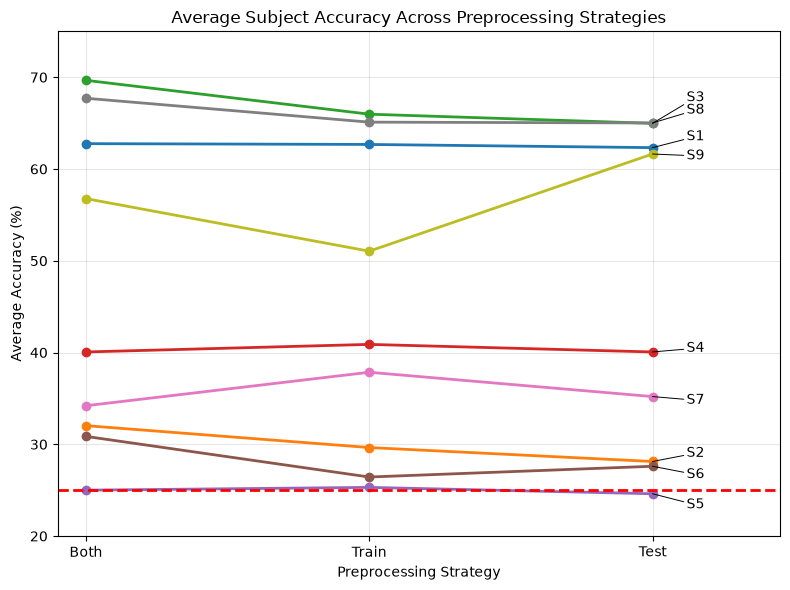

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

conditions = [
    "both_train_test",
    "train_only",
    "test_only"
]

offsets = {
    1: 1.2,
    2: 0.9,
    3: 2.8,
    4: 0.4,
    5: -1.2,
    6: -0.9,
    7: -0.4,
    8: 1.4,
    9: -0.2
}

labels = [
    "Both",
    "Train",
    "Test"
]
plt.figure(figsize=(8,6))

for subject in range(1,10):

    means = []

    for condition in conditions:

        accs = [
            RESULTS[condition][param]["folds"][subject]["acc"]
            for param in RESULTS[condition]
        ]

        means.append(np.mean(accs) * 100)

    plt.plot(
        labels,
        means,
        marker='o',
        linewidth=2,
        label=f"S{subject}"
    )
    
    # Label at final point
    plt.annotate(
        f"S{subject}",
        xy=(2, means[-1]),
        xytext=(2.12, means[-1] + offsets[subject]),
        fontsize=10,
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            lw=0.7,
            shrinkA=0,
            shrinkB=0
        )
    )


# Chance level
plt.axhline(
    25,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Chance (25%)'
)



plt.xticks(range(3), labels)
plt.xlim(-0.1, 2.45)
plt.ylim(20,75)

plt.ylabel("Average Accuracy (%)")
plt.xlabel("Preprocessing Strategy")
plt.title("Average Subject Accuracy Across Preprocessing Strategies")
plt.ylim(20, 75)   # optional, zooms into the useful range
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## durations

In [ ]:
"""Standalone plots for Experiment 3: missing durations (full three-condition results).

All matrices and metrics are embedded directly in this file.
No raw log or previous script is required.
"""

from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "missing_durations_condition_plots"
CLASS_NAMES = ["feet", "Right hand", "Left hand", "Tongue"]
EXPERIMENT_TITLE = "Missing Durations"
CONDITION_NAMES = {'both': 'Both train and test preprocessed',
 'train': 'Train only preprocessed',
 'test': 'Test only preprocessed'}
RESULTS = {'both': {50: {'folds': {1: {'epoch': 46,
                             'matrix': [[0.61805556, 0.09027778, 0.07638889, 0.21527778],
                                        [0.0625, 0.64583333, 0.25, 0.04166667],
                                        [0.04166667, 0.15972222, 0.79861111, 0.0],
                                        [0.42361111, 0.17361111, 0.01388889, 0.38888889]],
                             'acc': 0.6128472222222222,
                             'auc': 0.865523726851852,
                             'fmeasure': 0.6048849850441181},
                         2: {'epoch': 15,
                             'matrix': [[0.08333333, 0.38888889, 0.4375, 0.09027778],
                                        [0.03472222, 0.40972222, 0.51388889, 0.04166667],
                                        [0.0625, 0.26388889, 0.65277778, 0.02083333],
                                        [0.0625, 0.44444444, 0.4375, 0.05555556]],
                             'acc': 0.3003472222222222,
                             'auc': 0.5833654835390947,
                             'fmeasure': 0.24553144641635719},
                         3: {'epoch': None,
                             'matrix': [[0.58333333, 0.11805556, 0.14583333, 0.15277778],
                                        [0.11111111, 0.77083333, 0.02777778, 0.09027778],
                                        [0.09027778, 0.15972222, 0.71527778, 0.03472222],
                                        [0.25, 0.04861111, 0.08333333, 0.61805556]],
                             'acc': 0.671875,
                             'auc': 0.886111914866255,
                             'fmeasure': 0.6714612355073741},
                         4: {'epoch': 17,
                             'matrix': [[0.09027778, 0.32638889, 0.3125, 0.27083333],
                                        [0.02083333, 0.57638889, 0.375, 0.02777778],
                                        [0.02777778, 0.19444444, 0.75694444, 0.02083333],
                                        [0.04861111, 0.29861111, 0.47916667, 0.17361111]],
                             'acc': 0.3993055555555556,
                             'auc': 0.6769949202674898,
                             'fmeasure': 0.3458947675728312},
                         5: {'epoch': 15,
                             'matrix': [[0.0, 1.0, 0.0, 0.0],
                                        [0.0, 1.0, 0.0, 0.0],
                                        [0.0, 0.99305556, 0.0, 0.00694444],
                                        [0.0, 1.0, 0.0, 0.0]],
                             'acc': 0.25,
                             'auc': 0.5158621077674898,
                             'fmeasure': 0.10013908205841446},
                         6: {'epoch': 15,
                             'matrix': [[0.06944444, 0.00694444, 0.07638889, 0.84722222],
                                        [0.08333333, 0.05555556, 0.125, 0.73611111],
                                        [0.15972222, 0.02083333, 0.21527778, 0.60416667],
                                        [0.11111111, 0.04166667, 0.11111111, 0.73611111]],
                             'acc': 0.2690972222222222,
                             'auc': 0.5726755401234568,
                             'fmeasure': 0.21334145711618913},
                         7: {'epoch': 30,
                             'matrix': [[0.53472222, 0.10416667, 0.33333333, 0.02777778],
                                        [0.35416667, 0.22222222, 0.34027778, 0.08333333],
                                        [0.34722222, 0.15277778, 0.45833333, 0.04166667],
                                        [0.33333333, 0.125, 0.23611111, 0.30555556]],
                             'acc': 0.3802083333333333,
                             'auc': 0.6522834683641976,
                             'fmeasure': 0.3748542216284152},
                         8: {'epoch': 23,
                             'matrix': [[0.51388889, 0.0625, 0.25694444, 0.16666667],
                                        [0.21527778, 0.51388889, 0.09722222, 0.17361111],
                                        [0.10416667, 0.00694444, 0.75694444, 0.13194444],
                                        [0.20833333, 0.02083333, 0.15277778, 0.61805556]],
                             'acc': 0.6006944444444444,
                             'auc': 0.8546368634259259,
                             'fmeasure': 0.6010419459811058},
                         9: {'epoch': 17,
                             'matrix': [[0.29861111, 0.11111111, 0.17361111, 0.41666667],
                                        [0.07638889, 0.59027778, 0.29166667, 0.04166667],
                                        [0.19444444, 0.04166667, 0.50694444, 0.25694444],
                                        [0.13888889, 0.0625, 0.09027778, 0.70833333]],
                             'acc': 0.5260416666666666,
                             'auc': 0.7811294367283951,
                             'fmeasure': 0.5198873404984943}},
               'summary': {'acc_mean': 0.4456,
                           'acc_std': 0.1515,
                           'auc_mean': 0.7098,
                           'auc_std': 0.1326,
                           'fmeasure_mean': 0.4086,
                           'fmeasure_std': 0.1891},
               'average_matrix': [[0.31018519, 0.24537037, 0.20138889, 0.24305556],
                                  [0.10648148, 0.5316358, 0.22453704, 0.13734568],
                                  [0.11419753, 0.22145062, 0.54012346, 0.1242284],
                                  [0.17515432, 0.24614198, 0.17824074, 0.40046296]]},
          100: {'folds': {1: {'epoch': 37,
                              'matrix': [[0.29166667, 0.15972222, 0.125, 0.42361111],
                                         [0.00694444, 0.6875, 0.27777778, 0.02777778],
                                         [0.0, 0.0625, 0.9375, 0.0],
                                         [0.15972222, 0.1875, 0.04166667, 0.61111111]],
                              'acc': 0.6319444444444444,
                              'auc': 0.8707360789609053,
                              'fmeasure': 0.6088484358318119},
                          2: {'epoch': 20,
                              'matrix': [[0.22916667, 0.34027778, 0.25694444, 0.17361111],
                                         [0.22222222, 0.49305556, 0.25694444, 0.02777778],
                                         [0.1875, 0.35416667, 0.39583333, 0.0625],
                                         [0.22916667, 0.41666667, 0.29861111, 0.05555556]],
                              'acc': 0.2934027777777778,
                              'auc': 0.571072048611111,
                              'fmeasure': 0.26668022971787325},
                          3: {'epoch': 27,
                              'matrix': [[0.1875, 0.13194444, 0.27083333, 0.40972222],
                                         [0.02777778, 0.70833333, 0.06944444, 0.19444444],
                                         [0.01388889, 0.04166667, 0.88888889, 0.05555556],
                                         [0.03472222, 0.03472222, 0.01388889, 0.91666667]],
                              'acc': 0.6753472222222222,
                              'auc': 0.8959860468106996,
                              'fmeasure': 0.6349984218561466},
                          4: {'epoch': 30,
                              'matrix': [[0.27083333, 0.21527778, 0.19444444, 0.31944444],
                                         [0.20833333, 0.42361111, 0.30555556, 0.0625],
                                         [0.15972222, 0.1875, 0.60416667, 0.04861111],
                                         [0.24305556, 0.11805556, 0.3125, 0.32638889]],
                              'acc': 0.40625,
                              'auc': 0.6955375514403292,
                              'fmeasure': 0.39876966647983814},
                          5: {'epoch': 15,
                              'matrix': [[0.0, 0.47916667, 0.52083333, 0.0],
                                         [0.0, 0.39583333, 0.60416667, 0.0],
                                         [0.0, 0.45833333, 0.54166667, 0.0],
                                         [0.0, 0.4375, 0.5625, 0.0]],
                              'acc': 0.234375,
                              'auc': 0.5312218685699589,
                              'fmeasure': 0.15529953917050693},
                          6: {'epoch': 15,
                              'matrix': [[0.03472222, 0.02083333, 0.18055556, 0.76388889],
                                         [0.03472222, 0.04861111, 0.28472222, 0.63194444],
                                         [0.02777778, 0.02777778, 0.41666667, 0.52777778],
                                         [0.06944444, 0.0625, 0.25, 0.61805556]],
                              'acc': 0.2795138888888889,
                              'auc': 0.5775623713991769,
                              'fmeasure': 0.2208138078809124},
                          7: {'epoch': 15,
                              'matrix': [[0.0, 0.88194444, 0.0625, 0.05555556],
                                         [0.00694444, 0.88194444, 0.08333333, 0.02777778],
                                         [0.0, 0.84722222, 0.10416667, 0.04861111],
                                         [0.0625, 0.625, 0.07638889, 0.23611111]],
                              'acc': 0.3055555555555556,
                              'auc': 0.6039335776748972,
                              'fmeasure': 0.2296597926061988},
                          8: {'epoch': 19,
                              'matrix': [[0.52777778, 0.09722222, 0.21527778, 0.15972222],
                                         [0.14583333, 0.65277778, 0.06944444, 0.13194444],
                                         [0.16666667, 0.03472222, 0.75, 0.04861111],
                                         [0.42361111, 0.01388889, 0.10416667, 0.45833333]],
                              'acc': 0.5972222222222222,
                              'auc': 0.8387345679012347,
                              'fmeasure': 0.6007694013828982},
                          9: {'epoch': 17,
                              'matrix': [[0.29166667, 0.13888889, 0.23611111, 0.33333333],
                                         [0.08333333, 0.46527778, 0.43055556, 0.02083333],
                                         [0.14583333, 0.03472222, 0.61111111, 0.20833333],
                                         [0.22916667, 0.06944444, 0.13194444, 0.56944444]],
                              'acc': 0.484375,
                              'auc': 0.760959201388889,
                              'fmeasure': 0.4798638364590519}},
                'summary': {'acc_mean': 0.4342,
                            'acc_std': 0.1589,
                            'auc_mean': 0.7051,
                            'auc_std': 0.1332,
                            'fmeasure_mean': 0.3995,
                            'fmeasure_std': 0.1777},
                'average_matrix': [[0.2037037, 0.27391975, 0.22916667, 0.29320988],
                                   [0.08179012, 0.52854938, 0.26466049, 0.125],
                                   [0.0779321, 0.22762346, 0.58333333, 0.11111111],
                                   [0.16126543, 0.2183642, 0.19907407, 0.4212963]]},
          150: {'folds': {1: {'epoch': 25,
                              'matrix': [[0.50694444, 0.15277778, 0.0625, 0.27777778],
                                         [0.04166667, 0.6875, 0.26388889, 0.00694444],
                                         [0.02083333, 0.1875, 0.79166667, 0.0],
                                         [0.48611111, 0.1875, 0.00694444, 0.31944444]],
                              'acc': 0.5763888888888888,
                              'auc': 0.845703125,
                              'fmeasure': 0.5643248339749354},
                          2: {'epoch': 16,
                              'matrix': [[0.13194444, 0.38194444, 0.27777778, 0.20833333],
                                         [0.125, 0.63888889, 0.16666667, 0.06944444],
                                         [0.06944444, 0.54166667, 0.33333333, 0.05555556],
                                         [0.08333333, 0.59027778, 0.21527778, 0.11111111]],
                              'acc': 0.3038194444444444,
                              'auc': 0.57397762345679,
                              'fmeasure': 0.27020484730106337},
                          3: {'epoch': None,
                              'matrix': [[0.61111111, 0.07638889, 0.11805556, 0.19444444],
                                         [0.11111111, 0.65972222, 0.02083333, 0.20833333],
                                         [0.07638889, 0.11111111, 0.73611111, 0.07638889],
                                         [0.13194444, 0.02777778, 0.04861111, 0.79166667]],
                              'acc': 0.6996527777777778,
                              'auc': 0.9050845550411525,
                              'fmeasure': 0.6998469738985968},
                          4: {'epoch': 58,
                              'matrix': [[0.4375, 0.07638889, 0.18055556, 0.30555556],
                                         [0.24305556, 0.22916667, 0.45138889, 0.07638889],
                                         [0.13194444, 0.04861111, 0.79166667, 0.02777778],
                                         [0.4375, 0.04166667, 0.27083333, 0.25]],
                              'acc': 0.4270833333333333,
                              'auc': 0.7273863490226337,
                              'fmeasure': 0.4015327984872543},
                          5: {'epoch': 15,
                              'matrix': [[0.0, 1.0, 0.0, 0.0],
                                         [0.0, 1.0, 0.0, 0.0],
                                         [0.0, 1.0, 0.0, 0.0],
                                         [0.0, 1.0, 0.0, 0.0]],
                              'acc': 0.25,
                              'auc': 0.543872974537037,
                              'fmeasure': 0.1},
                          6: {'epoch': 15,
                              'matrix': [[0.15277778, 0.06944444, 0.04861111, 0.72916667],
                                         [0.29861111, 0.10416667, 0.03472222, 0.5625],
                                         [0.1875, 0.21527778, 0.04166667, 0.55555556],
                                         [0.20138889, 0.10416667, 0.04166667, 0.65277778]],
                              'acc': 0.2378472222222222,
                              'auc': 0.5294616448045267,
                              'fmeasure': 0.1875042660036078},
                          7: {'epoch': 18,
                              'matrix': [[0.11111111, 0.38194444, 0.50694444, 0.0],
                                         [0.04861111, 0.56944444, 0.36805556, 0.01388889],
                                         [0.09027778, 0.4375, 0.46527778, 0.00694444],
                                         [0.29166667, 0.30555556, 0.25, 0.15277778]],
                              'acc': 0.3246527777777778,
                              'auc': 0.6170789930555555,
                              'fmeasure': 0.2966072289649475},
                          8: {'epoch': 22,
                              'matrix': [[0.56944444, 0.07638889, 0.15277778, 0.20138889],
                                         [0.24305556, 0.50694444, 0.05555556, 0.19444444],
                                         [0.09027778, 0.01388889, 0.70833333, 0.1875],
                                         [0.20833333, 0.02083333, 0.10416667, 0.66666667]],
                              'acc': 0.6128472222222222,
                              'auc': 0.8445698302469135,
                              'fmeasure': 0.6149266616745641},
                          9: {'epoch': 36,
                              'matrix': [[0.45138889, 0.13194444, 0.15972222, 0.25694444],
                                         [0.07638889, 0.59722222, 0.29861111, 0.02777778],
                                         [0.18055556, 0.05555556, 0.59027778, 0.17361111],
                                         [0.15972222, 0.09027778, 0.0625, 0.6875]],
                              'acc': 0.5815972222222222,
                              'auc': 0.8352342142489712,
                              'fmeasure': 0.5800739094616593}},
                'summary': {'acc_mean': 0.446,
                            'acc_std': 0.1649,
                            'auc_mean': 0.7136,
                            'auc_std': 0.1405,
                            'fmeasure_mean': 0.4128,
                            'fmeasure_std': 0.1991},
                'average_matrix': [[0.33024691, 0.26080247, 0.16743827, 0.24151235],
                                   [0.13194444, 0.55478395, 0.18441358, 0.12885802],
                                   [0.0941358, 0.29012346, 0.49537037, 0.12037037],
                                   [0.22222222, 0.26311728, 0.11111111, 0.40354938]]},
          200: {'folds': {1: {'epoch': 38,
                              'matrix': [[0.46527778, 0.15972222, 0.08333333, 0.29166667],
                                         [0.0, 0.79166667, 0.19444444, 0.01388889],
                                         [0.01388889, 0.1875, 0.79861111, 0.0],
                                         [0.38194444, 0.15972222, 0.01388889, 0.44444444]],
                              'acc': 0.625,
                              'auc': 0.8739631558641975,
                              'fmeasure': 0.6152194653828181},
                          2: {'epoch': 15,
                              'matrix': [[0.0, 0.83333333, 0.15972222, 0.00694444],
                                         [0.0, 0.93055556, 0.06944444, 0.0],
                                         [0.0, 0.76388889, 0.22916667, 0.00694444],
                                         [0.0, 0.84027778, 0.14583333, 0.01388889]],
                              'acc': 0.2934027777777778,
                              'auc': 0.5661530671296297,
                              'fmeasure': 0.18470361117419942},
                          3: {'epoch': 35,
                              'matrix': [[0.35416667, 0.20138889, 0.16666667, 0.27777778],
                                         [0.04166667, 0.84722222, 0.00694444, 0.10416667],
                                         [0.04861111, 0.15277778, 0.75, 0.04861111],
                                         [0.16666667, 0.05555556, 0.02777778, 0.75]],
                              'acc': 0.6753472222222222,
                              'auc': 0.8909304269547325,
                              'fmeasure': 0.6617514415940876},
                          4: {'epoch': 28,
                              'matrix': [[0.20138889, 0.13194444, 0.15277778, 0.51388889],
                                         [0.17361111, 0.36111111, 0.20833333, 0.25694444],
                                         [0.16666667, 0.09722222, 0.5625, 0.17361111],
                                         [0.24305556, 0.06944444, 0.16666667, 0.52083333]],
                              'acc': 0.4114583333333333,
                              'auc': 0.6883479616769548,
                              'fmeasure': 0.4053921421752088},
                          5: {'epoch': 15,
                              'matrix': [[0.0, 0.95833333, 0.04166667, 0.0],
                                         [0.00694444, 0.98611111, 0.00694444, 0.0],
                                         [0.0, 0.98611111, 0.00694444, 0.00694444],
                                         [0.0, 0.9375, 0.0625, 0.0]],
                              'acc': 0.2482638888888889,
                              'auc': 0.544970100308642,
                              'fmeasure': 0.10438947023329583},
                          6: {'epoch': 15,
                              'matrix': [[0.22222222, 0.24305556, 0.0, 0.53472222],
                                         [0.25694444, 0.3125, 0.0, 0.43055556],
                                         [0.29861111, 0.31944444, 0.00694444, 0.375],
                                         [0.20138889, 0.29861111, 0.00694444, 0.49305556]],
                              'acc': 0.2586805555555556,
                              'auc': 0.5280550733024691,
                              'fmeasure': 0.2184597963585673},
                          7: {'epoch': 18,
                              'matrix': [[0.13888889, 0.66666667, 0.17361111, 0.02083333],
                                         [0.08333333, 0.75, 0.13888889, 0.02777778],
                                         [0.10416667, 0.66666667, 0.22222222, 0.00694444],
                                         [0.375, 0.39583333, 0.09722222, 0.13194444]],
                              'acc': 0.3107638888888889,
                              'auc': 0.6188110853909464,
                              'fmeasure': 0.2722414196068711},
                          8: {'epoch': 39,
                              'matrix': [[0.36805556, 0.13888889, 0.34027778, 0.15277778],
                                         [0.15972222, 0.56944444, 0.09722222, 0.17361111],
                                         [0.0625, 0.02083333, 0.83333333, 0.08333333],
                                         [0.09722222, 0.00694444, 0.24305556, 0.65277778]],
                              'acc': 0.6059027777777778,
                              'auc': 0.8466354809670782,
                              'fmeasure': 0.5970485125451364},
                          9: {'epoch': 22,
                              'matrix': [[0.65277778, 0.03472222, 0.18055556, 0.13194444],
                                         [0.11805556, 0.50694444, 0.33333333, 0.04166667],
                                         [0.30555556, 0.02777778, 0.59027778, 0.07638889],
                                         [0.25, 0.02083333, 0.13194444, 0.59722222]],
                              'acc': 0.5868055555555556,
                              'auc': 0.8363192836934158,
                              'fmeasure': 0.5933288667289935}},
                'summary': {'acc_mean': 0.4462,
                            'acc_std': 0.1657,
                            'auc_mean': 0.7105,
                            'auc_std': 0.143,
                            'fmeasure_mean': 0.4058,
                            'fmeasure_std': 0.2038},
                'average_matrix': [[0.26697531, 0.3742284, 0.14429012, 0.21450617],
                                   [0.0933642, 0.67283951, 0.11728395, 0.11651235],
                                   [0.11111111, 0.35802469, 0.44444444, 0.08641975],
                                   [0.19058642, 0.30941358, 0.09953704, 0.40046296]]}},
 'train': {50: {'folds': {1: {'epoch': 55,
                              'matrix': [[0.63888889, 0.25694444, 0.04166667, 0.0625],
                                         [0.02083333, 0.91666667, 0.05555556, 0.00694444],
                                         [0.02083333, 0.3125, 0.66666667, 0.0],
                                         [0.52777778, 0.22222222, 0.00694444, 0.24305556]],
                              'acc': 0.6163194444444444,
                              'auc': 0.8854407793209876,
                              'fmeasure': 0.5947127439913233},
                          2: {'epoch': 15,
                              'matrix': [[0.53472222, 0.33333333, 0.10416667, 0.02777778],
                                         [0.57638889, 0.27083333, 0.125, 0.02777778],
                                         [0.54861111, 0.3125, 0.09722222, 0.04166667],
                                         [0.44444444, 0.41666667, 0.11111111, 0.02777778]],
                              'acc': 0.2326388888888889,
                              'auc': 0.4898465631430042,
                              'fmeasure': 0.1903275723338217},
                          3: {'epoch': 58,
                              'matrix': [[0.47222222, 0.15277778, 0.125, 0.25],
                                         [0.04166667, 0.82638889, 0.0, 0.13194444],
                                         [0.02083333, 0.20138889, 0.5625, 0.21527778],
                                         [0.05555556, 0.01388889, 0.0, 0.93055556]],
                              'acc': 0.6979166666666666,
                              'auc': 0.9368569958847738,
                              'fmeasure': 0.6874953556936311},
                          4: {'epoch': 18,
                              'matrix': [[0.09027778, 0.29861111, 0.27777778, 0.33333333],
                                         [0.07638889, 0.54166667, 0.3125, 0.06944444],
                                         [0.03472222, 0.14583333, 0.76388889, 0.05555556],
                                         [0.07638889, 0.17361111, 0.40972222, 0.34027778]],
                              'acc': 0.4340277777777778,
                              'auc': 0.7165637860082305,
                              'fmeasure': 0.3935135655854358},
                          5: {'epoch': 15,
                              'matrix': [[0.0, 0.97222222, 0.02777778, 0.0],
                                         [0.0, 0.99305556, 0.00694444, 0.0],
                                         [0.0, 0.97916667, 0.02083333, 0.0],
                                         [0.0, 0.98611111, 0.01388889, 0.0]],
                              'acc': 0.2534722222222222,
                              'auc': 0.5109109760802469,
                              'fmeasure': 0.11044448509237242},
                          6: {'epoch': 17,
                              'matrix': [[0.22222222, 0.11805556, 0.02777778, 0.63194444],
                                         [0.36805556, 0.38194444, 0.03472222, 0.21527778],
                                         [0.29166667, 0.27083333, 0.09027778, 0.34722222],
                                         [0.22222222, 0.11111111, 0.02777778, 0.63888889]],
                              'acc': 0.3333333333333333,
                              'auc': 0.6423128858024691,
                              'fmeasure': 0.30526168744506316},
                          7: {'epoch': 37,
                              'matrix': [[0.22222222, 0.33333333, 0.43055556, 0.01388889],
                                         [0.09027778, 0.40972222, 0.40972222, 0.09027778],
                                         [0.11805556, 0.35416667, 0.49305556, 0.03472222],
                                         [0.11111111, 0.31944444, 0.28472222, 0.28472222]],
                              'acc': 0.3524305555555556,
                              'auc': 0.6504669817386831,
                              'fmeasure': 0.35100664324802255},
                          8: {'epoch': 46,
                              'matrix': [[0.54166667, 0.09722222, 0.28472222, 0.07638889],
                                         [0.125, 0.70833333, 0.04166667, 0.125],
                                         [0.04861111, 0.01388889, 0.875, 0.0625],
                                         [0.125, 0.01388889, 0.20138889, 0.65972222]],
                              'acc': 0.6961805555555556,
                              'auc': 0.9035574202674898,
                              'fmeasure': 0.6939126987623964},
                          9: {'epoch': 25,
                              'matrix': [[0.46527778, 0.15277778, 0.15972222, 0.22222222],
                                         [0.0625, 0.61805556, 0.30555556, 0.01388889],
                                         [0.28472222, 0.04861111, 0.61111111, 0.05555556],
                                         [0.30555556, 0.0625, 0.05555556, 0.57638889]],
                              'acc': 0.5677083333333334,
                              'auc': 0.8166875643004116,
                              'fmeasure': 0.5716402761470267}},
                'summary': {'acc_mean': 0.4649,
                            'acc_std': 0.1735,
                            'auc_mean': 0.7281,
                            'auc_std': 0.1579,
                            'fmeasure_mean': 0.4331,
                            'fmeasure_std': 0.2016},
                'average_matrix': [[0.35416667, 0.30169753, 0.16435185, 0.17978395],
                                   [0.15123457, 0.62962963, 0.14351852, 0.07561728],
                                   [0.15200617, 0.29320988, 0.46450617, 0.09027778],
                                   [0.20756173, 0.25771605, 0.12345679, 0.41126543]]},
           100: {'folds': {1: {'epoch': 52,
                               'matrix': [[0.77777778, 0.14583333, 0.02777778, 0.04861111],
                                          [0.04166667, 0.86111111, 0.09722222, 0.0],
                                          [0.03472222, 0.14583333, 0.81944444, 0.0],
                                          [0.64583333, 0.19444444, 0.00694444, 0.15277778]],
                               'acc': 0.6527777777777778,
                               'auc': 0.8831782085905351,
                               'fmeasure': 0.6125357360585671},
                           2: {'epoch': 15,
                               'matrix': [[0.04166667, 0.27083333, 0.60416667, 0.08333333],
                                          [0.05555556, 0.33333333, 0.54861111, 0.0625],
                                          [0.04166667, 0.36805556, 0.53472222, 0.05555556],
                                          [0.0625, 0.29166667, 0.58333333, 0.0625]],
                               'acc': 0.24305555555555555,
                               'auc': 0.5079411008230452,
                               'fmeasure': 0.1974269237349782},
                           3: {'epoch': None,
                               'matrix': [[0.41666667, 0.06944444, 0.09027778, 0.42361111],
                                          [0.01388889, 0.68055556, 0.0, 0.30555556],
                                          [0.04166667, 0.07638889, 0.68055556, 0.20138889],
                                          [0.04166667, 0.00694444, 0.00694444, 0.94444444]],
                               'acc': 0.6805555555555556,
                               'auc': 0.9334691679526749,
                               'fmeasure': 0.6788781972346118},
                           4: {'epoch': 22,
                               'matrix': [[0.08333333, 0.11805556, 0.38888889, 0.40972222],
                                          [0.10416667, 0.10416667, 0.66666667, 0.125],
                                          [0.02083333, 0.02777778, 0.90277778, 0.04861111],
                                          [0.04166667, 0.02777778, 0.54861111, 0.38194444]],
                               'acc': 0.3680555555555556,
                               'auc': 0.7089602623456791,
                               'fmeasure': 0.29998021906200456},
                           5: {'epoch': 15,
                               'matrix': [[0.0, 0.81944444, 0.18055556, 0.0],
                                          [0.0, 0.86805556, 0.13194444, 0.0],
                                          [0.0, 0.86111111, 0.13888889, 0.0],
                                          [0.0, 0.84722222, 0.15277778, 0.0]],
                               'acc': 0.2517361111111111,
                               'auc': 0.5070971579218108,
                               'fmeasure': 0.14202622022527236},
                           6: {'epoch': 16,
                               'matrix': [[0.22916667, 0.06944444, 0.0625, 0.63888889],
                                          [0.36805556, 0.21527778, 0.13194444, 0.28472222],
                                          [0.30555556, 0.17361111, 0.13194444, 0.38888889],
                                          [0.33333333, 0.09027778, 0.0625, 0.51388889]],
                               'acc': 0.2725694444444444,
                               'auc': 0.5905550733024691,
                               'fmeasure': 0.25915805339133474},
                           7: {'epoch': 33,
                               'matrix': [[0.04166667, 0.59027778, 0.29861111, 0.06944444],
                                          [0.00694444, 0.69444444, 0.24305556, 0.05555556],
                                          [0.00694444, 0.61805556, 0.34722222, 0.02777778],
                                          [0.02083333, 0.45833333, 0.11805556, 0.40277778]],
                               'acc': 0.3715277777777778,
                               'auc': 0.6854102366255144,
                               'fmeasure': 0.3386300998593488},
                           8: {'epoch': 33,
                               'matrix': [[0.5, 0.06944444, 0.40972222, 0.02083333],
                                          [0.15972222, 0.68055556, 0.06944444, 0.09027778],
                                          [0.03472222, 0.0, 0.92361111, 0.04166667],
                                          [0.13888889, 0.01388889, 0.32638889, 0.52083333]],
                               'acc': 0.65625,
                               'auc': 0.8876953125,
                               'fmeasure': 0.6540898778701986},
                           9: {'epoch': 22,
                               'matrix': [[0.31944444, 0.09027778, 0.17361111, 0.41666667],
                                          [0.09722222, 0.59027778, 0.28472222, 0.02777778],
                                          [0.20138889, 0.04861111, 0.51388889, 0.23611111],
                                          [0.11805556, 0.02777778, 0.05555556, 0.79861111]],
                               'acc': 0.5555555555555556,
                               'auc': 0.7993706597222222,
                               'fmeasure': 0.5477609442607516}},
                 'summary': {'acc_mean': 0.4502,
                             'acc_std': 0.1746,
                             'auc_mean': 0.7226,
                             'auc_std': 0.1545,
                             'fmeasure_mean': 0.4145,
                             'fmeasure_std': 0.1968},
                 'average_matrix': [[0.26774691, 0.2492284, 0.24845679, 0.2345679],
                                    [0.0941358, 0.55864198, 0.24151235, 0.10570988],
                                    [0.07638889, 0.25771605, 0.55478395, 0.11111111],
                                    [0.1558642, 0.21759259, 0.20679012, 0.41975309]]},
           150: {'folds': {1: {'epoch': 53,
                               'matrix': [[0.66666667, 0.20833333, 0.04861111, 0.07638889],
                                          [0.02083333, 0.875, 0.10416667, 0.0],
                                          [0.02777778, 0.14583333, 0.82638889, 0.0],
                                          [0.56944444, 0.21527778, 0.00694444, 0.20833333]],
                               'acc': 0.6440972222222222,
                               'auc': 0.8739671746399177,
                               'fmeasure': 0.6139969683852662},
                           2: {'epoch': 15,
                               'matrix': [[0.02777778, 0.9375, 0.00694444, 0.02777778],
                                          [0.04861111, 0.90972222, 0.0, 0.04166667],
                                          [0.04166667, 0.94444444, 0.00694444, 0.00694444],
                                          [0.04166667, 0.94444444, 0.0, 0.01388889]],
                               'acc': 0.23958333333333334,
                               'auc': 0.5048185120884774,
                               'fmeasure': 0.11781118790850562},
                           3: {'epoch': 32,
                               'matrix': [[0.54861111, 0.11111111, 0.04861111, 0.29166667],
                                          [0.09722222, 0.70138889, 0.01388889, 0.1875],
                                          [0.10416667, 0.06944444, 0.70833333, 0.11805556],
                                          [0.08333333, 0.01388889, 0.0, 0.90277778]],
                               'acc': 0.7152777777777778,
                               'auc': 0.923265496399177,
                               'fmeasure': 0.7151584526584527},
                           4: {'epoch': 20,
                               'matrix': [[0.04861111, 0.20138889, 0.44444444, 0.30555556],
                                          [0.04166667, 0.32638889, 0.59722222, 0.03472222],
                                          [0.03472222, 0.04166667, 0.91666667, 0.00694444],
                                          [0.01388889, 0.09027778, 0.69444444, 0.20138889]],
                               'acc': 0.3732638888888889,
                               'auc': 0.7033621077674898,
                               'fmeasure': 0.3101655299430365},
                           5: {'epoch': 15,
                               'matrix': [[0.0, 0.84027778, 0.15972222, 0.0],
                                          [0.0, 0.80555556, 0.19444444, 0.0],
                                          [0.0, 0.81944444, 0.17361111, 0.00694444],
                                          [0.0, 0.81944444, 0.18055556, 0.0]],
                               'acc': 0.24479166666666666,
                               'auc': 0.5129967206790123,
                               'fmeasure': 0.14481624962116718},
                           6: {'epoch': 18,
                               'matrix': [[0.375, 0.07638889, 0.02083333, 0.52777778],
                                          [0.47916667, 0.3125, 0.04166667, 0.16666667],
                                          [0.41666667, 0.125, 0.18055556, 0.27777778],
                                          [0.375, 0.09722222, 0.03472222, 0.49305556]],
                               'acc': 0.3402777777777778,
                               'auc': 0.6450255594135802,
                               'fmeasure': 0.3385010742660166},
                           7: {'epoch': 35,
                               'matrix': [[0.10416667, 0.42361111, 0.45833333, 0.01388889],
                                          [0.0625, 0.54166667, 0.32638889, 0.06944444],
                                          [0.06944444, 0.44444444, 0.42361111, 0.0625],
                                          [0.1875, 0.33333333, 0.19444444, 0.28472222]],
                               'acc': 0.3385416666666667,
                               'auc': 0.6386357060185186,
                               'fmeasure': 0.32298439519298555},
                           8: {'epoch': 34,
                               'matrix': [[0.63194444, 0.09722222, 0.21527778, 0.05555556],
                                          [0.22222222, 0.70833333, 0.03472222, 0.03472222],
                                          [0.09722222, 0.00694444, 0.86111111, 0.03472222],
                                          [0.22916667, 0.01388889, 0.15972222, 0.59722222]],
                               'acc': 0.6996527777777778,
                               'auc': 0.897971322016461,
                               'fmeasure': 0.7018103516659859},
                           9: {'epoch': 34,
                               'matrix': [[0.41666667, 0.15972222, 0.09027778, 0.33333333],
                                          [0.0, 0.77083333, 0.20138889, 0.02777778],
                                          [0.19444444, 0.08333333, 0.50694444, 0.21527778],
                                          [0.13888889, 0.07638889, 0.00694444, 0.77777778]],
                               'acc': 0.6180555555555556,
                               'auc': 0.858494888117284,
                               'fmeasure': 0.6090093569050143}},
                 'summary': {'acc_mean': 0.4682,
                             'acc_std': 0.1863,
                             'auc_mean': 0.7287,
                             'auc_std': 0.1552,
                             'fmeasure_mean': 0.4305,
                             'fmeasure_std': 0.2196},
                 'average_matrix': [[0.3132716, 0.33950617, 0.16589506, 0.18132716],
                                    [0.10802469, 0.66126543, 0.16820988, 0.0625],
                                    [0.1095679, 0.29783951, 0.51157407, 0.08101852],
                                    [0.18209877, 0.28935185, 0.14197531, 0.38657407]]},
           200: {'folds': {1: {'epoch': 59,
                               'matrix': [[0.55555556, 0.26388889, 0.04861111, 0.13194444],
                                          [0.01388889, 0.88194444, 0.08333333, 0.02083333],
                                          [0.02777778, 0.21527778, 0.75694444, 0.0],
                                          [0.53472222, 0.25694444, 0.01388889, 0.19444444]],
                               'acc': 0.5972222222222222,
                               'auc': 0.8555571630658437,
                               'fmeasure': 0.5697982308143793},
                           2: {'epoch': 15,
                               'matrix': [[0.00694444, 0.85416667, 0.03472222, 0.10416667],
                                          [0.02777778, 0.8125, 0.02777778, 0.13194444],
                                          [0.01388889, 0.86805556, 0.02083333, 0.09722222],
                                          [0.00694444, 0.88888889, 0.02777778, 0.07638889]],
                               'acc': 0.22916666666666666,
                               'auc': 0.5111119148662551,
                               'fmeasure': 0.13159480443720137},
                           3: {'epoch': 34,
                               'matrix': [[0.52083333, 0.1875, 0.03472222, 0.25694444],
                                          [0.05555556, 0.81944444, 0.00694444, 0.11805556],
                                          [0.08333333, 0.15277778, 0.66666667, 0.09722222],
                                          [0.07638889, 0.01388889, 0.0, 0.90972222]],
                               'acc': 0.7291666666666666,
                               'auc': 0.9319420331790124,
                               'fmeasure': 0.7245824529007872},
                           4: {'epoch': 27,
                               'matrix': [[0.32638889, 0.14583333, 0.18055556, 0.34722222],
                                          [0.375, 0.16666667, 0.4375, 0.02083333],
                                          [0.23611111, 0.02777778, 0.70833333, 0.02777778],
                                          [0.34027778, 0.04861111, 0.29166667, 0.31944444]],
                               'acc': 0.3802083333333333,
                               'auc': 0.6918523341049383,
                               'fmeasure': 0.36004226495915664},
                           5: {'epoch': 15,
                               'matrix': [[0.0, 0.99305556, 0.00694444, 0.0],
                                          [0.0, 1.0, 0.0, 0.0],
                                          [0.0, 0.98611111, 0.01388889, 0.0],
                                          [0.0, 0.99305556, 0.00694444, 0.0]],
                               'acc': 0.2534722222222222,
                               'auc': 0.5268012152777778,
                               'fmeasure': 0.10731541597463386},
                           6: {'epoch': 16,
                               'matrix': [[0.21527778, 0.03472222, 0.22222222, 0.52777778],
                                          [0.34027778, 0.13194444, 0.34722222, 0.18055556],
                                          [0.34722222, 0.09027778, 0.375, 0.1875],
                                          [0.22222222, 0.08333333, 0.25694444, 0.4375]],
                               'acc': 0.2899305555555556,
                               'auc': 0.5922027713477366,
                               'fmeasure': 0.27879989427599006},
                           7: {'epoch': 39,
                               'matrix': [[0.08333333, 0.40972222, 0.46527778, 0.04166667],
                                          [0.01388889, 0.45833333, 0.45833333, 0.06944444],
                                          [0.03472222, 0.40277778, 0.53472222, 0.02777778],
                                          [0.04861111, 0.36805556, 0.1875, 0.39583333]],
                               'acc': 0.3680555555555556,
                               'auc': 0.666895736882716,
                               'fmeasure': 0.3521453676947205},
                           8: {'epoch': 36,
                               'matrix': [[0.45833333, 0.04861111, 0.30555556, 0.1875],
                                          [0.20833333, 0.54166667, 0.09027778, 0.15972222],
                                          [0.04166667, 0.0, 0.85416667, 0.10416667],
                                          [0.07638889, 0.0, 0.13888889, 0.78472222]],
                               'acc': 0.6597222222222222,
                               'auc': 0.9028822659465021,
                               'fmeasure': 0.6529552543933542},
                           9: {'epoch': 26,
                               'matrix': [[0.375, 0.125, 0.19444444, 0.30555556],
                                          [0.00694444, 0.73611111, 0.24305556, 0.01388889],
                                          [0.10416667, 0.07638889, 0.61111111, 0.20833333],
                                          [0.09027778, 0.09027778, 0.05555556, 0.76388889]],
                               'acc': 0.6215277777777778,
                               'auc': 0.8517754951131687,
                               'fmeasure': 0.6123307687114133}},
                 'summary': {'acc_mean': 0.4587,
                             'acc_std': 0.1816,
                             'auc_mean': 0.7257,
                             'auc_std': 0.1545,
                             'fmeasure_mean': 0.4211,
                             'fmeasure_std': 0.2149},
                 'average_matrix': [[0.28240741, 0.34027778, 0.16589506, 0.21141975],
                                    [0.11574074, 0.61651235, 0.1882716, 0.07947531],
                                    [0.09876543, 0.3132716, 0.50462963, 0.08333333],
                                    [0.15509259, 0.30478395, 0.1087963, 0.43132716]]}},
 'test': {50: {'folds': {1: {'epoch': 20,
                             'matrix': [[0.76388889, 0.04861111, 0.04166667, 0.14583333],
                                        [0.14583333, 0.54861111, 0.27777778, 0.02777778],
                                        [0.09027778, 0.125, 0.78472222, 0.0],
                                        [0.71527778, 0.05555556, 0.0, 0.22916667]],
                             'acc': 0.5815972222222222,
                             'auc': 0.8509275334362139,
                             'fmeasure': 0.5631136518183467},
                         2: {'epoch': 17,
                             'matrix': [[0.15277778, 0.36805556, 0.24305556, 0.23611111],
                                        [0.10416667, 0.38194444, 0.36111111, 0.15277778],
                                        [0.08333333, 0.28472222, 0.52777778, 0.10416667],
                                        [0.09027778, 0.40972222, 0.29166667, 0.20833333]],
                             'acc': 0.3177083333333333,
                             'auc': 0.5812395511831275,
                             'fmeasure': 0.3016300695383169},
                         3: {'epoch': 40,
                             'matrix': [[0.54166667, 0.10416667, 0.08333333, 0.27083333],
                                        [0.13888889, 0.70138889, 0.0, 0.15972222],
                                        [0.14583333, 0.15277778, 0.49305556, 0.20833333],
                                        [0.15277778, 0.01388889, 0.00694444, 0.82638889]],
                             'acc': 0.640625,
                             'auc': 0.900535300925926,
                             'fmeasure': 0.6379663948603904},
                         4: {'epoch': 18,
                             'matrix': [[0.23611111, 0.22222222, 0.11805556, 0.42361111],
                                        [0.125, 0.375, 0.20138889, 0.29861111],
                                        [0.125, 0.17361111, 0.47222222, 0.22916667],
                                        [0.15972222, 0.23611111, 0.18055556, 0.42361111]],
                             'acc': 0.3767361111111111,
                             'auc': 0.6438802083333334,
                             'fmeasure': 0.3740551597511019},
                         5: {'epoch': 15,
                             'matrix': [[0.0, 0.76388889, 0.23611111, 0.0],
                                        [0.0, 0.85416667, 0.14583333, 0.0],
                                        [0.0, 0.77083333, 0.22916667, 0.0],
                                        [0.0, 0.71527778, 0.28472222, 0.0]],
                             'acc': 0.2708333333333333,
                             'auc': 0.5360886059670782,
                             'fmeasure': 0.1645004741451442},
                         6: {'epoch': 15,
                             'matrix': [[0.14583333, 0.03472222, 0.3125, 0.50694444],
                                        [0.27777778, 0.02777778, 0.24305556, 0.45138889],
                                        [0.11805556, 0.02777778, 0.54861111, 0.30555556],
                                        [0.09027778, 0.04861111, 0.27083333, 0.59027778]],
                             'acc': 0.328125,
                             'auc': 0.5957151813271605,
                             'fmeasure': 0.2757793750725044},
                         7: {'epoch': 25,
                             'matrix': [[0.13888889, 0.28472222, 0.51388889, 0.0625],
                                        [0.04861111, 0.34027778, 0.54166667, 0.06944444],
                                        [0.06944444, 0.25694444, 0.63888889, 0.03472222],
                                        [0.11805556, 0.19444444, 0.29861111, 0.38888889]],
                             'acc': 0.3767361111111111,
                             'auc': 0.6693954153806584,
                             'fmeasure': 0.36417338811921685},
                         8: {'epoch': 30,
                             'matrix': [[0.51388889, 0.08333333, 0.30555556, 0.09722222],
                                        [0.15277778, 0.5625, 0.13194444, 0.15277778],
                                        [0.0625, 0.01388889, 0.84722222, 0.07638889],
                                        [0.10416667, 0.05555556, 0.19444444, 0.64583333]],
                             'acc': 0.6423611111111112,
                             'auc': 0.8599135159465021,
                             'fmeasure': 0.6387198681926802},
                         9: {'epoch': 18,
                             'matrix': [[0.28472222, 0.15277778, 0.17361111, 0.38888889],
                                        [0.04166667, 0.68055556, 0.24305556, 0.03472222],
                                        [0.16666667, 0.0625, 0.54861111, 0.22222222],
                                        [0.15972222, 0.08333333, 0.09027778, 0.66666667]],
                             'acc': 0.5451388888888888,
                             'auc': 0.7911040380658436,
                             'fmeasure': 0.5356543684330062}},
               'summary': {'acc_mean': 0.4533,
                           'acc_std': 0.1394,
                           'auc_mean': 0.7143,
                           'auc_std': 0.1295,
                           'fmeasure_mean': 0.4284,
                           'fmeasure_std': 0.1612},
               'average_matrix': [[0.30864198, 0.22916667, 0.22530864, 0.23688272],
                                  [0.11496914, 0.49691358, 0.23842593, 0.14969136],
                                  [0.09567901, 0.20756173, 0.56558642, 0.13117284],
                                  [0.17669753, 0.20138889, 0.17978395, 0.44212963]]},
          100: {'folds': {1: {'epoch': 34,
                              'matrix': [[0.36805556, 0.11805556, 0.13194444, 0.38194444],
                                         [0.10416667, 0.54861111, 0.28472222, 0.0625],
                                         [0.01388889, 0.11111111, 0.875, 0.0],
                                         [0.3125, 0.125, 0.00694444, 0.55555556]],
                              'acc': 0.5868055555555556,
                              'auc': 0.8468404385288065,
                              'fmeasure': 0.5756984014310849},
                          2: {'epoch': 15,
                              'matrix': [[0.00694444, 0.53472222, 0.4375, 0.02083333],
                                         [0.0, 0.76388889, 0.23611111, 0.0],
                                         [0.0, 0.625, 0.36805556, 0.00694444],
                                         [0.0, 0.65277778, 0.34722222, 0.0]],
                              'acc': 0.2847222222222222,
                              'auc': 0.5585173932613168,
                              'fmeasure': 0.18727927608785355},
                          3: {'epoch': 46,
                              'matrix': [[0.29166667, 0.25694444, 0.25, 0.20138889],
                                         [0.02083333, 0.77777778, 0.04166667, 0.15972222],
                                         [0.04166667, 0.10416667, 0.77777778, 0.07638889],
                                         [0.08333333, 0.06944444, 0.0625, 0.78472222]],
                              'acc': 0.6579861111111112,
                              'auc': 0.8750522440843621,
                              'fmeasure': 0.6365228277459052},
                          4: {'epoch': 20,
                              'matrix': [[0.56944444, 0.1875, 0.11805556, 0.125],
                                         [0.47222222, 0.36111111, 0.15277778, 0.01388889],
                                         [0.52083333, 0.13194444, 0.34722222, 0.0],
                                         [0.55555556, 0.09027778, 0.20138889, 0.15277778]],
                              'acc': 0.3576388888888889,
                              'auc': 0.6724014596193415,
                              'fmeasure': 0.3478344477686072},
                          5: {'epoch': 15,
                              'matrix': [[0.0, 0.31944444, 0.68055556, 0.0],
                                         [0.00694444, 0.25694444, 0.73611111, 0.0],
                                         [0.0, 0.30555556, 0.6875, 0.00694444],
                                         [0.0, 0.19444444, 0.80555556, 0.0]],
                              'acc': 0.2361111111111111,
                              'auc': 0.5264234503600823,
                              'fmeasure': 0.1497947569458883},
                          6: {'epoch': 15,
                              'matrix': [[0.09027778, 0.04861111, 0.40277778, 0.45833333],
                                         [0.1875, 0.16666667, 0.34027778, 0.30555556],
                                         [0.09027778, 0.05555556, 0.54861111, 0.30555556],
                                         [0.125, 0.11111111, 0.36805556, 0.39583333]],
                              'acc': 0.3003472222222222,
                              'auc': 0.5809743119855967,
                              'fmeasure': 0.2739489150869979},
                          7: {'epoch': 16,
                              'matrix': [[0.08333333, 0.5, 0.39583333, 0.02083333],
                                         [0.05555556, 0.52083333, 0.40972222, 0.01388889],
                                         [0.04861111, 0.43055556, 0.51388889, 0.00694444],
                                         [0.16666667, 0.40277778, 0.27083333, 0.15972222]],
                              'acc': 0.3194444444444444,
                              'auc': 0.6237501607510288,
                              'fmeasure': 0.28767980557670997},
                          8: {'epoch': 25,
                              'matrix': [[0.61111111, 0.05555556, 0.13194444, 0.20138889],
                                         [0.33333333, 0.45138889, 0.04861111, 0.16666667],
                                         [0.15972222, 0.02083333, 0.68055556, 0.13888889],
                                         [0.22222222, 0.0, 0.09722222, 0.68055556]],
                              'acc': 0.6059027777777778,
                              'auc': 0.8457433127572017,
                              'fmeasure': 0.6083849771131448},
                          9: {'epoch': 24,
                              'matrix': [[0.45833333, 0.04861111, 0.1875, 0.30555556],
                                         [0.11805556, 0.52777778, 0.32638889, 0.02777778],
                                         [0.27083333, 0.01388889, 0.58333333, 0.13194444],
                                         [0.36805556, 0.02083333, 0.02777778, 0.58333333]],
                              'acc': 0.5381944444444444,
                              'auc': 0.7977832433127574,
                              'fmeasure': 0.5468691626270613}},
                'summary': {'acc_mean': 0.4319,
                            'acc_std': 0.1535,
                            'auc_mean': 0.7031,
                            'auc_std': 0.1307,
                            'fmeasure_mean': 0.4016,
                            'fmeasure_std': 0.1798},
                'average_matrix': [[0.27546296, 0.22993827, 0.30401235, 0.19058642],
                                   [0.14429012, 0.48611111, 0.28626543, 0.08333333],
                                   [0.12731481, 0.19984568, 0.59799383, 0.07484568],
                                   [0.2037037, 0.18518519, 0.24305556, 0.36805556]]},
          150: {'folds': {1: {'epoch': 35,
                              'matrix': [[0.28472222, 0.22222222, 0.09027778, 0.40277778],
                                         [0.00694444, 0.875, 0.07638889, 0.04166667],
                                         [0.0, 0.52083333, 0.47916667, 0.0],
                                         [0.15972222, 0.20833333, 0.02777778, 0.60416667]],
                              'acc': 0.5607638888888888,
                              'auc': 0.8653549382716051,
                              'fmeasure': 0.543488433282667},
                          2: {'epoch': 16,
                              'matrix': [[0.06944444, 0.06944444, 0.65972222, 0.20138889],
                                         [0.06944444, 0.07638889, 0.79166667, 0.0625],
                                         [0.04861111, 0.04166667, 0.89583333, 0.01388889],
                                         [0.07638889, 0.08333333, 0.76388889, 0.07638889]],
                              'acc': 0.2795138888888889,
                              'auc': 0.5671215920781894,
                              'fmeasure': 0.19468500318910156},
                          3: {'epoch': 43,
                              'matrix': [[0.625, 0.09027778, 0.09027778, 0.19444444],
                                         [0.125, 0.70138889, 0.01388889, 0.15972222],
                                         [0.14583333, 0.13194444, 0.61805556, 0.10416667],
                                         [0.28472222, 0.0, 0.04166667, 0.67361111]],
                              'acc': 0.6545138888888888,
                              'auc': 0.884472254372428,
                              'fmeasure': 0.6587998776446669},
                          4: {'epoch': 19,
                              'matrix': [[0.30555556, 0.15277778, 0.13888889, 0.40277778],
                                         [0.22916667, 0.34027778, 0.23611111, 0.19444444],
                                         [0.20138889, 0.13888889, 0.50694444, 0.15277778],
                                         [0.26388889, 0.09722222, 0.1875, 0.45138889]],
                              'acc': 0.4010416666666667,
                              'auc': 0.6978744695216049,
                              'fmeasure': 0.39978934396858146},
                          5: {'epoch': 15,
                              'matrix': [[0.0, 1.0, 0.0, 0.0],
                                         [0.0, 0.99305556, 0.00694444, 0.0],
                                         [0.0, 0.99305556, 0.00694444, 0.0],
                                         [0.0, 1.0, 0.0, 0.0]],
                              'acc': 0.25,
                              'auc': 0.5277456275720164,
                              'fmeasure': 0.10300683023619643},
                          6: {'epoch': 17,
                              'matrix': [[0.34722222, 0.20833333, 0.08333333, 0.36111111],
                                         [0.29166667, 0.41666667, 0.09027778, 0.20138889],
                                         [0.30555556, 0.15972222, 0.27083333, 0.26388889],
                                         [0.33333333, 0.18055556, 0.09722222, 0.38888889]],
                              'acc': 0.3559027777777778,
                              'auc': 0.6356618119855968,
                              'fmeasure': 0.35783871184161536},
                          7: {'epoch': 24,
                              'matrix': [[0.16666667, 0.45833333, 0.33333333, 0.04166667],
                                         [0.0625, 0.51388889, 0.38194444, 0.04166667],
                                         [0.03472222, 0.47222222, 0.43055556, 0.0625],
                                         [0.04166667, 0.4375, 0.19444444, 0.32638889]],
                              'acc': 0.359375,
                              'auc': 0.6352840470679012,
                              'fmeasure': 0.3558236009076385},
                          8: {'epoch': 28,
                              'matrix': [[0.5, 0.26388889, 0.13194444, 0.10416667],
                                         [0.09027778, 0.79861111, 0.02083333, 0.09027778],
                                         [0.08333333, 0.11805556, 0.69444444, 0.10416667],
                                         [0.17361111, 0.09027778, 0.125, 0.61111111]],
                              'acc': 0.6510416666666666,
                              'auc': 0.863646958590535,
                              'fmeasure': 0.6472356624861029},
                          9: {'epoch': 21,
                              'matrix': [[0.25694444, 0.11805556, 0.22916667, 0.39583333],
                                         [0.0, 0.59722222, 0.33333333, 0.06944444],
                                         [0.07638889, 0.05555556, 0.65277778, 0.21527778],
                                         [0.08333333, 0.02777778, 0.10416667, 0.78472222]],
                              'acc': 0.5729166666666666,
                              'auc': 0.8311993634259259,
                              'fmeasure': 0.5565829329846863}},
                'summary': {'acc_mean': 0.4539,
                            'acc_std': 0.1483,
                            'auc_mean': 0.7232,
                            'auc_std': 0.1317,
                            'fmeasure_mean': 0.4241,
                            'fmeasure_std': 0.1832},
                'average_matrix': [[0.28395062, 0.28703704, 0.19521605, 0.2337963],
                                   [0.09722222, 0.59027778, 0.21682099, 0.09567901],
                                   [0.09953704, 0.29243827, 0.50617284, 0.10185185],
                                   [0.15740741, 0.23611111, 0.1712963, 0.43518519]]},
          200: {'folds': {1: {'epoch': 25,
                              'matrix': [[0.40972222, 0.14583333, 0.08333333, 0.36111111],
                                         [0.04861111, 0.70138889, 0.22222222, 0.02777778],
                                         [0.02083333, 0.13194444, 0.83333333, 0.01388889],
                                         [0.34027778, 0.125, 0.02083333, 0.51388889]],
                              'acc': 0.6145833333333334,
                              'auc': 0.8590414416152264,
                              'fmeasure': 0.6062461025445648},
                          2: {'epoch': 15,
                              'matrix': [[0.01388889, 0.01388889, 0.92361111, 0.04861111],
                                         [0.0, 0.02083333, 0.95833333, 0.02083333],
                                         [0.00694444, 0.03472222, 0.92361111, 0.03472222],
                                         [0.0, 0.00694444, 0.9375, 0.05555556]],
                              'acc': 0.2534722222222222,
                              'auc': 0.5393116640946503,
                              'fmeasure': 0.13779680433364855},
                          3: {'epoch': 40,
                              'matrix': [[0.38194444, 0.13194444, 0.34722222, 0.13888889],
                                         [0.10416667, 0.72222222, 0.10416667, 0.06944444],
                                         [0.05555556, 0.04166667, 0.82638889, 0.07638889],
                                         [0.25, 0.04166667, 0.06944444, 0.63888889]],
                              'acc': 0.6423611111111112,
                              'auc': 0.8708767361111112,
                              'fmeasure': 0.6350695605102723},
                          4: {'epoch': 18,
                              'matrix': [[0.07638889, 0.375, 0.15277778, 0.39583333],
                                         [0.05555556, 0.72222222, 0.09027778, 0.13194444],
                                         [0.0625, 0.40972222, 0.375, 0.15277778],
                                         [0.0625, 0.25694444, 0.13888889, 0.54166667]],
                              'acc': 0.4288194444444444,
                              'auc': 0.6793499228395062,
                              'fmeasure': 0.38963437425208286},
                          5: {'epoch': 15,
                              'matrix': [[0.0, 0.09027778, 0.90972222, 0.0],
                                         [0.0, 0.06944444, 0.93055556, 0.0],
                                         [0.0, 0.09027778, 0.90972222, 0.0],
                                         [0.0, 0.07638889, 0.92361111, 0.0]],
                              'acc': 0.24479166666666666,
                              'auc': 0.5425106095679012,
                              'fmeasure': 0.12350341908933198},
                          6: {'epoch': 15,
                              'matrix': [[0.21527778, 0.06944444, 0.02777778, 0.6875],
                                         [0.29166667, 0.15972222, 0.02083333, 0.52777778],
                                         [0.41666667, 0.11111111, 0.05555556, 0.41666667],
                                         [0.34027778, 0.11111111, 0.03472222, 0.51388889]],
                              'acc': 0.2361111111111111,
                              'auc': 0.5373826517489712,
                              'fmeasure': 0.20863788381161424},
                          7: {'epoch': 23,
                              'matrix': [[0.13888889, 0.63194444, 0.11111111, 0.11805556],
                                         [0.0625, 0.73611111, 0.04166667, 0.15972222],
                                         [0.11111111, 0.60416667, 0.18055556, 0.10416667],
                                         [0.125, 0.35416667, 0.09027778, 0.43055556]],
                              'acc': 0.3715277777777778,
                              'auc': 0.6118505658436214,
                              'fmeasure': 0.34114494087884856},
                          8: {'epoch': 32,
                              'matrix': [[0.48611111, 0.11111111, 0.1875, 0.21527778],
                                         [0.11805556, 0.63888889, 0.04861111, 0.19444444],
                                         [0.11111111, 0.04166667, 0.70138889, 0.14583333],
                                         [0.15277778, 0.06944444, 0.24305556, 0.53472222]],
                              'acc': 0.5902777777777778,
                              'auc': 0.8216105645576132,
                              'fmeasure': 0.590488317430238},
                          9: {'epoch': 28,
                              'matrix': [[0.55555556, 0.04166667, 0.15277778, 0.25],
                                         [0.14583333, 0.61111111, 0.1875, 0.05555556],
                                         [0.25694444, 0.01388889, 0.61111111, 0.11805556],
                                         [0.18055556, 0.01388889, 0.10416667, 0.70138889]],
                              'acc': 0.6197916666666666,
                              'auc': 0.8648043659979424,
                              'fmeasure': 0.6253696400755224}},
                'summary': {'acc_mean': 0.4446,
                            'acc_std': 0.1651,
                            'auc_mean': 0.703,
                            'auc_std': 0.1421,
                            'fmeasure_mean': 0.4064,
                            'fmeasure_std': 0.2027},
                'average_matrix': [[0.25308642, 0.17901235, 0.32175926, 0.24614198],
                                   [0.09182099, 0.48688272, 0.28935185, 0.13194444],
                                   [0.11574074, 0.16435185, 0.60185185, 0.11805556],
                                   [0.16126543, 0.11728395, 0.28472222, 0.4367284]]}}}


def validate_results() -> None:
    expected_durations = {50, 100, 150, 200}
    subject_matrix_count = 0
    average_matrix_count = 0

    for condition, condition_data in RESULTS.items():
        durations = set(condition_data)
        if durations != expected_durations:
            raise ValueError(
                f"{condition} durations {sorted(durations)} do not match "
                f"{sorted(expected_durations)}"
            )

        for duration, duration_data in condition_data.items():
            folds = duration_data["folds"]
            if set(folds) != set(range(1, 10)):
                raise ValueError(
                    f"{condition}, duration {duration} has folds {sorted(folds)}"
                )

            for fold, fold_data in folds.items():
                matrix = np.asarray(fold_data["matrix"], dtype=float)
                if matrix.shape != (4, 4):
                    raise ValueError(
                        f"{condition}, duration {duration}, fold {fold} "
                        f"has shape {matrix.shape}"
                    )
                subject_matrix_count += 1

            average = np.asarray(duration_data["average_matrix"], dtype=float)
            if average.shape != (4, 4):
                raise ValueError(
                    f"{condition}, duration {duration} average has shape {average.shape}"
                )
            average_matrix_count += 1

    print(
        f"Validated {subject_matrix_count} subject matrices and "
        f"{average_matrix_count} average matrices."
    )


def annotate_matrix(ax: plt.Axes, matrix: np.ndarray, digits: int = 2) -> None:
    threshold = float(np.nanmin(matrix) + np.nanmax(matrix)) / 2.0
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix[row, column]
            ax.text(
                column,
                row,
                f"{value:.{digits}f}",
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=8,
            )


def draw_matrix(ax: plt.Axes, matrix_data, title: str):
    matrix = np.asarray(matrix_data, dtype=float)
    image = ax.imshow(matrix, vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ticks = np.arange(len(CLASS_NAMES))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    annotate_matrix(ax, matrix)
    return image


def metric_title(duration: int, fold_data: dict) -> str:
    epoch = "N/A" if fold_data["epoch"] is None else str(fold_data["epoch"])
    return (
        f"Duration {duration}\n"
        f"Acc={fold_data['acc']:.3f}, AUC={fold_data['auc']:.3f}\n"
        f"F1={fold_data['fmeasure']:.3f}, Epoch={epoch}"
    )


def plot_subject_matrices() -> None:
    subject_dir = OUTPUT_DIR / "subjects"
    subject_dir.mkdir(parents=True, exist_ok=True)

    conditions = list(RESULTS)
    durations = sorted(next(iter(RESULTS.values())))
    subjects = range(1, 10)

    for subject in subjects:
        fig, axes = plt.subplots(
            len(conditions),
            len(durations),
            figsize=(5 * len(durations), 5 * len(conditions)),
            constrained_layout=True,
            squeeze=False,
        )
        image = None

        for row, condition in enumerate(conditions):
            for column, duration in enumerate(durations):
                fold_data = RESULTS[condition][duration]["folds"][subject]
                image = draw_matrix(
                    axes[row, column],
                    fold_data["matrix"],
                    metric_title(duration, fold_data),
                )

            axes[row, 0].text(
                -0.55,
                0.5,
                CONDITION_NAMES[condition],
                transform=axes[row, 0].transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=11,
                fontweight="bold",
            )

        fig.suptitle(
            f"Subject {subject}: {EXPERIMENT_TITLE} Across Durations",
            fontsize=17,
        )
        if image is not None:
            fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="Proportion")

        fig.savefig(
            subject_dir / f"subject_{subject}_missing_durations.png",
            dpi=250,
            bbox_inches="tight",
        )
        plt.close(fig)


def plot_average_matrices() -> None:
    conditions = list(RESULTS)
    durations = sorted(next(iter(RESULTS.values())))

    fig, axes = plt.subplots(
        len(conditions),
        len(durations),
        figsize=(5 * len(durations), 5 * len(conditions)),
        constrained_layout=True,
        squeeze=False,
    )
    image = None

    for row, condition in enumerate(conditions):
        for column, duration in enumerate(durations):
            image = draw_matrix(
                axes[row, column],
                RESULTS[condition][duration]["average_matrix"],
                f"Duration {duration}",
            )
        axes[row, 0].text(
            -0.55,
            0.5,
            CONDITION_NAMES[condition],
            transform=axes[row, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

    fig.suptitle(
        "Average Confusion Matrices: Missing Durations",
        fontsize=17,
    )
    if image is not None:
        fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="Proportion")
    fig.savefig(
        OUTPUT_DIR / "average_matrices_missing_durations.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.close(fig)


def plot_mean_metric(metric: str, ylabel: str, filename: str) -> None:
    durations = sorted(next(iter(RESULTS.values())))
    fig, ax = plt.subplots(figsize=(10, 6))

    for condition, condition_data in RESULTS.items():
        means = [condition_data[d]["summary"][f"{metric}_mean"] for d in durations]
        stds = [condition_data[d]["summary"][f"{metric}_std"] for d in durations]
        ax.errorbar(
            durations,
            means,
            yerr=stds,
            marker="o",
            capsize=5,
            linewidth=2,
            label=CONDITION_NAMES[condition],
        )
        for duration, value in zip(durations, means):
            ax.annotate(
                f"{value:.4f}",
                (duration, value),
                xytext=(0, 9),
                textcoords="offset points",
                ha="center",
                fontsize=8,
            )

    ax.set_title(f"{ylabel} by Missing Duration Condition")
    ax.set_xlabel("Duration")
    ax.set_ylabel(ylabel)
    ax.set_xticks(durations)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=250, bbox_inches="tight")
    plt.close(fig)


def plot_subject_accuracy_comparisons() -> None:
    comparison_dir = OUTPUT_DIR / "subject_accuracy_comparisons"
    comparison_dir.mkdir(parents=True, exist_ok=True)
    durations = sorted(next(iter(RESULTS.values())))

    for subject in range(1, 10):
        fig, ax = plt.subplots(figsize=(9, 6))
        for condition, condition_data in RESULTS.items():
            values = [condition_data[d]["folds"][subject]["acc"] for d in durations]
            ax.plot(
                durations,
                values,
                marker="o",
                linewidth=2,
                label=CONDITION_NAMES[condition],
            )

        ax.set_title(f"Subject {subject}: Accuracy Across Durations")
        ax.set_xlabel("Duration")
        ax.set_ylabel("Validation accuracy")
        ax.set_xticks(durations)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(
            comparison_dir / f"subject_{subject}_accuracy_missing_durations.png",
            dpi=250,
            bbox_inches="tight",
        )
        plt.close(fig)


def write_csv_files() -> None:
    summary_path = OUTPUT_DIR / "summary_metrics_missing_durations.csv"
    with summary_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "condition",
            "duration",
            "acc_mean",
            "acc_std",
            "auc_mean",
            "auc_std",
            "fmeasure_mean",
            "fmeasure_std",
        ])
        for condition, condition_data in RESULTS.items():
            for duration, duration_data in condition_data.items():
                summary = duration_data["summary"]
                writer.writerow([
                    condition,
                    duration,
                    summary["acc_mean"],
                    summary["acc_std"],
                    summary["auc_mean"],
                    summary["auc_std"],
                    summary["fmeasure_mean"],
                    summary["fmeasure_std"],
                ])

    subject_path = OUTPUT_DIR / "subject_metrics_missing_durations.csv"
    with subject_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "condition",
            "duration",
            "subject",
            "epoch",
            "accuracy",
            "auc",
            "fmeasure",
        ])
        for condition, condition_data in RESULTS.items():
            for duration, duration_data in condition_data.items():
                for subject, fold_data in duration_data["folds"].items():
                    writer.writerow([
                        condition,
                        duration,
                        subject,
                        fold_data["epoch"],
                        fold_data["acc"],
                        fold_data["auc"],
                        fold_data["fmeasure"],
                    ])


def main() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    validate_results()
    plot_subject_matrices()
    plot_average_matrices()
    plot_mean_metric("acc", "Mean validation accuracy", "mean_accuracy_missing_durations.png")
    plot_mean_metric("auc", "Mean AUC", "mean_auc_missing_durations.png")
    plot_mean_metric("fmeasure", "Mean F1 score", "mean_fmeasure_missing_durations.png")
    plot_subject_accuracy_comparisons()
    write_csv_files()
    print(f"Plots and CSV files saved in: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()


Validated 108 subject matrices and 12 average matrices.
Plots and CSV files saved in: /home/hia2037/EEGMotorImagery-Classification/Code/missing_durations_condition_plots


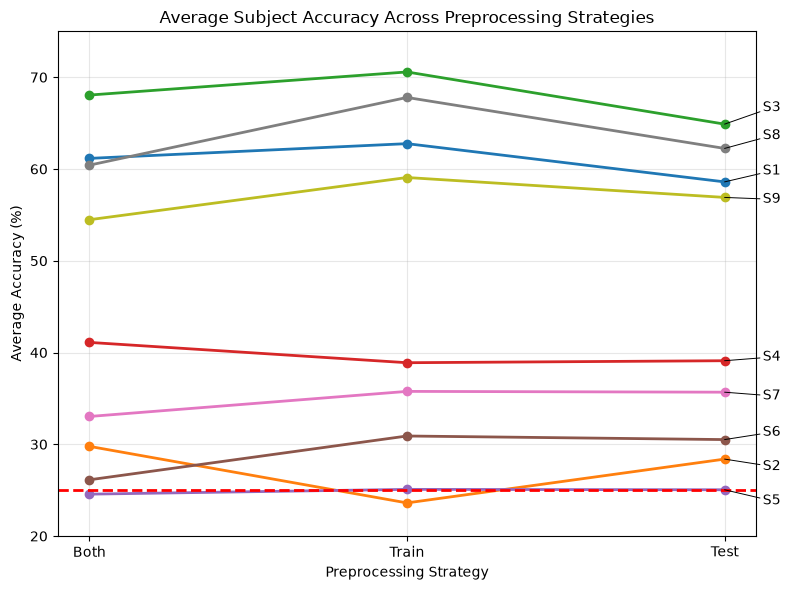

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

conditions = [
    "both",
    "train",
    "test"
]
offsets = {
    1: 1.2,
    2: -0.8,
    3: 1.8,
    4: 0.4,
    5: -1.2,
    6: 0.8,
    7: -0.4,
    8: 1.4,
    9: -0.2
}

labels = [
    "Both",
    "Train",
    "Test"
]
plt.figure(figsize=(8,6))

for subject in range(1,10):

    means = []

    for condition in conditions:

        accs = [
            RESULTS[condition][param]["folds"][subject]["acc"]
            for param in RESULTS[condition]
        ]

        means.append(np.mean(accs) * 100)

    plt.plot(
        labels,
        means,
        marker='o',
        linewidth=2,
        label=f"S{subject}"
    )
    
    # Label at final point
    plt.annotate(
        f"S{subject}",
        xy=(2, means[-1]),
        xytext=(2.12, means[-1] + offsets[subject]),
        fontsize=10,
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            lw=0.7,
            shrinkA=0,
            shrinkB=0
        )
    )


# Chance level
plt.axhline(
    25,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Chance (25%)'
)



plt.xticks(range(3), labels)
plt.xlim(-0.1, 2.45)
plt.ylim(20,75)


plt.ylabel("Average Accuracy (%)")
plt.xlabel("Preprocessing Strategy")
plt.title("Average Subject Accuracy Across Preprocessing Strategies")
plt.ylim(20, 75)   # optional, zooms into the useful range
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## freq

In [40]:
"""Frequency-averaged removed-frequencies experiment.

All three tested center frequencies are averaged within each bandwidth before
plotting or reporting results. No external log files are required.
"""

from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path.cwd() / "removed_frequencies_bandwidth_averages"
CLASS_NAMES = ["feet", "Right hand", "Left hand", "Tongue"]
CONDITION_LABELS = {
    "both": "Both train and test preprocessed",
    "train": "Train only preprocessed",
    "test": "Test only preprocessed",
}

RESULTS = {'both': {4: {'average_matrix': [[0.26466049333333336, 0.27263374444444444, 0.23379629592592593, 0.22890946518518518],
                                 [0.08281892962962963, 0.5992798351851852, 0.22788065740740737, 0.09002057518518519],
                                 [0.08744855925925926, 0.2554012337037037, 0.5645576129629629, 0.09259259333333335],
                                 [0.13760288037037036, 0.2448559677777778, 0.17463991666666667, 0.44290123481481486]],
              'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
              'subjects': {1: {'acc': 0.6498842592592592,
                               'auc': 0.8916457690329218,
                               'fmeasure': 0.638058725126069,
                               'matrix': [[0.5902777766666667, 0.18287036999999998, 0.04861110999999999, 0.17824074],
                                          [0.020833333333333332,
                                           0.7962962966666667,
                                           0.17592592333333332,
                                           0.006944443333333332],
                                          [0.032407406666666666, 0.14583333333333334, 0.82175926, 0.0],
                                          [0.4143518533333333, 0.1875, 0.00694444, 0.3912037033333333]]},
                           2: {'acc': 0.2702546296296296,
                               'auc': 0.5313437714334706,
                               'fmeasure': 0.22294755980529538,
                               'matrix': [[0.15509259333333333,
                                           0.45138888666666666,
                                           0.2615740733333333,
                                           0.1319444466666667],
                                          [0.11574074000000001,
                                           0.5324074066666667,
                                           0.2569444433333334,
                                           0.09490740666666665],
                                          [0.12037037, 0.4837962966666667, 0.29398148333333335, 0.10185185000000001],
                                          [0.12499999666666665, 0.5532407433333333, 0.22222222, 0.09953703666666668]]},
                           3: {'acc': 0.6979166666666666,
                               'auc': 0.9293526020233197,
                               'fmeasure': 0.6910997498373357,
                               'matrix': [[0.4699074066666667,
                                           0.11342592333333334,
                                           0.14583333333333334,
                                           0.2708333366666667],
                                          [0.050925923333333324, 0.75462963, 0.016203703333333333, 0.17824074],
                                          [0.05092592666666667,
                                           0.09722222333333332,
                                           0.6689814799999999,
                                           0.18287037333333334],
                                          [0.06944444333333333,
                                           0.025462963333333335,
                                           0.006944443333333332,
                                           0.8981481466666666]]},
                           4: {'acc': 0.4039351851851852,
                               'auc': 0.7078323259602195,
                               'fmeasure': 0.35301753215783366,
                               'matrix': [[0.06712962666666668,
                                           0.23611111333333334,
                                           0.28240740666666664,
                                           0.4143518533333333],
                                          [0.07638889, 0.3634259266666666, 0.4884259266666667, 0.07175925666666666],
                                          [0.041666666666666664, 0.10416666666666667, 0.8009259266666667, 0.05324074],
                                          [0.055555553333333334,
                                           0.12037036999999999,
                                           0.4398148133333333,
                                           0.38425926000000005]]},
                           5: {'acc': 0.2552083333333333,
                               'auc': 0.512743537808642,
                               'fmeasure': 0.1426795530437966,
                               'matrix': [[0.0, 0.7337962966666667, 0.2662037033333333, 0.0],
                                          [0.0, 0.7800925933333334, 0.21990740666666667, 0.0],
                                          [0.0, 0.75925926, 0.24074074, 0.0],
                                          [0.0, 0.71064815, 0.28935185, 0.0]]},
                           6: {'acc': 0.3177083333333333,
                               'auc': 0.6201158479080933,
                               'fmeasure': 0.3049578226143382,
                               'matrix': [[0.2615740733333333,
                                           0.08564814999999999,
                                           0.06712963000000001,
                                           0.5856481466666666],
                                          [0.33796296333333337,
                                           0.24537036999999998,
                                           0.12037036666666667,
                                           0.2962962966666667],
                                          [0.30787037, 0.15509259, 0.2569444433333334, 0.2800925966666667],
                                          [0.30787037, 0.10879629666666667, 0.07638889, 0.5069444433333333]]},
                           7: {'acc': 0.34953703703703703,
                               'auc': 0.6636190950788752,
                               'fmeasure': 0.3149143117510937,
                               'matrix': [[0.04629629333333333,
                                           0.4606481466666667,
                                           0.46990740666666664,
                                           0.023148146666666664],
                                          [0.03009259, 0.5879629633333333, 0.3587962966666667, 0.023148146666666664],
                                          [0.025462959999999996, 0.47222221999999997, 0.48148148, 0.02083333],
                                          [0.07870370333333333,
                                           0.3912037033333333,
                                           0.24768518333333334,
                                           0.2824074066666667]]},
                           8: {'acc': 0.6828703703703703,
                               'auc': 0.9052921917866942,
                               'fmeasure': 0.672792875857524,
                               'matrix': [[0.3981481500000001, 0.07870370333333333, 0.3587962966666667, 0.16435185],
                                          [0.09259259666666668, 0.71296296, 0.07870370333333333, 0.11574074000000001],
                                          [0.025462963333333335,
                                           0.009259256666666665,
                                           0.9027777766666666,
                                           0.06250000333333333],
                                          [0.04861111333333334, 0.018518516666666665, 0.21527778, 0.7175925966666666]]},
                           9: {'acc': 0.5833333333333334,
                               'auc': 0.8299508637688615,
                               'fmeasure': 0.5727834123481337,
                               'matrix': [[0.39351852, 0.11111111, 0.20370370333333332, 0.2916666666666667],
                                          [0.02083333, 0.62037037, 0.3356481466666667, 0.023148146666666664],
                                          [0.18287036999999998,
                                           0.07175925666666666,
                                           0.6134259266666667,
                                           0.1319444466666667],
                                          [0.13888889000000001, 0.08796296666666666, 0.06712963, 0.7060185200000001]]}},
              'summary': {'acc_mean': 0.4678497942386831,
                          'acc_std': 0.17337284556979116,
                          'auc_mean': 0.7324328894223443,
                          'auc_std': 0.15281510120054168,
                          'fmeasure_mean': 0.4348057269490467,
                          'fmeasure_std': 0.19743337979666448}},
          6: {'average_matrix': [[0.29809670777777775, 0.3330761314814815, 0.17798353814814813, 0.19084362148148146],
                                 [0.08333333222222222, 0.6460905351851852, 0.1900720162962963, 0.08050411481481481],
                                 [0.08461934148148148, 0.3163580244444445, 0.5120884762962964, 0.0869341562962963],
                                 [0.14583333296296297, 0.30324074074074076, 0.13734567814814816, 0.41358024629629625]],
              'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
              'subjects': {1: {'acc': 0.638888888888889,
                               'auc': 0.8793858239026063,
                               'fmeasure': 0.6198678057042627,
                               'matrix': [[0.6458333333333334, 0.1875, 0.050925926666666656, 0.11574074000000001],
                                          [0.023148146666666664, 0.82638889, 0.14120370333333335, 0.009259256666666665],
                                          [0.027777780000000002,
                                           0.17824073999999998,
                                           0.7870370366666667,
                                           0.006944443333333332],
                                          [0.50462963, 0.1944444466666667, 0.004629626666666667, 0.2962962966666666]]},
                           2: {'acc': 0.2638888888888889,
                               'auc': 0.5423632544581619,
                               'fmeasure': 0.18111893043770866,
                               'matrix': [[0.12268518333333334, 0.7199074100000001, 0.125, 0.032407406666666666],
                                          [0.10879629333333334,
                                           0.7754629633333333,
                                           0.10416666666666667,
                                           0.011574073333333332],
                                          [0.11805555666666667, 0.7245370366666667, 0.14583333, 0.011574073333333332],
                                          [0.09953703666666668, 0.7777777800000001, 0.11111111, 0.011574073333333332]]},
                           3: {'acc': 0.7037037037037037,
                               'auc': 0.9330994405864198,
                               'fmeasure': 0.7017937730738831,
                               'matrix': [[0.5324074066666666, 0.09953703666666665, 0.0787037, 0.2893518533333333],
                                          [0.04629629666666666,
                                           0.7268518533333334,
                                           0.011574073333333332,
                                           0.21527777666666667],
                                          [0.07870370333333333, 0.06712963, 0.62962963, 0.22453703666666666],
                                          [0.05324074,
                                           0.013888886666666664,
                                           0.006944443333333334,
                                           0.9259259266666667]]},
                           4: {'acc': 0.40914351851851855,
                               'auc': 0.6920130851337448,
                               'fmeasure': 0.3739267767802769,
                               'matrix': [[0.2129629633333333, 0.25462963, 0.22685185, 0.3055555566666666],
                                          [0.20138888666666666, 0.35648148, 0.37731481333333333, 0.06481481666666666],
                                          [0.09259259000000002,
                                           0.09490740666666668,
                                           0.7800925900000001,
                                           0.032407406666666666],
                                          [0.18518518666666664,
                                           0.13194444333333333,
                                           0.3958333333333333,
                                           0.28703703666666663]]},
                           5: {'acc': 0.24826388888888887,
                               'auc': 0.5154475040723594,
                               'fmeasure': 0.11458333333333333,
                               'matrix': [[0.0, 0.9490740733333333, 0.05092592666666667, 0.0],
                                          [0.0, 0.9375, 0.0625, 0.0],
                                          [0.0, 0.9444444433333333, 0.055555556666666665, 0.0],
                                          [0.0, 0.94675926, 0.05324074, 0.0]]},
                           6: {'acc': 0.32465277777777773,
                               'auc': 0.5977024659207818,
                               'fmeasure': 0.3044252607477424,
                               'matrix': [[0.20370370333333332, 0.10879629666666667, 0.12962963, 0.55787037],
                                          [0.21064814666666665,
                                           0.3240740766666667,
                                           0.21990740666666672,
                                           0.24537036999999998],
                                          [0.20833333333333334,
                                           0.2384259266666667,
                                           0.2569444433333334,
                                           0.2962962966666666],
                                          [0.16666666666666666,
                                           0.14814814666666667,
                                           0.17129629666666668,
                                           0.5138888866666668]]},
                           7: {'acc': 0.328125,
                               'auc': 0.6524522569444443,
                               'fmeasure': 0.3009053609793552,
                               'matrix': [[0.04629629666666666,
                                           0.46990740666666664,
                                           0.45601851666666665,
                                           0.027777780000000002],
                                          [0.018518516666666665, 0.54398148, 0.40046296666666664, 0.03703703666666667],
                                          [0.018518516666666665,
                                           0.5231481466666666,
                                           0.43749999666666667,
                                           0.020833333333333332],
                                          [0.050925923333333324,
                                           0.42824073999999995,
                                           0.23611110999999999,
                                           0.28472221999999997]]},
                           8: {'acc': 0.7037037037037037,
                               'auc': 0.9048514660493828,
                               'fmeasure': 0.6983838548516145,
                               'matrix': [[0.49074073999999995, 0.09259258999999999, 0.29861111, 0.11805555333333333],
                                          [0.11574074000000001,
                                           0.7199074099999999,
                                           0.057870370000000004,
                                           0.10648148000000002],
                                          [0.03472222333333334, 0.016203703333333333, 0.8773148133333333, 0.07175926],
                                          [0.07638888666666666,
                                           0.027777776666666667,
                                           0.16898148333333332,
                                           0.7268518533333334]]},
                           9: {'acc': 0.5868055555555556,
                               'auc': 0.838338048696845,
                               'fmeasure': 0.5849736519462337,
                               'matrix': [[0.42824074333333334,
                                           0.11574074000000001,
                                           0.18518518333333334,
                                           0.2708333333333333],
                                          [0.025462963333333335,
                                           0.6041666633333334,
                                           0.3356481466666666,
                                           0.03472222333333333],
                                          [0.18287036999999998, 0.06018518666666667, 0.63888889, 0.11805555666666667],
                                          [0.1759259266666667,
                                           0.06018518666666667,
                                           0.08796295999999999,
                                           0.6759259233333333]]}},
              'summary': {'acc_mean': 0.4674639917695473,
                          'acc_std': 0.1788700614269339,
                          'auc_mean': 0.728405927307194,
                          'auc_std': 0.15349716717570874,
                          'fmeasure_mean': 0.43110874976160113,
                          'fmeasure_std': 0.21159852153834538}},
          8: {'average_matrix': [[0.31918724296296297, 0.2939814803703704, 0.191615227037037, 0.19521604888888888],
                                 [0.10879629666666668, 0.6129115222222222, 0.1905864188888889, 0.0877057614814815],
                                 [0.11291152259259259, 0.274691357037037, 0.5334362137037036, 0.0789609051851852],
                                 [0.16280864259259262, 0.266203702962963, 0.1548353903703704, 0.41615226370370373]],
              'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
              'subjects': {1: {'acc': 0.6412037037037037,
                               'auc': 0.8768687307098766,
                               'fmeasure': 0.6211293647158477,
                               'matrix': [[0.6458333333333334,
                                           0.18055555333333337,
                                           0.041666666666666664,
                                           0.13194444333333333],
                                          [0.03472222333333334,
                                           0.8680555533333333,
                                           0.09027777666666666,
                                           0.006944443333333332],
                                          [0.03472222333333333, 0.19907407, 0.7615740766666667, 0.004629626666666667],
                                          [0.48148147999999996,
                                           0.22222222333333333,
                                           0.006944443333333334,
                                           0.2893518533333333]]},
                           2: {'acc': 0.2725694444444444,
                               'auc': 0.5359821084104939,
                               'fmeasure': 0.21693768749738518,
                               'matrix': [[0.19212963000000002, 0.59027778, 0.12962963, 0.08796296333333332],
                                          [0.15740740666666667, 0.6666666666666666, 0.14351852, 0.03240741],
                                          [0.19212963000000002, 0.62037037, 0.16435185333333333, 0.023148150000000003],
                                          [0.13425926, 0.64814815, 0.15046296333333334, 0.06712962666666666]]},
                           3: {'acc': 0.6979166666666666,
                               'auc': 0.9282273448216736,
                               'fmeasure': 0.6951083521760576,
                               'matrix': [[0.4976851866666667,
                                           0.06712962666666666,
                                           0.11342592666666666,
                                           0.32175925666666666],
                                          [0.07870370333333333, 0.6435185166666667, 0.01157407, 0.2662037033333334],
                                          [0.05324074, 0.05324074, 0.7152777766666668, 0.17824074333333337],
                                          [0.05092593, 0.009259256666666665, 0.00462963, 0.9351851866666667]]},
                           4: {'acc': 0.4050925925925926,
                               'auc': 0.6957559049211248,
                               'fmeasure': 0.35603293847310463,
                               'matrix': [[0.12499999999999999,
                                           0.20601851666666668,
                                           0.2847222233333333,
                                           0.38425926000000005],
                                          [0.12037037, 0.31712963, 0.4537037033333333, 0.10879629666666667],
                                          [0.07870370333333333, 0.06018518666666667, 0.82407407, 0.03703703666666667],
                                          [0.09027777666666666,
                                           0.10185185333333331,
                                           0.4537037033333333,
                                           0.35416666999999996]]},
                           5: {'acc': 0.24826388888888892,
                               'auc': 0.5342841756687243,
                               'fmeasure': 0.12249723642270423,
                               'matrix': [[0.0, 0.8726851833333334, 0.12731481666666666, 0.0],
                                          [0.0, 0.8657407433333333, 0.13425925666666666, 0.0],
                                          [0.0023148133333333334, 0.87037037, 0.12731481666666666, 0.0],
                                          [0.0, 0.8587962966666667, 0.14120370333333335, 0.0]]},
                           6: {'acc': 0.3252314814814815,
                               'auc': 0.6273550025720165,
                               'fmeasure': 0.31199894216952806,
                               'matrix': [[0.31018518666666667,
                                           0.10185185333333334,
                                           0.05092592333333334,
                                           0.5370370366666667],
                                          [0.4027777766666667, 0.2870370366666667, 0.09490740666666668, 0.21527778],
                                          [0.3356481466666667,
                                           0.18287036666666667,
                                           0.20601851999999998,
                                           0.27546296000000003],
                                          [0.33796296333333337,
                                           0.10879629666666667,
                                           0.055555553333333334,
                                           0.49768518333333334]]},
                           7: {'acc': 0.34664351851851855,
                               'auc': 0.6445660793895748,
                               'fmeasure': 0.31987682445135684,
                               'matrix': [[0.05787037, 0.43518518333333334, 0.46527777666666664, 0.041666666666666664],
                                          [0.030092593333333334,
                                           0.45833333000000004,
                                           0.4467592566666667,
                                           0.06481481333333333],
                                          [0.03472222333333334, 0.40509259333333336, 0.52083333, 0.03935185333333333],
                                          [0.0625, 0.34027777666666664, 0.24768518333333334, 0.34953703666666663]]},
                           8: {'acc': 0.6741898148148149,
                               'auc': 0.9007094478737998,
                               'fmeasure': 0.669169942200357,
                               'matrix': [[0.4490740733333333,
                                           0.09259258999999999,
                                           0.36574074333333334,
                                           0.09259259333333335],
                                          [0.1319444466666667,
                                           0.7083333333333334,
                                           0.07175925999999999,
                                           0.08796296333333332],
                                          [0.03472222333333334, 0.01157407, 0.8935185199999999, 0.06018518666666667],
                                          [0.07870370666666666, 0.01157407, 0.26388889, 0.6458333333333334]]},
                           9: {'acc': 0.6226851851851851,
                               'auc': 0.8584439836248285,
                               'fmeasure': 0.6238134975476609,
                               'matrix': [[0.5949074066666666, 0.09953703666666668, 0.14583333666666665, 0.15972222],
                                          [0.023148149999999996, 0.70138889, 0.26851852, 0.006944443333333332],
                                          [0.25, 0.06944444666666667, 0.58796296, 0.09259259000000002],
                                          [0.22916666666666666,
                                           0.09490740333333332,
                                           0.06944444333333333,
                                           0.6064814833333333]]}},
              'summary': {'acc_mean': 0.47042181069958855,
                          'acc_std': 0.17473624704698962,
                          'auc_mean': 0.7335769753324571,
                          'auc_std': 0.14957129794907956,
                          'fmeasure_mean': 0.4373960872948891,
                          'fmeasure_std': 0.20345965333535682}}},
 'test': {4: {'average_matrix': [[0.24434156333333334, 0.3233024688888889, 0.21219135814814816, 0.22016460962962964],
                                 [0.06532921703703704, 0.6509773662962962, 0.19701645962962963, 0.08667695518518519],
                                 [0.08101851777777777, 0.286265432962963, 0.5434670788888889, 0.0892489711111111],
                                 [0.12139917666666666, 0.27829218037037035, 0.15303497888888887, 0.44727366148148157]],
              'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
              'subjects': {1: {'acc': 0.6336805555555555,
                               'auc': 0.8790670010288065,
                               'fmeasure': 0.6184748033085857,
                               'matrix': [[0.44444444333333327,
                                           0.23611110999999999,
                                           0.06018518666666667,
                                           0.2592592633333333],
                                          [0.006944443333333332, 0.8310185200000001, 0.15277777666666667, 0.00925926],
                                          [0.016203703333333333,
                                           0.14120370666666668,
                                           0.8379629633333333,
                                           0.004629626666666667],
                                          [0.3541666666666667,
                                           0.21759258999999997,
                                           0.006944443333333332,
                                           0.4212962966666667]]},
                           2: {'acc': 0.2905092592592593,
                               'auc': 0.5638576763974622,
                               'fmeasure': 0.23552371204238343,
                               'matrix': [[0.14351852, 0.48148147999999996, 0.3009259233333333, 0.07407407333333334],
                                          [0.10879629333333334, 0.59722222, 0.28703703333333336, 0.006944443333333332],
                                          [0.11111111333333334, 0.49537037, 0.375, 0.018518516666666665],
                                          [0.11805555666666666,
                                           0.5462962966666667,
                                           0.2893518533333333,
                                           0.04629629333333333]]},
                           3: {'acc': 0.6869212962962963,
                               'auc': 0.9251047560871055,
                               'fmeasure': 0.6740869488178856,
                               'matrix': [[0.3888888866666667, 0.11574074, 0.13657407666666668, 0.3587962966666667],
                                          [0.027777776666666667, 0.7083333333333334, 0.009259256666666667, 0.25462963],
                                          [0.020833329999999997, 0.0625, 0.7245370366666667, 0.19212963333333333],
                                          [0.04861110999999999, 0.016203703333333333, 0.00925926, 0.9259259266666667]]},
                           4: {'acc': 0.4021990740740741,
                               'auc': 0.7127941743827161,
                               'fmeasure': 0.3402741450722859,
                               'matrix': [[0.043981479999999996, 0.28472221999999997, 0.34490741, 0.32638889],
                                          [0.04629629333333333, 0.4537037033333333, 0.44212963, 0.057870370000000004],
                                          [0.016203703333333333, 0.13425926000000002, 0.81712963, 0.032407406666666666],
                                          [0.025462959999999996, 0.15046296333333334, 0.5300925933333334, 0.29398148]]},
                           5: {'acc': 0.24826388888888892,
                               'auc': 0.5140757619598766,
                               'fmeasure': 0.10059047044825065,
                               'matrix': [[0.0, 0.9907407433333333, 0.009259256666666667, 0.0],
                                          [0.0, 0.9907407433333333, 0.009259256666666667, 0.0],
                                          [0.0, 0.9976851866666667, 0.0023148133333333334, 0.0],
                                          [0.0, 1.0, 0.0, 0.0]]},
                           6: {'acc': 0.3107638888888889,
                               'auc': 0.6078291109396434,
                               'fmeasure': 0.2880992084988953,
                               'matrix': [[0.17361110999999999, 0.08101852, 0.17824073999999998, 0.56712963],
                                          [0.27777777666666664, 0.20138889000000001, 0.22685185, 0.29398148333333335],
                                          [0.21759258999999997, 0.13657407333333332, 0.33101852, 0.31481481666666666],
                                          [0.21064815, 0.08796296333333332, 0.16435185333333335, 0.5370370366666667]]},
                           7: {'acc': 0.3854166666666667,
                               'auc': 0.6722942922668039,
                               'fmeasure': 0.36757318540756173,
                               'matrix': [[0.11111111, 0.50462963, 0.35648148, 0.027777776666666667],
                                          [0.016203703333333333,
                                           0.6481481466666666,
                                           0.2916666666666667,
                                           0.04398148333333333],
                                          [0.025462963333333335, 0.5486111133333332, 0.3865740766666667, 0.03935185],
                                          [0.04398148333333333, 0.4097222233333333, 0.15046296, 0.3958333333333333]]},
                           8: {'acc': 0.6678240740740741,
                               'auc': 0.8985781571502058,
                               'fmeasure': 0.6518824158719919,
                               'matrix': [[0.34027777666666664,
                                           0.13657407333333335,
                                           0.37731481666666666,
                                           0.14583333333333334],
                                          [0.07638889, 0.7685185200000001, 0.055555556666666665, 0.09953704000000001],
                                          [0.06944444333333333, 0.00462963, 0.8449074099999999, 0.08101852],
                                          [0.08333333, 0.018518516666666665, 0.1805555533333333, 0.7175925900000001]]},
                           9: {'acc': 0.6180555555555556,
                               'auc': 0.8570199974279835,
                               'fmeasure': 0.6194855081975983,
                               'matrix': [[0.5532407433333334,
                                           0.07870370333333333,
                                           0.14583333333333334,
                                           0.2222222233333333],
                                          [0.027777776666666667, 0.65972222, 0.29861111, 0.013888886666666664],
                                          [0.25231481333333333, 0.05555555666666667, 0.57175926, 0.12037037],
                                          [0.20833333333333334,
                                           0.057870366666666666,
                                           0.04629629333333333,
                                           0.6874999966666667]]}},
              'summary': {'acc_mean': 0.47151491769547327,
                          'acc_std': 0.16778677076233553,
                          'auc_mean': 0.7367356586267336,
                          'auc_std': 0.14802756992581942,
                          'fmeasure_mean': 0.4328878219628265,
                          'fmeasure_std': 0.19960461871268143}},
          6: {'average_matrix': [[0.26440329222222225, 0.3822016466666667, 0.15637859999999998, 0.1970164614814815],
                                 [0.08564814814814815, 0.6970164611111112, 0.13966049444444445, 0.07767489703703705],
                                 [0.10133744851851852, 0.34233538999999996, 0.470679012962963, 0.0856481474074074],
                                 [0.15612139925925925, 0.31610082333333334, 0.1154835388888889, 0.41229423925925923]],
              'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
              'subjects': {1: {'acc': 0.611111111111111,
                               'auc': 0.8686463155864197,
                               'fmeasure': 0.5945495136939751,
                               'matrix': [[0.5162037033333333,
                                           0.22222222333333333,
                                           0.07175926333333334,
                                           0.18981481666666666],
                                          [0.025462963333333335, 0.8379629633333333, 0.12962963, 0.00694444],
                                          [0.025462959999999996,
                                           0.20370370333333332,
                                           0.7685185200000001,
                                           0.0023148133333333334],
                                          [0.4606481466666666,
                                           0.21064814666666667,
                                           0.006944443333333332,
                                           0.32175926000000005]]},
                           2: {'acc': 0.2650462962962963,
                               'auc': 0.53011000728738,
                               'fmeasure': 0.18389320603334366,
                               'matrix': [[0.055555556666666665,
                                           0.7314814799999999,
                                           0.15277777666666667,
                                           0.06018518666666667],
                                          [0.03703703666666667,
                                           0.7847222233333332,
                                           0.14814814666666667,
                                           0.030092593333333334],
                                          [0.055555556666666665, 0.74074074, 0.18518518666666664, 0.018518516666666665],
                                          [0.027777776666666667,
                                           0.8055555566666667,
                                           0.13194444333333333,
                                           0.03472222333333334]]},
                           3: {'acc': 0.6898148148148148,
                               'auc': 0.9277303562242798,
                               'fmeasure': 0.6802351462065611,
                               'matrix': [[0.40046296333333337, 0.15740741, 0.11805555333333333, 0.3240740766666667],
                                          [0.025462963333333335, 0.7800925933333334, 0.00462963, 0.18981481666666666],
                                          [0.03935185333333333,
                                           0.08564814666666666,
                                           0.6643518533333334,
                                           0.21064814666666667],
                                          [0.057870373333333336,
                                           0.025462963333333335,
                                           0.0023148133333333334,
                                           0.9143518500000001]]},
                           4: {'acc': 0.4079861111111111,
                               'auc': 0.6965609996570645,
                               'fmeasure': 0.3752324874429807,
                               'matrix': [[0.19907407333333335,
                                           0.2916666666666667,
                                           0.19444444333333333,
                                           0.31481481666666666],
                                          [0.19212962999999997, 0.43749999666666667, 0.30324074333333334, 0.06712963],
                                          [0.12962963, 0.14583333333333334, 0.6875000033333333, 0.03703703666666667],
                                          [0.18981481666666666, 0.16435185, 0.33796296333333337, 0.30787037]]},
                           5: {'acc': 0.24826388888888887,
                               'auc': 0.514622315457819,
                               'fmeasure': 0.10700461307491671,
                               'matrix': [[0.0, 0.9861111133333335, 0.013888886666666664, 0.0],
                                          [0.0, 0.9745370366666667, 0.025462963333333335, 0.0],
                                          [0.0, 0.9814814799999999, 0.01851852, 0.0],
                                          [0.0, 0.9722222233333334, 0.027777776666666667, 0.0]]},
                           6: {'acc': 0.33101851851851855,
                               'auc': 0.6228044088648833,
                               'fmeasure': 0.3110476435845552,
                               'matrix': [[0.30787037, 0.12962963, 0.030092593333333334, 0.5324074066666666],
                                          [0.34953703999999997,
                                           0.34953703666666663,
                                           0.057870370000000004,
                                           0.24305555666666667],
                                          [0.35648148333333335, 0.18981481333333336, 0.12731481333333336, 0.32638889],
                                          [0.31018518666666667,
                                           0.12037037333333334,
                                           0.030092593333333334,
                                           0.53935185]]},
                           7: {'acc': 0.34664351851851855,
                               'auc': 0.6425004286694102,
                               'fmeasure': 0.30733578580774207,
                               'matrix': [[0.060185183333333336,
                                           0.6458333333333334,
                                           0.2615740733333333,
                                           0.032407406666666666],
                                          [0.009259256666666665,
                                           0.7337962966666667,
                                           0.21990740666666664,
                                           0.03703703666666667],
                                          [0.03009259, 0.6481481466666666, 0.29861111, 0.023148146666666664],
                                          [0.07638888666666667, 0.45601852, 0.17361110999999999, 0.29398148333333335]]},
                           8: {'acc': 0.6562500000000001,
                               'auc': 0.8818975587277093,
                               'fmeasure': 0.6402936042393396,
                               'matrix': [[0.39351852000000004,
                                           0.16435185333333333,
                                           0.37268518333333334,
                                           0.06944444333333333],
                                          [0.08796296333333332, 0.74537037, 0.06018518666666667, 0.10648148333333333],
                                          [0.03472222333333334,
                                           0.023148146666666664,
                                           0.8912037033333333,
                                           0.05092592666666667],
                                          [0.10879629666666668, 0.032407406666666666, 0.26388889, 0.5949074099999999]]},
                           9: {'acc': 0.59375,
                               'auc': 0.828442483281893,
                               'fmeasure': 0.5932287374134171,
                               'matrix': [[0.44675926000000005, 0.11111111, 0.19212962666666666, 0.25],
                                          [0.043981479999999996,
                                           0.6296296333333332,
                                           0.3078703733333333,
                                           0.018518516666666665],
                                          [0.24074074, 0.0625, 0.5949074066666666, 0.10185185000000001],
                                          [0.17361111000000004,
                                           0.057870370000000004,
                                           0.06481481666666666,
                                           0.7037037066666666]]}},
              'summary': {'acc_mean': 0.46109825102880664,
                          'acc_std': 0.16568785010250614,
                          'auc_mean': 0.723701652639651,
                          'auc_std': 0.1480749267980948,
                          'fmeasure_mean': 0.42142452638853684,
                          'fmeasure_std': 0.19916201383961243}},
          8: {'average_matrix': [[0.262088477037037, 0.338477365925926, 0.19675925925925924, 0.20267489666666666],
                                 [0.08359053481481483, 0.6594650214814815, 0.18055555444444443, 0.07638888851851854],
                                 [0.09670781851851852, 0.30246913555555555, 0.5187757211111111, 0.08204732518518518],
                                 [0.15792181074074071, 0.29475308666666666, 0.13811728407407406, 0.4092078185185185]],
              'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
              'subjects': {1: {'acc': 0.625,
                               'auc': 0.8743328832304527,
                               'fmeasure': 0.6096356972002851,
                               'matrix': [[0.5555555566666667, 0.21759259333333333, 0.0625, 0.16435185333333333],
                                          [0.020833333333333332,
                                           0.8379629633333333,
                                           0.13657407333333335,
                                           0.004629626666666667],
                                          [0.030092593333333334, 0.1875, 0.7824074066666666, 0.0],
                                          [0.4768518533333333, 0.19444444333333333, 0.00462963, 0.3240740766666666]]},
                           2: {'acc': 0.2743055555555555,
                               'auc': 0.5596969039351852,
                               'fmeasure': 0.2127765373887707,
                               'matrix': [[0.15509259, 0.6365740733333333, 0.13425926, 0.07407407333333332],
                                          [0.14583333333333334,
                                           0.7175925933333334,
                                           0.12731481333333336,
                                           0.009259256666666667],
                                          [0.12731481333333333,
                                           0.6689814833333334,
                                           0.18287037333333334,
                                           0.020833333333333332],
                                          [0.10879629666666667,
                                           0.74074074,
                                           0.10879629666666668,
                                           0.041666666666666664]]},
                           3: {'acc': 0.6909722222222223,
                               'auc': 0.9261630336934156,
                               'fmeasure': 0.6660219449034632,
                               'matrix': [[0.34259259333333336, 0.15046296333333334, 0.19444444666666663, 0.3125],
                                          [0.030092593333333334,
                                           0.7916666666666666,
                                           0.011574073333333332,
                                           0.16666667000000002],
                                          [0.04629629333333333,
                                           0.08564814666666666,
                                           0.6851851866666667,
                                           0.18287036999999998],
                                          [0.027777776666666667,
                                           0.016203703333333333,
                                           0.011574073333333332,
                                           0.9444444433333333]]},
                           4: {'acc': 0.39699074074074076,
                               'auc': 0.6948945473251028,
                               'fmeasure': 0.3499651835385085,
                               'matrix': [[0.11805555666666667,
                                           0.25694444666666666,
                                           0.25231481333333333,
                                           0.37268518666666667],
                                          [0.11574074000000001, 0.3680555566666666, 0.42361111, 0.09259258999999999],
                                          [0.10185185000000001,
                                           0.08564814666666666,
                                           0.7754629666666667,
                                           0.03703703666666667],
                                          [0.13194444333333333, 0.14814814666666667, 0.39351852, 0.32638888666666666]]},
                           5: {'acc': 0.2511574074074074,
                               'auc': 0.5004969885973937,
                               'fmeasure': 0.11647652512263613,
                               'matrix': [[0.0, 0.9791666666666666, 0.020833333333333332, 0.0],
                                          [0.0, 0.96064815, 0.03935185, 0.0],
                                          [0.0, 0.9560185200000001, 0.043981479999999996, 0.0],
                                          [0.0, 0.9699074099999999, 0.03009259, 0.0]]},
                           6: {'acc': 0.296875,
                               'auc': 0.6047842185356652,
                               'fmeasure': 0.2740328215167858,
                               'matrix': [[0.26851851666666665,
                                           0.06249999666666667,
                                           0.15277777666666667,
                                           0.5162037033333333],
                                          [0.3356481466666667, 0.18981481666666666, 0.17824074, 0.2962962966666667],
                                          [0.3032407433333333, 0.1342592566666667, 0.2615740733333333, 0.30092593],
                                          [0.2916666666666667, 0.08796296333333332, 0.15277777666666667, 0.46759259]]},
                           7: {'acc': 0.31539351851851855,
                               'auc': 0.6278747642318244,
                               'fmeasure': 0.2622498108187504,
                               'matrix': [[0.020833333333333332, 0.50462963, 0.4583333333333333, 0.016203699999999998],
                                          [0.0023148133333333334,
                                           0.6041666666666666,
                                           0.37268518666666667,
                                           0.020833333333333332],
                                          [0.020833333333333332, 0.53240741, 0.43287037, 0.013888886666666664],
                                          [0.0625, 0.41666666999999996, 0.31712963, 0.20370370333333332]]},
                           8: {'acc': 0.6950231481481483,
                               'auc': 0.9057409550754457,
                               'fmeasure': 0.6840510748145449,
                               'matrix': [[0.40046296000000003, 0.14583333333333334, 0.3333333333333333, 0.12037037],
                                          [0.08796296333333332,
                                           0.7824074066666666,
                                           0.050925923333333324,
                                           0.07870370666666666],
                                          [0.023148146666666664,
                                           0.018518516666666665,
                                           0.9027777800000001,
                                           0.05555555666666667],
                                          [0.11111111, 0.03009259333333333, 0.16435185333333333, 0.6944444433333333]]},
                           9: {'acc': 0.6157407407407408,
                               'auc': 0.8541773834019204,
                               'fmeasure': 0.6144635547315915,
                               'matrix': [[0.49768518666666667,
                                           0.09259258999999999,
                                           0.16203703666666666,
                                           0.24768518333333334],
                                          [0.01388889, 0.6828703733333333, 0.28472221999999997, 0.01851851666666667],
                                          [0.21759259333333336, 0.05324074, 0.6018518533333334, 0.12731481333333333],
                                          [0.21064815, 0.04861110999999999, 0.06018518666666667, 0.6805555566666666]]}},
              'summary': {'acc_mean': 0.46238425925925924,
                          'acc_std': 0.17938217604459775,
                          'auc_mean': 0.7275735197807117,
                          'auc_std': 0.15440910948968253,
                          'fmeasure_mean': 0.4210747944483707,
                          'fmeasure_std': 0.20821506530092346}}},
 'train': {4: {'average_matrix': [[0.27083333370370366, 0.22762345592592595, 0.262860082962963, 0.23868312814814813],
                                  [0.09027777777777778, 0.5100308637037037, 0.27983539, 0.11985596740740741],
                                  [0.0787037037037037, 0.22222222296296298, 0.5745884774074075, 0.1244855962962963],
                                  [0.15303497925925927, 0.19624485555555557, 0.22839505999999998, 0.4223251018518519]],
               'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
               'subjects': {1: {'acc': 0.6099537037037037,
                                'auc': 0.8684976208847738,
                                'fmeasure': 0.5909983474665026,
                                'matrix': [[0.4837962966666667,
                                            0.17129629666666668,
                                            0.05555555666666667,
                                            0.2893518533333333],
                                           [0.020833333333333332, 0.7476851833333334, 0.19675926, 0.03472222],
                                           [0.027777776666666667, 0.2222222233333333, 0.75, 0.0],
                                           [0.36111111333333334,
                                            0.17129629333333338,
                                            0.009259256666666667,
                                            0.4583333333333333]]},
                            2: {'acc': 0.2899305555555556,
                                'auc': 0.5649628397205076,
                                'fmeasure': 0.21686263237784323,
                                'matrix': [[0.13425926000000002,
                                            0.16203703666666666,
                                            0.6087962933333334,
                                            0.09490740999999998],
                                           [0.125, 0.26851851666666665, 0.5833333366666666, 0.023148149999999996],
                                           [0.12268518333333334,
                                            0.16666666666666666,
                                            0.6851851833333334,
                                            0.025462959999999996],
                                           [0.11805555333333333,
                                            0.19675925666666663,
                                            0.6134259233333333,
                                            0.07175925666666667]]},
                            3: {'acc': 0.6736111111111112,
                                'auc': 0.8964106974451304,
                                'fmeasure': 0.669959726489329,
                                'matrix': [[0.50925926, 0.17361111000000004, 0.14120370333333335, 0.17592592666666665],
                                           [0.08101852, 0.7847222199999999, 0.00694444, 0.12731481666666666],
                                           [0.0625, 0.15972222333333333, 0.69212963, 0.08564814999999999],
                                           [0.18055555666666667, 0.07638888666666666, 0.03472222, 0.70833333]]},
                            4: {'acc': 0.4201388888888889,
                                'auc': 0.7051424254115227,
                                'fmeasure': 0.3979257143506063,
                                'matrix': [[0.29861111, 0.23148148, 0.21990741, 0.25],
                                           [0.13657407666666668,
                                            0.4537037033333333,
                                            0.3564814833333334,
                                            0.05324073999999999],
                                           [0.09722222333333334,
                                            0.17129629666666668,
                                            0.6967592633333334,
                                            0.03472222333333334],
                                           [0.27777778000000003, 0.15740741, 0.3333333333333333, 0.23148148]]},
                            5: {'acc': 0.2523148148148148,
                                'auc': 0.5396639767661181,
                                'fmeasure': 0.14679553521101854,
                                'matrix': [[0.0, 0.5740740733333333, 0.4259259266666667, 0.0],
                                           [0.0, 0.6134259266666666, 0.3865740733333334, 0.0],
                                           [0.0, 0.6018518533333334, 0.3958333333333333, 0.0023148133333333334],
                                           [0.0, 0.57175926, 0.42824073999999995, 0.0]]},
                            6: {'acc': 0.29340277777777773,
                                'auc': 0.5722535686728395,
                                'fmeasure': 0.26336110397963636,
                                'matrix': [[0.10185185333333334, 0.09490740666666668, 0.2407407433333333, 0.5625],
                                           [0.15740740666666667,
                                            0.20370370333333332,
                                            0.20833332999999998,
                                            0.43055555666666673],
                                           [0.12962963000000002,
                                            0.15277777666666667,
                                            0.34490740666666664,
                                            0.37268518333333334],
                                           [0.09490740666666668, 0.17824074, 0.20370370333333332, 0.5231481466666668]]},
                            7: {'acc': 0.3709490740740741,
                                'auc': 0.6568501371742113,
                                'fmeasure': 0.3532735235881274,
                                'matrix': [[0.14351851666666665, 0.5208333333333334, 0.28009259, 0.055555553333333334],
                                           [0.06481481666666666, 0.6064814799999999, 0.2662037, 0.0625],
                                           [0.05324074, 0.49074074333333334, 0.40509259333333336, 0.05092592666666667],
                                           [0.12268518333333334, 0.34953703999999997, 0.19907407, 0.3287037033333334]]},
                            8: {'acc': 0.6394675925925926,
                                'auc': 0.8600394375857338,
                                'fmeasure': 0.636218985587271,
                                'matrix': [[0.5115740766666667,
                                            0.09259258999999999,
                                            0.25000000333333333,
                                            0.14583333333333334],
                                           [0.11342592333333334,
                                            0.6134259266666666,
                                            0.12962962666666666,
                                            0.14351851999999998],
                                           [0.09259259333333332, 0.016203703333333333, 0.81712963, 0.07407407333333334],
                                           [0.13888889000000001,
                                            0.03935185333333333,
                                            0.20601851666666668,
                                            0.61574074]]},
                            9: {'acc': 0.45023148148148145,
                                'auc': 0.7716638803155006,
                                'fmeasure': 0.4063525223870668,
                                'matrix': [[0.25462963, 0.027777776666666667, 0.14351852, 0.5740740766666667],
                                           [0.11342592333333334,
                                            0.29861111333333334,
                                            0.38425926000000005,
                                            0.20370370333333332],
                                           [0.12268518666666665, 0.01851852, 0.38425925666666666, 0.47453703666666663],
                                           [0.08333333,
                                            0.025462959999999996,
                                            0.027777776666666667,
                                            0.8634259266666667]]}},
               'summary': {'acc_mean': 0.4444444444444444,
                           'acc_std': 0.15186706362631597,
                           'auc_mean': 0.7150538426640376,
                           'auc_std': 0.13242505677190866,
                           'fmeasure_mean': 0.40908312127082236,
                           'fmeasure_std': 0.17731500816927717}},
           6: {'average_matrix': [[0.3240740737037037, 0.22530864185185187, 0.24151234481481484, 0.20910493814814815],
                                  [0.10879629666666667, 0.5349794244444444, 0.24331275666666663, 0.11291152185185187],
                                  [0.13348765333333332, 0.21090534962962962, 0.5480967077777779, 0.10751028851851852],
                                  [0.20164609037037037, 0.19444444407407407, 0.19958847592592593, 0.404320987037037]],
               'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
               'subjects': {1: {'acc': 0.6458333333333334,
                                'auc': 0.8770676601080246,
                                'fmeasure': 0.6360628504419842,
                                'matrix': [[0.5694444433333333, 0.13657407333333335, 0.07407407666666667, 0.21990741],
                                           [0.05555555666666667, 0.6990740766666667, 0.22685185, 0.018518516666666665],
                                           [0.006944443333333332, 0.11111111, 0.8819444433333333, 0.0],
                                           [0.43981481666666666, 0.11574074000000001, 0.01157407, 0.43287037]]},
                            2: {'acc': 0.27141203703703703,
                                'auc': 0.5657310956790124,
                                'fmeasure': 0.17518324459115578,
                                'matrix': [[0.0023148133333333334,
                                            0.7824074100000001,
                                            0.18981481333333336,
                                            0.025462963333333335],
                                           [0.00925926, 0.8263888866666665, 0.15740741, 0.006944443333333334],
                                           [0.006944443333333332, 0.75, 0.23148148000000002, 0.011574073333333332],
                                           [0.00462963, 0.7708333333333334, 0.1990740733333333, 0.025462959999999996]]},
                            3: {'acc': 0.6574074074074073,
                                'auc': 0.8877000010716735,
                                'fmeasure': 0.6612685217763619,
                                'matrix': [[0.6134259266666667, 0.09027777666666666, 0.10648148, 0.18981481333333336],
                                           [0.12037037333333334, 0.6412037066666666, 0.025462963333333335, 0.21296296],
                                           [0.16203703666666666,
                                            0.07870370333333333,
                                            0.6620370366666667,
                                            0.09722222333333334],
                                           [0.2499999966666667,
                                            0.023148146666666664,
                                            0.013888886666666664,
                                            0.71296296]]},
                            4: {'acc': 0.4085648148148148,
                                'auc': 0.688422978823731,
                                'fmeasure': 0.401649572732907,
                                'matrix': [[0.28240740666666664,
                                            0.23148148000000002,
                                            0.07870370333333333,
                                            0.40740740666666664],
                                           [0.17592592666666665,
                                            0.5115740733333333,
                                            0.14120370333333335,
                                            0.17129629666666668],
                                           [0.24074073666666665, 0.25925926, 0.3912037, 0.10879629666666667],
                                           [0.24305555666666664,
                                            0.19444444333333333,
                                            0.11342592333333333,
                                            0.4490740733333333]]},
                            5: {'acc': 0.25578703703703703,
                                'auc': 0.5266270683299039,
                                'fmeasure': 0.1276336577088124,
                                'matrix': [[0.0, 0.13888889, 0.86111111, 0.0],
                                           [0.0, 0.14814815, 0.8518518500000001, 0.0],
                                           [0.0, 0.125, 0.875, 0.0],
                                           [0.0, 0.15509259333333333, 0.8449074066666666, 0.0]]},
                            6: {'acc': 0.27314814814814814,
                                'auc': 0.556096750685871,
                                'fmeasure': 0.2447134461489342,
                                'matrix': [[0.24768518666666664, 0.05555555666666667, 0.11111111, 0.5856481466666666],
                                           [0.33796296000000003, 0.11342592666666668, 0.15509259, 0.39351852],
                                           [0.28009259333333336,
                                            0.07870370333333333,
                                            0.23611111333333334,
                                            0.40509259333333336],
                                           [0.25231481666666666, 0.08796296333333335, 0.16435185, 0.49537037]]},
                            7: {'acc': 0.35821759259259256,
                                'auc': 0.6422820751886146,
                                'fmeasure': 0.35005438129032423,
                                'matrix': [[0.16666666666666666,
                                            0.33796296333333337,
                                            0.4444444433333334,
                                            0.050925923333333324],
                                           [0.10185185333333334, 0.42824073999999995, 0.39120370666666665, 0.0787037],
                                           [0.09259258999999999,
                                            0.3587962966666667,
                                            0.49768518666666667,
                                            0.05092592666666667],
                                           [0.125, 0.25231481333333333, 0.28240740999999997, 0.3402777766666667]]},
                            8: {'acc': 0.6273148148148148,
                                'auc': 0.8539885009430727,
                                'fmeasure': 0.6272200843022461,
                                'matrix': [[0.55324074, 0.11111111, 0.1921296266666667, 0.14351851999999998],
                                           [0.14120370333333335,
                                            0.6990740733333333,
                                            0.055555553333333334,
                                            0.10416666666666667],
                                           [0.16435185, 0.03935185, 0.70138889, 0.09490740666666668],
                                           [0.2662037, 0.048611110000000006, 0.12962962666666666, 0.5555555566666667]]},
                            9: {'acc': 0.578125,
                                'auc': 0.8185308427640604,
                                'fmeasure': 0.5730568647729669,
                                'matrix': [[0.48148148, 0.14351851666666668, 0.11574074, 0.25925926],
                                           [0.03703703666666667,
                                            0.7476851866666666,
                                            0.18518518333333334,
                                            0.03009259333333333],
                                           [0.24768518666666664, 0.09722222333333334, 0.45601852, 0.19907407666666668],
                                           [0.23379629666666668,
                                            0.10185185333333334,
                                            0.03703703666666667,
                                            0.6273148166666668]]}},
               'summary': {'acc_mean': 0.45286779835390945,
                           'acc_std': 0.16336083637338394,
                           'auc_mean': 0.7129385526215516,
                           'auc_std': 0.13948295555072093,
                           'fmeasure_mean': 0.4218714026406325,
                           'fmeasure_std': 0.19793279677574757}},
           8: {'average_matrix': [[0.3312757207407408, 0.17618312814814813, 0.2479423874074074, 0.24459876555555551],
                                  [0.15534979370370372, 0.4799382711111111, 0.24202674851851855, 0.12268518518518519],
                                  [0.15226337407407406, 0.1635802462962963, 0.5643004107407408, 0.11985596555555558],
                                  [0.23225308703703704, 0.15637860074074073, 0.19238683111111113, 0.41898148148148145]],
               'frequencies': [16.288596313057464, 25.670769359566975, 28.04074175751871],
               'subjects': {1: {'acc': 0.6371527777777778,
                                'auc': 0.8766329625342935,
                                'fmeasure': 0.6230519972757912,
                                'matrix': [[0.5046296333333333,
                                            0.14351851999999998,
                                            0.06481481666666666,
                                            0.28703703666666663],
                                           [0.048611110000000006,
                                            0.7314814833333333,
                                            0.20138888666666666,
                                            0.018518516666666665],
                                           [0.011574073333333332, 0.125, 0.8587962966666667, 0.004629626666666667],
                                           [0.40740740999999997,
                                            0.12037037333333334,
                                            0.01851852,
                                            0.45370370666666665]]},
                            2: {'acc': 0.2945601851851852,
                                'auc': 0.5680392125342936,
                                'fmeasure': 0.2622724425609596,
                                'matrix': [[0.13657407666666666,
                                            0.2037037066666667,
                                            0.34490740999999997,
                                            0.31481481333333333],
                                           [0.13425926, 0.3240740733333334, 0.34490740666666664, 0.19675926000000002],
                                           [0.1273148133333333,
                                            0.23611111000000004,
                                            0.44444444333333327,
                                            0.19212962999999997],
                                           [0.14351852, 0.21296296333333334, 0.37037037, 0.2731481466666667]]},
                            3: {'acc': 0.6348379629629629,
                                'auc': 0.8697233474794239,
                                'fmeasure': 0.6298483765856172,
                                'matrix': [[0.44444444333333327, 0.11111111, 0.20601851666666668, 0.23842592666666665],
                                           [0.09259258999999999,
                                            0.6180555566666667,
                                            0.04629629666666666,
                                            0.24305555666666667],
                                           [0.06712963, 0.04861110999999999, 0.8240740733333333, 0.06018518666666667],
                                           [0.2777777766666667,
                                            0.050925923333333324,
                                            0.018518516666666665,
                                            0.6527777800000001]]},
                            4: {'acc': 0.4166666666666667,
                                'auc': 0.6947244191529492,
                                'fmeasure': 0.4027817541292697,
                                'matrix': [[0.27777777666666664, 0.26851852, 0.09259259333333335, 0.36111111333333334],
                                           [0.1805555533333333,
                                            0.5856481466666666,
                                            0.15046296333333334,
                                            0.08333333333333333],
                                           [0.17824074, 0.29398148333333335, 0.4259259266666667, 0.10185185000000001],
                                           [0.25925926000000005,
                                            0.23148148000000002,
                                            0.13194444333333333,
                                            0.3773148133333333]]},
                            5: {'acc': 0.24652777777777776,
                                'auc': 0.5296250750171466,
                                'fmeasure': 0.1162534001977626,
                                'matrix': [[0.0, 0.37731481333333333, 0.6226851866666667, 0.0],
                                           [0.0, 0.36111111, 0.6388888899999999, 0.0],
                                           [0.0, 0.37037037, 0.625, 0.004629626666666667],
                                           [0.0, 0.36805555333333334, 0.6319444466666667, 0.0]]},
                            6: {'acc': 0.2465277777777778,
                                'auc': 0.554735725308642,
                                'fmeasure': 0.20251365131760676,
                                'matrix': [[0.39351852, 0.01388889, 0.06481481333333333, 0.5277777766666666],
                                           [0.54398148, 0.011574073333333332, 0.10416666333333334, 0.3402777766666667],
                                           [0.5115740733333333, 0.01157407, 0.13888888666666668, 0.33796296000000003],
                                           [0.4537037033333333,
                                            0.018518516666666665,
                                            0.08564814666666666,
                                            0.4421296266666667]]},
                            7: {'acc': 0.3576388888888889,
                                'auc': 0.6281667952674898,
                                'fmeasure': 0.35084638371305393,
                                'matrix': [[0.20370370333333332, 0.26851851666666665, 0.49537037, 0.032407406666666666],
                                           [0.12962963000000002, 0.35185185, 0.4722222200000001, 0.04629629666666666],
                                           [0.08796296333333332,
                                            0.2962962966666667,
                                            0.5833333333333334,
                                            0.032407406666666666],
                                           [0.1759259266666667, 0.26851852, 0.26388889000000004, 0.2916666666666667]]},
                            8: {'acc': 0.6163194444444445,
                                'auc': 0.8519483024691358,
                                'fmeasure': 0.6143022448117502,
                                'matrix': [[0.46990740666666664, 0.10185185333333334, 0.23148148333333332, 0.19675926],
                                           [0.17824073999999998, 0.62037037, 0.06018518666666667, 0.14120370666666668],
                                           [0.13425926000000002,
                                            0.016203703333333333,
                                            0.7499999966666667,
                                            0.09953703666666668],
                                           [0.1759259266666667, 0.03240741, 0.16666666666666666, 0.625]]},
                            9: {'acc': 0.5873842592592592,
                                'auc': 0.830208065414952,
                                'fmeasure': 0.5795851435647984,
                                'matrix': [[0.5509259266666667,
                                            0.09722222333333334,
                                            0.10879629666666667,
                                            0.24305555666666664],
                                           [0.09027777999999999, 0.7152777766666666, 0.15972222333333333, 0.03472222],
                                           [0.25231481333333333,
                                            0.07407407333333332,
                                            0.42824073999999995,
                                            0.24537036666666667],
                                           [0.19675926,
                                            0.10416666666666667,
                                            0.043981479999999996,
                                            0.6550925933333334]]}},
               'summary': {'acc_mean': 0.4486239711934157,
                           'acc_std': 0.16066386525767387,
                           'auc_mean': 0.7115337672420363,
                           'auc_std': 0.13807454106909975,
                           'fmeasure_mean': 0.4201617104618455,
                           'fmeasure_std': 0.18797339692185205}}}}


def validate_results():
    expected_conditions = {"both", "train", "test"}
    expected_bandwidths = {4, 6, 8}
    expected_subjects = set(range(1, 10))
    assert set(RESULTS) == expected_conditions
    subject_matrix_count = 0
    average_matrix_count = 0
    for condition, bandwidths in RESULTS.items():
        assert set(bandwidths) == expected_bandwidths
        for bandwidth, data in bandwidths.items():
            assert len(data["frequencies"]) == 3
            assert set(data["subjects"]) == expected_subjects
            assert np.asarray(data["average_matrix"]).shape == (4, 4)
            average_matrix_count += 1
            for subject, subject_data in data["subjects"].items():
                assert np.asarray(subject_data["matrix"]).shape == (4, 4)
                subject_matrix_count += 1
    print(f"Validated {subject_matrix_count} frequency-averaged subject matrices and {average_matrix_count} bandwidth average matrices.")


def annotate_matrix(ax, matrix, digits=2):
    matrix = np.asarray(matrix, dtype=float)
    threshold = (np.nanmax(matrix) + np.nanmin(matrix)) / 2
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = matrix[row, col]
            ax.text(col, row, f"{value:.{digits}f}", ha="center", va="center",
                    color="white" if value > threshold else "black", fontsize=8)


def draw_matrix(ax, matrix, title):
    matrix = np.asarray(matrix, dtype=float)
    image = ax.imshow(matrix, vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ticks = np.arange(4)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    annotate_matrix(ax, matrix)
    return image


def plot_subject_matrices():
    subject_dir = OUTPUT_DIR / "subjects"
    subject_dir.mkdir(parents=True, exist_ok=True)
    conditions = ["both", "train", "test"]
    bandwidths = [4, 6, 8]
    for subject in range(1, 10):
        fig, axes = plt.subplots(3, 3, figsize=(15, 15), constrained_layout=True)
        image = None
        for row, condition in enumerate(conditions):
            for col, bandwidth in enumerate(bandwidths):
                data = RESULTS[condition][bandwidth]["subjects"][subject]
                title = (f"Bandwidth {bandwidth}\n"
                         f"Acc={data['acc']:.3f}, AUC={data['auc']:.3f}\n"
                         f"F1={data['fmeasure']:.3f}")
                image = draw_matrix(axes[row, col], data["matrix"], title)
            axes[row, 0].text(-0.55, 0.5, CONDITION_LABELS[condition],
                              transform=axes[row, 0].transAxes, rotation=90,
                              va="center", ha="center", fontsize=11, fontweight="bold")
        fig.suptitle(f"Subject {subject}: Frequency-Averaged Results by Bandwidth", fontsize=17)
        fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="Proportion")
        fig.savefig(subject_dir / f"subject_{subject}_bandwidth_averages.png", dpi=300, bbox_inches="tight")
        plt.close(fig)


def plot_average_matrices():
    conditions = ["both", "train", "test"]
    bandwidths = [4, 6, 8]
    fig, axes = plt.subplots(3, 3, figsize=(15, 15), constrained_layout=True)
    image = None
    for row, condition in enumerate(conditions):
        for col, bandwidth in enumerate(bandwidths):
            summary = RESULTS[condition][bandwidth]["summary"]
            title = (f"Bandwidth {bandwidth}\n"
                     f"Acc={summary['acc_mean']:.3f} ± {summary['acc_std']:.3f}")
            image = draw_matrix(axes[row, col], RESULTS[condition][bandwidth]["average_matrix"], title)
        axes[row, 0].text(-0.55, 0.5, CONDITION_LABELS[condition],
                          transform=axes[row, 0].transAxes, rotation=90,
                          va="center", ha="center", fontsize=11, fontweight="bold")
    fig.suptitle("Frequency-Averaged Confusion Matrices by Bandwidth", fontsize=17)
    fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label="Proportion")
    fig.savefig(OUTPUT_DIR / "average_matrices_by_bandwidth.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_metric(metric, ylabel, filename):
    bandwidths = [4, 6, 8]
    fig, ax = plt.subplots(figsize=(9, 6))
    for condition in ["both", "train", "test"]:
        means = [RESULTS[condition][bw]["summary"][f"{metric}_mean"] for bw in bandwidths]
        stds = [RESULTS[condition][bw]["summary"][f"{metric}_std"] for bw in bandwidths]
        ax.errorbar(bandwidths, means, yerr=stds, marker="o", capsize=5,
                    linewidth=2, label=CONDITION_LABELS[condition])
    ax.set_title(f"{ylabel} by Bandwidth (Frequencies Averaged)")
    ax.set_xlabel("Bandwidth")
    ax.set_ylabel(ylabel)
    ax.set_xticks(bandwidths)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_subject_accuracy():
    out = OUTPUT_DIR / "subject_accuracy"
    out.mkdir(parents=True, exist_ok=True)
    bandwidths = [4, 6, 8]
    for subject in range(1, 10):
        fig, ax = plt.subplots(figsize=(9, 6))
        for condition in ["both", "train", "test"]:
            values = [RESULTS[condition][bw]["subjects"][subject]["acc"] for bw in bandwidths]
            ax.plot(bandwidths, values, marker="o", linewidth=2, label=CONDITION_LABELS[condition])
        ax.set_title(f"Subject {subject}: Frequency-Averaged Accuracy")
        ax.set_xlabel("Bandwidth")
        ax.set_ylabel("Validation accuracy")
        ax.set_xticks(bandwidths)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(out / f"subject_{subject}_accuracy_by_bandwidth.png", dpi=300, bbox_inches="tight")
        plt.close(fig)


def write_csvs():
    with (OUTPUT_DIR / "summary_metrics_by_bandwidth.csv").open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["condition", "bandwidth", "frequency_count", "frequencies",
                         "acc_mean", "acc_std", "auc_mean", "auc_std",
                         "fmeasure_mean", "fmeasure_std"])
        for condition in ["both", "train", "test"]:
            for bandwidth in [4, 6, 8]:
                data = RESULTS[condition][bandwidth]
                s = data["summary"]
                writer.writerow([condition, bandwidth, len(data["frequencies"]),
                                 ";".join(str(x) for x in data["frequencies"]),
                                 s["acc_mean"], s["acc_std"], s["auc_mean"], s["auc_std"],
                                 s["fmeasure_mean"], s["fmeasure_std"]])

    with (OUTPUT_DIR / "subject_metrics_by_bandwidth.csv").open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["condition", "bandwidth", "subject", "acc", "auc", "fmeasure"])
        for condition in ["both", "train", "test"]:
            for bandwidth in [4, 6, 8]:
                for subject in range(1, 10):
                    d = RESULTS[condition][bandwidth]["subjects"][subject]
                    writer.writerow([condition, bandwidth, subject, d["acc"], d["auc"], d["fmeasure"]])

    with (OUTPUT_DIR / "averaged_confusion_matrices_by_bandwidth.csv").open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["condition", "bandwidth", "row", "col", "value"])
        for condition in ["both", "train", "test"]:
            for bandwidth in [4, 6, 8]:
                matrix = np.asarray(RESULTS[condition][bandwidth]["average_matrix"])
                for row in range(4):
                    for col in range(4):
                        writer.writerow([condition, bandwidth, row + 1, col + 1, matrix[row, col]])


def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    validate_results()
    plot_subject_matrices()
    plot_average_matrices()
    plot_metric("acc", "Mean validation accuracy", "mean_accuracy_by_bandwidth.png")
    plot_metric("auc", "Mean AUC", "mean_auc_by_bandwidth.png")
    plot_metric("fmeasure", "Mean F1 score", "mean_fmeasure_by_bandwidth.png")
    plot_subject_accuracy()
    write_csvs()
    print(f"Outputs saved in: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()


Validated 81 frequency-averaged subject matrices and 9 bandwidth average matrices.
Outputs saved in: /home/hia2037/EEGMotorImagery-Classification/Code/removed_frequencies_bandwidth_averages


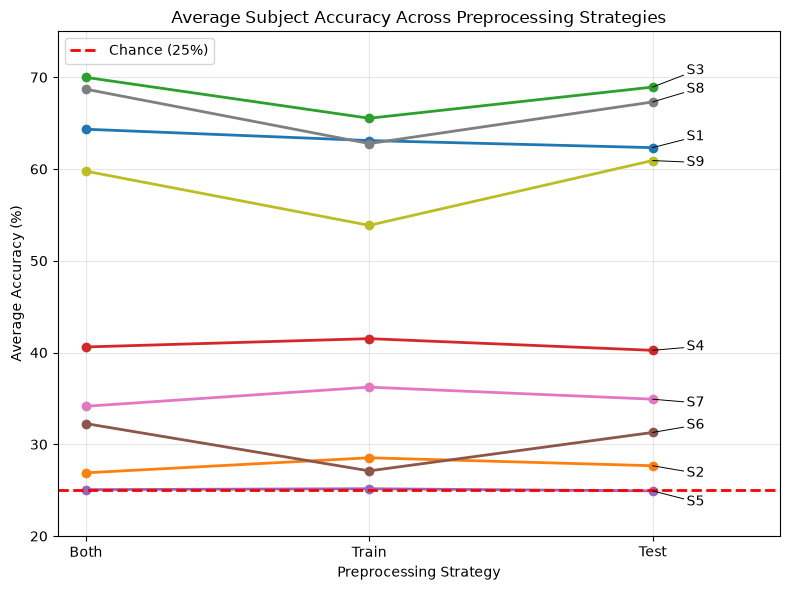

In [46]:
import numpy as np
import matplotlib.pyplot as plt

conditions = ["both", "train", "test"]
labels = ["Both", "Train", "Test"]

plt.figure(figsize=(8,6))

# Small offsets to separate labels
offsets = {
    1: 1.2,
    2: -0.8,
    3: 1.8,
    4: 0.4,
    5: -1.2,
    6: 0.8,
    7: -0.4,
    8: 1.4,
    9: -0.2
}

for subject in range(1,10):

    means = []

    for condition in conditions:

        accs = [
            RESULTS[condition][bw]["subjects"][subject]["acc"]
            for bw in [4,6,8]
        ]

        means.append(np.mean(accs)*100)

    plt.plot(
        range(3),
        means,
        marker='o',
        linewidth=2
    )

    # Label at final point
    plt.annotate(
        f"S{subject}",
        xy=(2, means[-1]),
        xytext=(2.12, means[-1] + offsets[subject]),
        fontsize=10,
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            lw=0.7,
            shrinkA=0,
            shrinkB=0
        )
    )

# Chance level
plt.axhline(
    25,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Chance (25%)'
)

plt.xticks(range(3), labels)
plt.xlim(-0.1, 2.45)
plt.ylim(20,75)

plt.xlabel("Preprocessing Strategy")
plt.ylabel("Average Accuracy (%)")
plt.title("Average Subject Accuracy Across Preprocessing Strategies")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# New model

   subject  CSP+LDA  EEGNet  EEGNet+CSP
0        1   0.3715  0.6389      0.5920
1        2   0.2760  0.3212      0.3316
2        3   0.5035  0.7326      0.6545
3        4   0.3924  0.3733      0.4427
4        5   0.2726  0.2500      0.2500
5        6   0.2309  0.3542      0.2951
6        7   0.3576  0.3594      0.3715
7        8   0.5399  0.6875      0.6962
8        9   0.5226  0.6372      0.5625


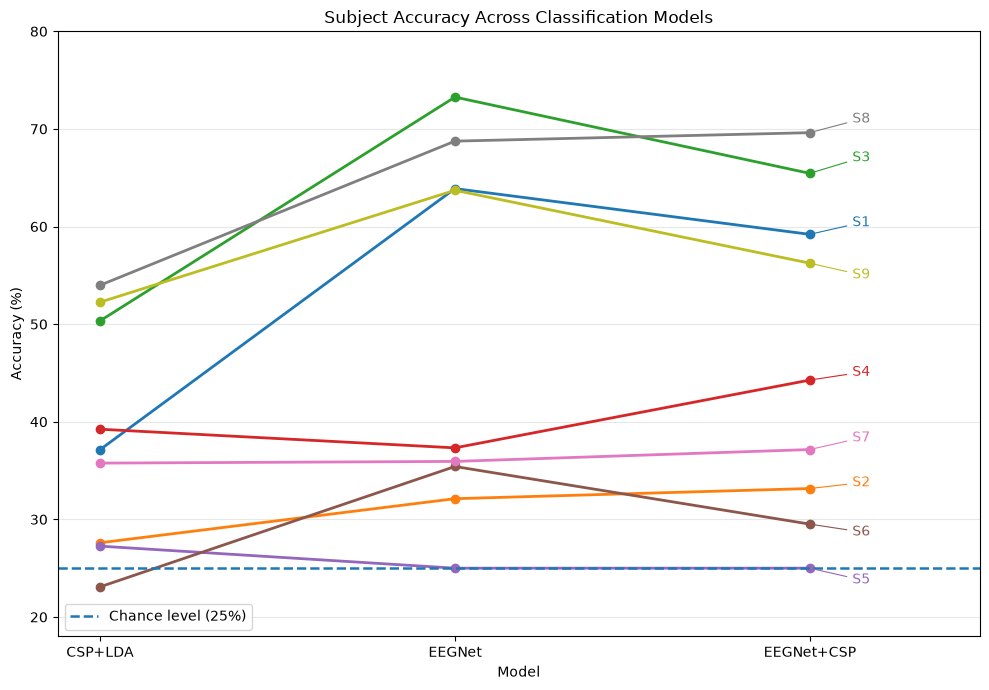

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CSP + LDA results
#    Average the 0train and 1test session accuracies per subject
# ============================================================

csp_rows = [
    [1, "0train", 0.423611],
    [1, "1test",  0.319444],
    [2, "0train", 0.277778],
    [2, "1test",  0.274306],
    [3, "0train", 0.413194],
    [3, "1test",  0.593750],
    [4, "0train", 0.381944],
    [4, "1test",  0.402778],
    [5, "0train", 0.277778],
    [5, "1test",  0.267361],
    [6, "0train", 0.246528],
    [6, "1test",  0.215278],
    [7, "0train", 0.329861],
    [7, "1test",  0.385417],
    [8, "0train", 0.541667],
    [8, "1test",  0.538194],
    [9, "0train", 0.440972],
    [9, "1test",  0.604167],
]

csp_df = pd.DataFrame(
    csp_rows,
    columns=["subject", "session", "accuracy"]
)

csp_accuracy = (
    csp_df
    .groupby("subject")["accuracy"]
    .mean()
    .to_dict()
)


# ============================================================
# 2. EEGNet results
# ============================================================

eegnet_accuracy = {
    1: 0.6388888888888888,
    2: 0.3211805555555556,
    3: 0.7326388888888888,
    4: 0.3732638888888889,
    5: 0.2500000000000000,
    6: 0.3541666666666667,
    7: 0.3593750000000000,
    8: 0.6875000000000000,
    9: 0.6371527777777778,
}


# ============================================================
# 3. EEGNet + CSP results
# ============================================================

eegnet_csp_accuracy = {
    1: 0.5920138888888888,
    2: 0.3315972222222222,
    3: 0.6545138888888888,
    4: 0.4427083333333333,
    5: 0.2500000000000000,
    6: 0.2951388888888889,
    7: 0.3715277777777778,
    8: 0.6961805555555556,
    9: 0.5625000000000000,
}


# ============================================================
# 4. Build table
# ============================================================

subjects = list(range(1, 10))
model_names = ["CSP+LDA", "EEGNet", "EEGNet+CSP"]
x = np.arange(len(model_names))

accuracy_table = pd.DataFrame({
    "subject": subjects,
    "CSP+LDA": [csp_accuracy[s] for s in subjects],
    "EEGNet": [eegnet_accuracy[s] for s in subjects],
    "EEGNet+CSP": [eegnet_csp_accuracy[s] for s in subjects],
})

print(accuracy_table.round(4))


# ============================================================
# 5. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Vertical offsets for direct labels
label_offsets = {
    1: 0.012,
    2: 0.006,
    3: 0.016,
    4: 0.008,
    5: -0.012,
    6: -0.008,
    7: 0.012,
    8: 0.014,
    9: -0.012,
}

for subject in subjects:

    values = np.array([
        csp_accuracy[subject],
        eegnet_accuracy[subject],
        eegnet_csp_accuracy[subject],
    ]) * 100

    line, = ax.plot(
        x,
        values,
        marker="o",
        linewidth=2,
        markersize=6,
    )

    # Direct label beside the EEGNet+CSP point
    ax.annotate(
        f"S{subject}",
        xy=(x[-1], values[-1]),
        xytext=(
            x[-1] + 0.12,
            values[-1] + label_offsets[subject] * 100
        ),
        va="center",
        fontsize=10,
        color=line.get_color(),
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.8,
            color=line.get_color(),
        ),
    )


# Chance line
ax.axhline(
    25,
    linestyle="--",
    linewidth=1.8,
    label="Chance level (25%)",
)

ax.set_xticks(x)
ax.set_xticklabels(model_names)

ax.set_xlim(-0.12, 2.48)
ax.set_ylim(18, 80)

ax.set_xlabel("Model")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Subject Accuracy Across Classification Models")

ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower left")

fig.tight_layout()
plt.show()